In [249]:
from pathlib import Path
import logging
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
INTERIM_DATA_DIR = DATA_DIR / "interim"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_RAW_DIR = FIGURES_DIR / "raw"
FIGURES_CLEANED_DIR = FIGURES_DIR / "cleaned"
TABLES_RAW_DIR = TABLES_DIR / "raw"
TABLES_CLEANED_DIR = TABLES_DIR / "cleaned"
MAPS_DIR = OUTPUT_DIR / "maps"

for directory in (
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_RAW_DIR,
    FIGURES_CLEANED_DIR,
    TABLES_RAW_DIR,
    TABLES_CLEANED_DIR,
    MAPS_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

logger = logging.getLogger(__name__)

logger.info("Project initialized.")

2026-08-14 19:03:07,717 | INFO | Project initialized.


In [250]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

HOUSING_PALETTE_CATEGORICAL = [
    "#1F3B4D", "#C1633B", "#4C8577", "#D9A441", "#7A6C8F", "#8C8C8C",
]
HOUSING_PALETTE_SEQUENTIAL = sns.light_palette("#C1633B", as_cmap=True)
HOUSING_PALETTE_DIVERGING = sns.diverging_palette(160, 20, s=60, l=45, as_cmap=True)

CITY_COLOR_MAP = {
    "tehran": "#1F3B4D",
    "mashhad": "#C1633B",
    "isfahan": "#4C8577",
    "karaj": "#D9A441",
} 

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": "#FAF7F2",
        "axes.facecolor": "#FAF7F2",
        "axes.edgecolor": "#8C8C8C",
        "axes.grid.axis": "y",
        "grid.color": "#E5DED3",
        "grid.linewidth": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "Vazirmatn",  
    }
)


def fa(text: str) -> str:
    """Reshape and reorder Persian/Arabic text for correct rendering in matplotlib."""
    return get_display(arabic_reshaper.reshape(text))


from matplotlib import font_manager
font_manager.fontManager.addfont("Vazirmatn-Regular.ttf")
mpl.rcParams["font.family"] = "Vazirmatn"


In [251]:
CLEANED_DATA_PATH = (
    PROCESSED_DATA_DIR / "divar_real_estate_cleaned.csv"
)

df = pd.read_csv(CLEANED_DATA_PATH)

logger.info(
    "Loaded cleaned dataset: %d rows × %d columns",
    df.shape[0],
    df.shape[1],
)

C:\Users\asus\AppData\Local\Temp\ipykernel_17516\3262102099.py:5: DtypeWarning: Columns (23,25,26,37,171,186) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLEANED_DATA_PATH)
2026-08-14 19:04:03,235 | INFO | Loaded cleaned dataset: 724990 rows × 281 columns


In [252]:
display(df.head())

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,is_rebuilt_clean_final,has_water_clean_final,has_gas_clean_final,has_electricity_clean_final,has_sauna_clean_final,has_jacuzzi_clean_final,has_pool_clean_final,has_barbecue_clean_final,has_security_guard_clean_final,has_business_deed_clean_final
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,500متر 200متر بنا دوبلکس 3خواب استخر آبگرم داخ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN
1,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان 3 خوابه 132 متر,مقطوع,26000000.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,residential-rent,apartment-rent,ahvaz,mellirah,2024-09-01 00:00:00,NaN,اپارتمان 100متری واحد جلو دارای دو اتاق خواب ک...,اپارتمان 100متری ملی راه واحد جلو,مقطوع,6000000.0,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,commercial-rent,office-rent,kermanshah,NaN,2024-11-01 00:00:00,NaN,♦مشاورین املاک سیب♦ ✅️کد:G105 ♦با سالها سابقه ...,واحداداری 80متری 22بهمن(برق),مقطوع,16000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡ ♡♡♡عرض ادب واحترام♡♡♡ ♡♡♡...,اپارتمان 100متری طبقه3و4 فول دردشت شمالی,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [253]:
logger.info(
    "Memory usage: %.2f MB",
    df.memory_usage(deep=True).sum() / (1024 ** 2),
)

2026-08-14 19:04:31,810 | INFO | Memory usage: 5237.39 MB


In [254]:
transform_cols = [
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
]

display(
    df[transform_cols]
    .describe()
)

,transformable_credit,transformed_credit,transformable_rent,transformed_rent
count,2.634800e+05,5.670400e+04,2.630580e+05,5.670400e+04
mean,1.027946e+10,8.864038e+08,1.453671e+10,1.598542e+07
std,1.634792e+12,2.846496e+09,2.050269e+12,5.302350e+07
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+08,2.000000e+08,3.000000e+05,1.000000e+06
50%,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06
75%,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07
max,5.000000e+14,3.500000e+11,8.888889e+14,3.000000e+09


In [255]:
mask = (
    df["transformable_credit"].notna()
    & df["transformed_rent"].notna()
    & (df["transformable_credit"] > 0)
    & (df["transformed_rent"] > 0)
)

implied_k = (
    df.loc[mask, "transformed_rent"]
    / (df.loc[mask, "transformable_credit"] / 1_000_000)
)

display(
    implied_k.describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
)

count    4.623400e+04
mean     4.220778e+04
std      1.273487e+06
min      2.857143e-04
1%       2.000000e+00
5%       4.545455e+02
10%      3.750000e+03
25%      8.571429e+03
50%      1.818182e+04
75%      4.250000e+04
90%      8.000000e+04
95%      1.100000e+05
99%      2.000000e+05
max      2.650000e+08
dtype: float64

In [256]:
mask = (
    df["transformable_credit"].notna()
    & df["transformed_rent"].notna()
    & (df["transformable_credit"] > 0)
    & (df["transformed_rent"] > 0)
)

implied_k = (
    df.loc[mask, "transformed_rent"]
    / (df.loc[mask, "transformable_credit"] / 1_000_000)
)

k_rounded = implied_k.round(-2)

display(
    k_rounded.value_counts().head(20)
)

10000.0     1863
20000.0     1718
15000.0     1484
30000.0     1276
0.0         1070
40000.0     1006
50000.0      958
5000.0       904
60000.0      899
7500.0       775
6000.0       723
25000.0      674
12000.0      654
13300.0      616
6700.0       543
8600.0       531
16700.0      526
100000.0     511
70000.0      509
80000.0      504
Name: count, dtype: int64

In [257]:
for k in [20000, 25000, 30000, 35000, 40000]:
    tolerance = 0.05

    close = implied_k[
        implied_k.between(
            k * (1 - tolerance),
            k * (1 + tolerance)
        )
    ]

    logger.info(
        "k=%s: %d rows (%.2f%%)",
        k,
        len(close),
        100 * len(close) / len(implied_k)
    )

2026-08-14 19:04:32,121 | INFO | k=20000: 2247 rows (4.86%)
2026-08-14 19:04:32,123 | INFO | k=25000: 1513 rows (3.27%)
2026-08-14 19:04:32,126 | INFO | k=30000: 1570 rows (3.40%)
2026-08-14 19:04:32,128 | INFO | k=35000: 1293 rows (2.80%)
2026-08-14 19:04:32,130 | INFO | k=40000: 1405 rows (3.04%)


In [258]:
reasonable_k = implied_k[
    implied_k.between(5_000, 100_000)
]

display(
    reasonable_k.describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
)

count     37773.000000
mean      28869.316415
std       23450.343226
min        5000.000000
5%         6000.000000
10%        7500.000000
25%       11250.000000
50%       20000.000000
75%       40000.000000
90%       66666.666667
95%       80000.000000
max      100000.000000
dtype: float64

In [259]:
from dataclasses import dataclass

@dataclass(frozen=True)
class RentConversionScenario:
    name: str
    monthly_rent_per_million_deposit: float


RENT_CONVERSION_SCENARIOS = [
    RentConversionScenario("low", 20_000),
    RentConversionScenario("base", 30_000),
    RentConversionScenario("high", 40_000),
]


RENT_REGIMES = [
    "deposit_and_rent",
    "full_deposit",
    "rent_no_deposit",
]


rent_mask = (
    df["price_regime"].isin(RENT_REGIMES)
    & (
        df["deposit_amount"].notna()
        | df["monthly_rent"].notna()
    )
)


for scenario in RENT_CONVERSION_SCENARIOS:
    k = scenario.monthly_rent_per_million_deposit

    rent_col = f"equivalent_monthly_rent_{scenario.name}"
    deposit_col = f"equivalent_deposit_{scenario.name}"

    df[rent_col] = np.nan
    df[deposit_col] = np.nan

    # Equivalent monthly rent
    df.loc[rent_mask, rent_col] = (
        df.loc[rent_mask, "monthly_rent"].fillna(0)
        + (
            df.loc[rent_mask, "deposit_amount"].fillna(0)
            / 1_000_000
        ) * k
    )

    # Equivalent deposit
    deposit_mask = (
        rent_mask
        & df["monthly_rent"].notna()
        & (df["monthly_rent"] > 0)
    )

    df.loc[deposit_mask, deposit_col] = (
        df.loc[deposit_mask, "deposit_amount"].fillna(0)
        + (
            df.loc[deposit_mask, "monthly_rent"] / k
        ) * 1_000_000
    )

In [260]:
conversion_cols = [
    "equivalent_monthly_rent_low",
    "equivalent_monthly_rent_base",
    "equivalent_monthly_rent_high",
    "equivalent_deposit_low",
    "equivalent_deposit_base",
    "equivalent_deposit_high",
]

display(
    df[conversion_cols].describe().T
)

,count,mean,std,min,25%,50%,75%,max
equivalent_monthly_rent_low,263503.0,1.471773e+10,2.059045e+12,20000.0,7000000.0,1.200000e+07,2.300000e+07,8.948889e+14
equivalent_monthly_rent_base,263503.0,1.482051e+10,2.064472e+12,30000.0,8500000.0,1.500000e+07,2.900000e+07,8.978889e+14
equivalent_monthly_rent_high,263503.0,1.492330e+10,2.070015e+12,40000.0,10000000.0,1.800000e+07,3.400000e+07,9.008889e+14
equivalent_deposit_low,218131.0,8.862352e+11,1.131484e+14,3750000.0,350000000.0,6.000000e+08,1.200000e+09,4.474444e+16
equivalent_deposit_base,218131.0,5.940563e+11,7.562690e+13,2500000.0,278055555.5,4.833333e+08,9.333333e+08,2.992963e+16
equivalent_deposit_high,218131.0,4.479668e+11,5.686807e+13,1875000.0,240000000.0,4.225000e+08,8.000000e+08,2.252222e+16


In [261]:
display(
    df.loc[
        rent_mask,
        ["price_regime", "deposit_amount", "monthly_rent"] + conversion_cols
    ].sample(10, random_state=42)
)

,price_regime,deposit_amount,monthly_rent,equivalent_monthly_rent_low,equivalent_monthly_rent_base,equivalent_monthly_rent_high,equivalent_deposit_low,equivalent_deposit_base,equivalent_deposit_high
73542,deposit_and_rent,1.000000e+09,8000000.0,28000000.0,38000000.0,48000000.0,1.400000e+09,1.266667e+09,1.200000e+09
571699,deposit_and_rent,2.000000e+08,8000000.0,12000000.0,14000000.0,16000000.0,6.000000e+08,4.666667e+08,4.000000e+08
246671,deposit_and_rent,8.000000e+08,80000000.0,96000000.0,104000000.0,112000000.0,4.800000e+09,3.466667e+09,2.800000e+09
311319,full_deposit,8.000000e+08,NaN,16000000.0,24000000.0,32000000.0,NaN,NaN,NaN
268774,full_deposit,6.000000e+08,NaN,12000000.0,18000000.0,24000000.0,NaN,NaN,NaN
600653,deposit_and_rent,1.000000e+08,10000000.0,12000000.0,13000000.0,14000000.0,6.000000e+08,4.333333e+08,3.500000e+08
172177,deposit_and_rent,6.000000e+08,15000000.0,27000000.0,33000000.0,39000000.0,1.350000e+09,1.100000e+09,9.750000e+08
36469,deposit_and_rent,3.500000e+08,20000000.0,27000000.0,30500000.0,34000000.0,1.350000e+09,1.016667e+09,8.500000e+08
720176,deposit_and_rent,2.000000e+08,13000000.0,17000000.0,19000000.0,21000000.0,8.500000e+08,6.333333e+08,5.250000e+08
313258,deposit_and_rent,4.000000e+08,60000000.0,68000000.0,72000000.0,76000000.0,3.400000e+09,2.400000e+09,1.900000e+09


In [262]:
df.loc[
    df["equivalent_monthly_rent_base"] > 500_000_000,
    [
        "price_regime",
        "deposit_amount",
        "monthly_rent",
        "equivalent_monthly_rent_base",
        "title",
        "description"
    ]
].head(20)

,price_regime,deposit_amount,monthly_rent,equivalent_monthly_rent_base,title,description
115,full_deposit,2.000000e+10,NaN,6.000000e+08,1300 متر ویلا الهیه پل رومی,1300 متر زمین ویلا لوکس در یک کوچه اختصاصی 450...
467,deposit_and_rent,2.500000e+10,1.000000e+06,7.510000e+08,پنت هاوس 430متر با 4 پارکینگ .کلید نخورده,عرض ادب و احترام نیاززاده شیرکوه 11طبقه تکواحد...
823,full_deposit,5.000000e+10,NaN,1.500000e+09,ولنجک 1100 متر ویلا بازسازی شده,ولنجک تاپ لوکیشن 1100 متر زمین 1000 متر بنا اس...
1087,deposit_and_rent,5.000000e+09,5.000000e+08,6.500000e+08,چناران/ 500 متر/ پنت هاوس,تاپ لوکیشن فرشته سازنده به نام ارشیتکت فرزاد د...
1796,full_deposit,2.000000e+10,NaN,6.000000e+08,710 متر سند اداری عباس آباد /فلت هوشمند/نوساز,710 متر سند اداری نوساز عباس آباد 8 پارکینگ سن...
1886,full_deposit,5.000000e+10,NaN,1.500000e+09,فلامک* ویلایی نوساز*900متر اعیانی*سفارت,❇️بنام خدا ◽️خیال پردازی کنید،بازدید کنید،مقای...
2053,deposit_and_rent,1.000000e+10,4.500000e+08,7.500000e+08,375متر/کلاسیک/کلیدنخورده/دید و ویو,زعفرانیه رهن کامل یا رهن و اجاره تاپ ترین لوکش...
2538,rent_no_deposit,NaN,9.000000e+08,9.000000e+08,14 متر مجتمع تجاری دودلفین,مجتمع تجاری دودلفین 14 متر مغازه لاین عمده فرو...
3340,deposit_and_rent,4.000000e+09,8.000000e+08,9.200000e+08,550 متر روف 360 درجه اختصاصی شریعتی-پل صدر,« بسمه تعالی » ✓ روف گاردن با موقعیت استثنایی ...
3452,deposit_and_rent,5.000000e+09,1.300000e+09,1.450000e+09,فرشته 1000 متر تجاری بر اصلی,1000 متر پارکینک مراجعین بر اصلی خیابان حفاظت ...


In [263]:
df[
    [
        "equivalent_monthly_rent_low",
        "equivalent_monthly_rent_base",
        "equivalent_monthly_rent_high",
    ]
].quantile(
    [0.90,0.95,0.99,0.995,0.999]
)

,equivalent_monthly_rent_low,equivalent_monthly_rent_base,equivalent_monthly_rent_high
0.900,4.800000e+07,5.850000e+07,6.800000e+07
0.950,8.000000e+07,9.600000e+07,1.120000e+08
0.990,2.700000e+08,3.100000e+08,3.600000e+08
0.995,4.600000e+08,5.300000e+08,6.000000e+08
0.999,7.002498e+09,7.502699e+09,8.004996e+09


In [264]:
base_col = "equivalent_monthly_rent_base"

sensitivity_effect_summary = []

for scenario in RENT_CONVERSION_SCENARIOS:
    scenario_col = f"equivalent_monthly_rent_{scenario.name}"

    valid_mask = (
        df[base_col].notna()
        & df[scenario_col].notna()
        & (df[base_col] > 0)
    )

    relative_change = (
        (
            df.loc[valid_mask, scenario_col]
            - df.loc[valid_mask, base_col]
        )
        / df.loc[valid_mask, base_col]
    )

    sensitivity_effect_summary.append({
        "scenario": scenario.name,
        "k": scenario.monthly_rent_per_million_deposit,
        "n": valid_mask.sum(),
        "median_relative_change": relative_change.median(),
        "mean_relative_change": relative_change.mean(),
        "q25_relative_change": relative_change.quantile(0.25),
        "q75_relative_change": relative_change.quantile(0.75),
    })

sensitivity_effect_summary = pd.DataFrame(
    sensitivity_effect_summary
)

display(sensitivity_effect_summary)

,scenario,k,n,median_relative_change,mean_relative_change,q25_relative_change,q75_relative_change
0,low,20000,263503,-0.157895,-0.181181,-0.322476,-0.080000
1,base,30000,263503,0.000000,0.000000,0.000000,0.000000
2,high,40000,263503,0.157895,0.181181,0.080000,0.322476


In [265]:
LAND_BASED_PROPERTY_TYPES = [
    "plot-old",
    "house-villa-sell",
    "industry-agriculture-business-sell",
]

price_normalization_documentation = {
    "sale": {
        "metric": "sale_price_per_sqm",

        "formula": (
            "sale_price / sale_price_basis_size"
        ),

        "land_based_property_types": LAND_BASED_PROPERTY_TYPES,

        "basis_rule": (
            "For land-based property types, land_size_final is used "
            "as the denominator when valid. For other property types, "
            "building_size_final is used."
        ),

        "land_based_column": "land_size_final",

        "building_based_column": "building_size_final",

        "currency_unit": "Toman",

        "interpretation": (
            "Price per square meter is interpreted according to the "
            "property type. For land-based properties, the metric is "
            "based on land area; for other properties, it is based "
            "on building area."
        ),
    },

    "rent": {
        "metric": "equivalent_monthly_rent",

        "formula": (
            "monthly_rent + "
            "(deposit_amount / 1,000,000) * k"
        ),

        "base_k": 30000,

        "scenarios": {
            "low": 20000,
            "base": 30000,
            "high": 40000,
        },

        "unit": (
            "monthly rent in Toman; k represents monthly rent "
            "equivalent per 1,000,000 Toman of deposit."
        ),

        "regimes": RENT_REGIMES,

        "sensitivity_analysis": (
            "Low, base, and high conversion scenarios are retained "
            "to assess the sensitivity of rental-market comparisons "
            "to the deposit-to-rent conversion coefficient."
        ),

        "outlier_treatment": (
            "High equivalent rental values are not automatically "
            "capped or removed. Manual inspection indicates that "
            "very high values may correspond to legitimate luxury "
            "properties, including large villas and penthouses "
            "in high-value areas."
        ),
    },
}

logger.info(
    "Price normalization documentation:\n%s",
    price_normalization_documentation
)

2026-08-14 19:04:33,183 | INFO | Price normalization documentation:
{'sale': {'metric': 'sale_price_per_sqm', 'formula': 'sale_price / sale_price_basis_size', 'land_based_property_types': ['plot-old', 'house-villa-sell', 'industry-agriculture-business-sell'], 'basis_rule': 'For land-based property types, land_size_final is used as the denominator when valid. For other property types, building_size_final is used.', 'land_based_column': 'land_size_final', 'building_based_column': 'building_size_final', 'currency_unit': 'Toman', 'interpretation': 'Price per square meter is interpreted according to the property type. For land-based properties, the metric is based on land area; for other properties, it is based on building area.'}, 'rent': {'metric': 'equivalent_monthly_rent', 'formula': 'monthly_rent + (deposit_amount / 1,000,000) * k', 'base_k': 30000, 'scenarios': {'low': 20000, 'base': 30000, 'high': 40000}, 'unit': 'monthly rent in Toman; k represents monthly rent equivalent per 1,000,

In [266]:
PRICE_METRICS = {
 
    "sale": {
        "metric_type": "per_sqm",
        "column": "sale_price_per_sqm",
        "label": "Sale price per sqm",
        "value_column": "sale_price",
        "basis_column": "sale_price_basis_size",
    },


    "deposit_and_rent": {
        "metric_type": "monthly_equivalent_rent",
        "column": "equivalent_monthly_rent_base",
        "label": "Equivalent monthly rent",
        "value_columns": [
            "deposit_amount",
            "monthly_rent",
        ],
    },


    "full_deposit": {
        "metric_type": "monthly_equivalent_rent",
        "column": "equivalent_monthly_rent_base",
        "label": "Equivalent monthly rent",
        "value_columns": [
            "deposit_amount",
        ],
    },


    "rent_no_deposit": {
        "metric_type": "monthly_rent",
        "column": "monthly_rent",
        "label": "Monthly rent",
        "value_columns": [
            "monthly_rent",
        ],
    },


    "daily_rent": {
        "metric_type": "daily_rent",
        "columns": {
            "regular": "daily_rent_regular",
            "special": "daily_rent_special",
            "weekend": "daily_rent_weekend",
        },
        "labels": {
            "regular": "Daily rent - regular days",
            "special": "Daily rent - special days",
            "weekend": "Daily rent - weekends",
        },
    },
}

display(pd.DataFrame([
    {
        "regime": regime,
        "metric_type": config["metric_type"],
        "metric_column": (
            config.get("column")
            or ", ".join(config.get("columns", {}).values())
        ),
        "label": (
            config.get("label")
            or ", ".join(config.get("labels", {}).values())
        ),
    }
    for regime, config in PRICE_METRICS.items()
]))

,regime,metric_type,metric_column,label
0,sale,per_sqm,sale_price_per_sqm,Sale price per sqm
1,deposit_and_rent,monthly_equivalent_rent,equivalent_monthly_rent_base,Equivalent monthly rent
2,full_deposit,monthly_equivalent_rent,equivalent_monthly_rent_base,Equivalent monthly rent
3,rent_no_deposit,monthly_rent,monthly_rent,Monthly rent
4,daily_rent,daily_rent,"daily_rent_regular, daily_rent_special, daily_...","Daily rent - regular days, Daily rent - specia..."


In [267]:
required_price_columns = {
    "sale_price_per_sqm",
    "sale_price_basis_size",
    "sale_price",
    "deposit_amount",
    "monthly_rent",
    "equivalent_monthly_rent_base",
    "daily_rent_regular",
    "daily_rent_special",
    "daily_rent_weekend",
    "price_regime",
}

missing_required = sorted(
    required_price_columns - set(df.columns)
)

if missing_required:
    raise KeyError(
        f"Required price-analysis columns are missing from df: "
        f"{missing_required}"
    )

logger.info(
    "All required price-analysis columns are available."
)

2026-08-14 19:04:33,206 | INFO | All required price-analysis columns are available.


In [268]:
metric_eligibility = pd.DataFrame(index=df.index)

metric_eligibility["sale"] = (
    (df["price_regime"] == "sale")
    & df["sale_price_per_sqm"].notna()
    & np.isfinite(df["sale_price_per_sqm"])
    & (df["sale_price_per_sqm"] >= 0)
)

metric_eligibility["deposit_and_rent"] = (
    (df["price_regime"] == "deposit_and_rent")
    & df["equivalent_monthly_rent_base"].notna()
    & np.isfinite(df["equivalent_monthly_rent_base"])
    & (df["equivalent_monthly_rent_base"] > 0)
)

metric_eligibility["full_deposit"] = (
    (df["price_regime"] == "full_deposit")
    & df["equivalent_monthly_rent_base"].notna()
    & np.isfinite(df["equivalent_monthly_rent_base"])
    & (df["equivalent_monthly_rent_base"] > 0)
)

metric_eligibility["rent_no_deposit"] = (
    (df["price_regime"] == "rent_no_deposit")
    & df["monthly_rent"].notna()
    & np.isfinite(df["monthly_rent"])
    & (df["monthly_rent"] > 0)
)

daily_base = (
    (df["price_regime"] == "daily_rent")
)

metric_eligibility["daily_rent_regular"] = (
    daily_base
    & df["daily_rent_regular"].notna()
    & np.isfinite(df["daily_rent_regular"])
    & (df["daily_rent_regular"] >= 0)
)

metric_eligibility["daily_rent_special"] = (
    daily_base
    & df["daily_rent_special"].notna()
    & np.isfinite(df["daily_rent_special"])
    & (df["daily_rent_special"] >= 0)
)

metric_eligibility["daily_rent_weekend"] = (
    daily_base
    & df["daily_rent_weekend"].notna()
    & np.isfinite(df["daily_rent_weekend"])
    & (df["daily_rent_weekend"] >= 0)
)

eligibility_summary = pd.DataFrame({
    "metric": metric_eligibility.columns,
    "eligible_n": metric_eligibility.sum().values,
})

eligibility_summary["eligible_rate"] = (
    eligibility_summary["eligible_n"] / len(df)
)

display(eligibility_summary)

,metric,eligible_n,eligible_rate
0,sale,404671,0.558175
1,deposit_and_rent,213012,0.293814
2,full_deposit,45372,0.062583
3,rent_no_deposit,5119,0.007061
4,daily_rent_regular,11174,0.015413
5,daily_rent_special,6353,0.008763
6,daily_rent_weekend,8517,0.011748


In [269]:
quality_rows = []

regime_metric_map = {
    "sale": "sale",
    "deposit_and_rent": "deposit_and_rent",
    "full_deposit": "full_deposit",
    "rent_no_deposit": "rent_no_deposit",
    "daily_rent": "daily_rent",
}

for regime, metric_name in regime_metric_map.items():

    regime_mask = df["price_regime"] == regime

    if metric_name == "daily_rent":
        metric_names = [
            "daily_rent_regular",
            "daily_rent_special",
            "daily_rent_weekend",
        ]
    else:
        metric_names = [metric_name]

    for metric in metric_names:

        eligible = metric_eligibility[metric]

        regime_n = regime_mask.sum()
        eligible_n = (regime_mask & eligible).sum()

        unavailable_n = regime_n - eligible_n

        quality_rows.append({
            "regime": regime,
            "metric": metric,
            "regime_n": regime_n,
            "eligible_n": eligible_n,
            "unavailable_n": unavailable_n,
            "eligible_rate": (
                eligible_n / regime_n
                if regime_n > 0
                else np.nan
            ),
            "unavailable_rate": (
                unavailable_n / regime_n
                if regime_n > 0
                else np.nan
            ),
        })

price_quality_summary = pd.DataFrame(quality_rows)

display(price_quality_summary)

,regime,metric,regime_n,eligible_n,unavailable_n,eligible_rate,unavailable_rate
0,sale,sale,404697,404671,26,0.999936,0.000064
1,deposit_and_rent,deposit_and_rent,213012,213012,0,1.000000,0.000000
2,full_deposit,full_deposit,45372,45372,0,1.000000,0.000000
3,rent_no_deposit,rent_no_deposit,5119,5119,0,1.000000,0.000000
4,daily_rent,daily_rent_regular,11268,11174,94,0.991658,0.008342
5,daily_rent,daily_rent_special,11268,6353,4915,0.563809,0.436191
6,daily_rent,daily_rent_weekend,11268,8517,2751,0.755857,0.244143


In [270]:
METRIC_COLUMN_MAP = {
    "sale": "sale_price_per_sqm",
    "deposit_and_rent": "equivalent_monthly_rent_base",
    "full_deposit": "equivalent_monthly_rent_base",
    "rent_no_deposit": "monthly_rent",
    "daily_rent_regular": "daily_rent_regular",
    "daily_rent_special": "daily_rent_special",
    "daily_rent_weekend": "daily_rent_weekend",
}


metric_descriptive_rows = []

for metric_flag, value_col in METRIC_COLUMN_MAP.items():

    values = df.loc[
        metric_eligibility[metric_flag],
        value_col
    ].dropna()

    if len(values) == 0:
        continue

    metric_descriptive_rows.append({
        "metric": metric_flag,
        "column": value_col,
        "n": len(values),
        "mean": values.mean(),
        "std": values.std(),
        "min": values.min(),
        "p01": values.quantile(0.01),
        "p05": values.quantile(0.05),
        "p10": values.quantile(0.10),
        "q25": values.quantile(0.25),
        "median": values.median(),
        "q75": values.quantile(0.75),
        "p90": values.quantile(0.90),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "max": values.max(),
        "iqr": values.quantile(0.75) - values.quantile(0.25),
    })


price_metric_distribution_before = pd.DataFrame(
    metric_descriptive_rows
)

display(price_metric_distribution_before)

,metric,column,n,mean,std,min,p01,p05,p10,q25,median,q75,p90,p95,p99,max,iqr
0,sale,sale_price_per_sqm,404671,1.127016e+08,3.242180e+09,0.2125,100000.0,1100000.0,3000000.0,1.142857e+07,2.705882e+07,50000000.0,100000000.0,1.446485e+08,3.333333e+08,8.333333e+11,3.857143e+07
1,deposit_and_rent,equivalent_monthly_rent_base,213012,1.709524e+10,2.264146e+12,265000.0000,2600000.0,4400000.0,5500000.0,8.500000e+06,1.470000e+07,28000000.0,57000000.0,9.500000e+07,3.100000e+08,8.978889e+14,1.950000e+07
2,full_deposit,equivalent_monthly_rent_base,45372,3.920226e+08,7.044791e+10,30000.0000,2100000.0,4500000.0,6000000.0,1.020000e+07,1.650000e+07,33000000.0,60000000.0,1.048350e+08,3.000000e+08,1.500000e+13,2.280000e+07
3,rent_no_deposit,monthly_rent,5119,4.805072e+10,2.454976e+12,75000.0000,100000.0,100000.0,100000.0,1.000000e+06,2.000000e+06,5000000.0,25000000.0,1.000000e+08,5.682000e+08,1.444146e+14,4.000000e+06
4,daily_rent_regular,daily_rent_regular,11174,1.176025e+11,7.150767e+12,50000.0000,150000.0,300000.0,399000.0,5.500000e+05,1.000000e+06,2000000.0,3000000.0,3.500000e+06,1.000000e+07,5.006007e+14,1.450000e+06
5,daily_rent_special,daily_rent_special,6353,1.862776e+09,1.030518e+11,50000.0000,150000.0,350000.0,500000.0,8.000000e+05,1.500000e+06,3000000.0,4500000.0,6.000000e+06,1.348000e+07,5.806808e+12,2.200000e+06
6,daily_rent_weekend,daily_rent_weekend,8517,1.818238e+08,8.901118e+09,50000.0000,150000.0,350000.0,500000.0,7.500000e+05,1.500000e+06,3000000.0,4000000.0,5.000000e+06,1.000000e+07,4.805807e+11,2.250000e+06


In [271]:
OUTLIER_FLAGS = {

    # Sale
    "sale": [
        "sale_price_per_sqm_outlier_flag",
    ],


    # Deposit + Rent
    "deposit_and_rent": [
        "deposit_amount_outlier_flag",
        "monthly_rent_outlier_flag",
        "deposit_amount_per_sqm_outlier_flag",
        "monthly_rent_per_sqm_outlier_flag",
    ],


    # Full Deposit
    "full_deposit": [
        "deposit_amount_outlier_flag",
        "deposit_amount_per_sqm_outlier_flag",
    ],


    # Rent only
    "rent_no_deposit": [
        "monthly_rent_outlier_flag",
        "monthly_rent_per_sqm_outlier_flag",
    ],


    # Daily rent
    "daily_rent_regular": [
        "daily_rent_regular_outlier_flag",
    ],

    "daily_rent_special": [
        "daily_rent_special_outlier_flag",
    ],

    "daily_rent_weekend": [
        "daily_rent_weekend_outlier_flag",
    ],
}


# بررسی وجود flag ها

missing_flags = []

for metric, flags in OUTLIER_FLAGS.items():
    for flag in flags:
        if flag not in df.columns:
            missing_flags.append(flag)


if missing_flags:
    logger.warning(
        "Missing outlier flags:\n%s",
        missing_flags
    )
else:
    logger.info(
        "All outlier flags are available."
    )

2026-08-14 19:04:34,326 | INFO | All outlier flags are available.


In [272]:
def apply_outlier_policy(
    frame: pd.DataFrame,
    eligible_mask: pd.Series,
    outlier_flags: list[str],
):
    """
    Apply outlier removal only on eligible records.

    Returns:
        clean_mask_after_outlier,
        outlier_mask
    """

    metric_outlier = pd.Series(
        False,
        index=frame.index
    )

    for flag in outlier_flags:
        if flag in frame.columns:
            metric_outlier |= frame[flag].fillna(False)


    final_mask = (
        eligible_mask
        & ~metric_outlier
    )

    return final_mask, metric_outlier

In [273]:
METRIC_COLUMN_MAP = {

    "sale":
        "sale_price_per_sqm",

    "deposit_and_rent":
        "equivalent_monthly_rent_base",

    "full_deposit":
        "equivalent_monthly_rent_base",

    "rent_no_deposit":
        "monthly_rent",

    "daily_rent_regular":
        "daily_rent_regular",

    "daily_rent_special":
        "daily_rent_special",

    "daily_rent_weekend":
        "daily_rent_weekend",
}

In [274]:
outlier_sensitivity_rows = []


for metric, value_col in METRIC_COLUMN_MAP.items():

    # eligibility اولیه
    eligible_mask = metric_eligibility[metric]


    # بدون حذف outlier
    values_before = (
        df.loc[
            eligible_mask,
            value_col
        ]
        .dropna()
    )


    # بعد از حذف outlier
    clean_mask, outlier_mask = apply_outlier_policy(
        df,
        eligible_mask,
        OUTLIER_FLAGS[metric],
    )


    values_after = (
        df.loc[
            clean_mask,
            value_col
        ]
        .dropna()
    )


    for policy, values in [
        ("without_outlier_removal", values_before),
        ("remove_outliers", values_after),
    ]:

        outlier_sensitivity_rows.append({

            "metric": metric,

            "column": value_col,

            "policy": policy,

            "n": len(values),

            "mean": values.mean(),

            "median": values.median(),

            "q05": values.quantile(.05),

            "q25": values.quantile(.25),

            "q75": values.quantile(.75),

            "q95": values.quantile(.95),

            "q99": values.quantile(.99),

            "iqr": (
                values.quantile(.75)
                -
                values.quantile(.25)
            )
        })


outlier_sensitivity_summary = pd.DataFrame(
    outlier_sensitivity_rows
)


display(
    outlier_sensitivity_summary
)

,metric,column,policy,n,mean,median,q05,q25,q75,q95,q99,iqr
0,sale,sale_price_per_sqm,without_outlier_removal,404671,1.127016e+08,2.705882e+07,1100000.0,1.142857e+07,50000000.0,1.446485e+08,3.333333e+08,3.857143e+07
1,sale,sale_price_per_sqm,remove_outliers,398847,4.368429e+07,2.721519e+07,1400000.0,1.184211e+07,50000000.0,1.400000e+08,2.966093e+08,3.815789e+07
2,deposit_and_rent,equivalent_monthly_rent_base,without_outlier_removal,213012,1.709524e+10,1.470000e+07,4400000.0,8.500000e+06,28000000.0,9.500000e+07,3.100000e+08,1.950000e+07
3,deposit_and_rent,equivalent_monthly_rent_base,remove_outliers,209401,1.148792e+10,1.500000e+07,4500000.0,8.600000e+06,28000000.0,9.100000e+07,3.000000e+08,1.940000e+07
4,full_deposit,equivalent_monthly_rent_base,without_outlier_removal,45372,3.920226e+08,1.650000e+07,4500000.0,1.020000e+07,33000000.0,1.048350e+08,3.000000e+08,2.280000e+07
5,full_deposit,equivalent_monthly_rent_base,remove_outliers,44472,3.250064e+07,1.650000e+07,4800000.0,1.050000e+07,31500000.0,9.600000e+07,2.700000e+08,2.100000e+07
6,rent_no_deposit,monthly_rent,without_outlier_removal,5119,4.805072e+10,2.000000e+06,100000.0,1.000000e+06,5000000.0,1.000000e+08,5.682000e+08,4.000000e+06
7,rent_no_deposit,monthly_rent,remove_outliers,5067,2.003611e+10,2.000000e+06,100000.0,1.000000e+06,5000000.0,9.000000e+07,4.760400e+08,4.000000e+06
8,daily_rent_regular,daily_rent_regular,without_outlier_removal,11174,1.176025e+11,1.000000e+06,300000.0,5.500000e+05,2000000.0,3.500000e+06,1.000000e+07,1.450000e+06
9,daily_rent_regular,daily_rent_regular,remove_outliers,11079,1.815411e+06,1.000000e+06,300000.0,5.500000e+05,2000000.0,3.500000e+06,7.000000e+06,1.450000e+06


In [275]:
outlier_removal_rows = []


for metric, flags in OUTLIER_FLAGS.items():

    eligible = metric_eligibility[metric]


    outlier_mask = pd.Series(
        False,
        index=df.index
    )


    for flag in flags:
        if flag in df.columns:
            outlier_mask |= df[flag].fillna(False)


    eligible_outliers = (
        eligible
        &
        outlier_mask
    )


    eligible_n = eligible.sum()

    removed_n = eligible_outliers.sum()


    outlier_removal_rows.append({

        "metric": metric,

        "eligible_n": eligible_n,

        "outlier_removed_n": removed_n,

        "removal_rate": (
            removed_n / eligible_n
            if eligible_n > 0
            else np.nan
        )
    })


outlier_removal_summary = pd.DataFrame(
    outlier_removal_rows
)


display(
    outlier_removal_summary
)

,metric,eligible_n,outlier_removed_n,removal_rate
0,sale,404671,5824,0.014392
1,deposit_and_rent,213012,3611,0.016952
2,full_deposit,45372,900,0.019836
3,rent_no_deposit,5119,52,0.010158
4,daily_rent_regular,11174,95,0.008502
5,daily_rent_special,6353,52,0.008185
6,daily_rent_weekend,8517,88,0.010332


In [276]:
RANKING_METRICS = {
    "sale": "sale_price_per_sqm",
    "deposit_and_rent": "equivalent_monthly_rent_base",
    "full_deposit": "equivalent_monthly_rent_base",
    "rent_no_deposit": "monthly_rent",
}

In [277]:
MIN_SAMPLE_THRESHOLDS = [10, 30, 50, 100, 200, 300,1000, 3000]

def build_sample_size_sensitivity(
    frame: pd.DataFrame,
    metric: str,
    value_col: str,
    group_cols: list[str],
    thresholds: list[int],
) -> pd.DataFrame:

    data = frame.loc[
        frame["price_regime"].eq(metric),
        group_cols + [value_col]
    ].copy()

    data = data.dropna(subset=[value_col])

    grouped = (
        data
        .groupby(group_cols)[value_col]
        .agg(
            sample_size="count",
            median="median",
            mean="mean",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
        )
        .reset_index()
    )

    grouped["iqr"] = grouped["q75"] - grouped["q25"]

    rows = []

    for threshold in thresholds:

        eligible = grouped[
            grouped["sample_size"] >= threshold
        ].copy()

        if len(eligible) == 0:
            continue

        eligible = eligible.sort_values(
            "median",
            ascending=False
        )

        eligible["rank"] = range(1, len(eligible) + 1)

        eligible["min_sample_threshold"] = threshold

        rows.append(eligible)

    if not rows:
        return pd.DataFrame()

    return pd.concat(
        rows,
        ignore_index=True
    )

In [278]:
GROUP_COLS = [
    "city_slug",
    "neighborhood_slug",
]

sample_size_sensitivity = {}

for metric, value_col in RANKING_METRICS.items():

    result = build_sample_size_sensitivity(
        frame=df,
        metric=metric,
        value_col=value_col,
        group_cols=GROUP_COLS,
        thresholds=MIN_SAMPLE_THRESHOLDS,
    )

    sample_size_sensitivity[metric] = result

    for metric, result in sample_size_sensitivity.items():

        print(f"\n{'='*70}")
        print(f"METRIC: {metric}")
        print(f"{'='*70}")

        for threshold in MIN_SAMPLE_THRESHOLDS:

            subset = result[
                result["min_sample_threshold"] == threshold
            ].sort_values("median", ascending=False)

            print(f"\n--- Minimum sample size = {threshold} ---")

            display(
                subset.head(20)
            )




METRIC: sale

--- Minimum sample size = 10 ---


,city_slug,neighborhood_slug,sample_size,median,mean,q25,q75,iqr,rank,min_sample_threshold
0,tehran,bazaar,127,6.956522e+08,1.409580e+09,2.578046e+08,1.450000e+09,1.192195e+09,1,10
2,tehran,mahmoodiyeh,107,2.500000e+08,2.671917e+08,1.915535e+08,3.215385e+08,1.299849e+08,3,10
1,tehran,velenjak,451,2.500000e+08,2.583835e+08,2.000000e+08,3.000000e+08,1.000000e+08,2,10
3,tehran,zafaraniyeh,650,2.450680e+08,1.046072e+09,1.997368e+08,3.000000e+08,1.002632e+08,4,10
4,tehran,elahiyeh,557,2.416667e+08,2.635067e+08,2.000000e+08,3.200000e+08,1.200000e+08,5,10
5,tehran,kamraniyeh,134,2.347508e+08,2.496245e+08,1.928878e+08,2.873512e+08,9.446337e+07,6,10
6,tehran,aghdasieh,234,2.315341e+08,2.169180e+09,1.762605e+08,3.045614e+08,1.283009e+08,7,10
7,tehran,farmaniyeh,532,2.195600e+08,1.028930e+09,1.800000e+08,2.967666e+08,1.167666e+08,8,10
8,tehran,bagh-ferdows,23,2.095238e+08,2.333324e+08,1.555556e+08,3.113313e+08,1.557758e+08,9,10
9,tehran,emamzade-ghasem,66,2.083263e+08,2.580663e+08,1.698270e+08,3.212687e+08,1.514417e+08,10,10



--- Minimum sample size = 30 ---


,city_slug,neighborhood_slug,sample_size,median,mean,q25,q75,iqr,rank,min_sample_threshold
1012,tehran,bazaar,127,6.956522e+08,1.409580e+09,2.578046e+08,1.450000e+09,1.192195e+09,1,30
1014,tehran,velenjak,451,2.500000e+08,2.583835e+08,2.000000e+08,3.000000e+08,1.000000e+08,3,30
1013,tehran,mahmoodiyeh,107,2.500000e+08,2.671917e+08,1.915535e+08,3.215385e+08,1.299849e+08,2,30
1015,tehran,zafaraniyeh,650,2.450680e+08,1.046072e+09,1.997368e+08,3.000000e+08,1.002632e+08,4,30
1016,tehran,elahiyeh,557,2.416667e+08,2.635067e+08,2.000000e+08,3.200000e+08,1.200000e+08,5,30
1017,tehran,kamraniyeh,134,2.347508e+08,2.496245e+08,1.928878e+08,2.873512e+08,9.446337e+07,6,30
1018,tehran,aghdasieh,234,2.315341e+08,2.169180e+09,1.762605e+08,3.045614e+08,1.283009e+08,7,30
1019,tehran,farmaniyeh,532,2.195600e+08,1.028930e+09,1.800000e+08,2.967666e+08,1.167666e+08,8,30
1020,tehran,emamzade-ghasem,66,2.083263e+08,2.580663e+08,1.698270e+08,3.212687e+08,1.514417e+08,9,30
1021,tehran,niavaran,718,2.053852e+08,2.356483e+08,1.700000e+08,2.759781e+08,1.059781e+08,10,30



--- Minimum sample size = 50 ---


...

,city_slug,neighborhood_slug,sample_size,median,mean,q25,q75,iqr,rank,min_sample_threshold



--- Minimum sample size = 1000 ---


,city_slug,neighborhood_slug,sample_size,median,mean,q25,q75,iqr,rank,min_sample_threshold



--- Minimum sample size = 3000 ---


,city_slug,neighborhood_slug,sample_size,median,mean,q25,q75,iqr,rank,min_sample_threshold


In [279]:
sample_size_summary_rows = []

for metric, result in sample_size_sensitivity.items():

    if result.empty:
        continue

    for threshold in MIN_SAMPLE_THRESHOLDS:

        subset = result[
            result["min_sample_threshold"] == threshold
        ]

        sample_size_summary_rows.append({
            "metric": metric,
            "min_sample": threshold,
            "n_city_neighborhood_groups": len(subset),
            "median_group_sample_size": subset["sample_size"].median(),
            "min_group_sample_size": subset["sample_size"].min(),
            "max_group_sample_size": subset["sample_size"].max(),
        })


sample_size_sensitivity_summary = pd.DataFrame(
    sample_size_summary_rows
)

display(
    sample_size_sensitivity_summary
)

,metric,min_sample,n_city_neighborhood_groups,median_group_sample_size,min_group_sample_size,max_group_sample_size
0,sale,10,1012,79.0,10.0,3350.0
1,sale,30,805,106.0,30.0,3350.0
2,sale,50,654,135.0,50.0,3350.0
3,sale,100,418,221.0,100.0,3350.0
4,sale,200,236,368.5,200.0,3350.0
5,sale,300,153,489.0,302.0,3350.0
6,sale,1000,21,1309.0,1001.0,3350.0
7,sale,3000,1,3350.0,3350.0,3350.0
8,deposit_and_rent,10,951,56.0,10.0,1550.0
9,deposit_and_rent,30,692,79.0,30.0,1550.0


In [280]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np


TOP_N_VALUES = [10, 20, 50]

top_n_overlap_rows = []


for metric, result in sample_size_sensitivity.items():

    if result.empty:
        continue

    available_thresholds = sorted(
        result["min_sample_threshold"].unique()
    )

    for i, threshold_a in enumerate(available_thresholds):

        for threshold_b in available_thresholds[i + 1:]:

       

            rank_table = result.pivot_table(
                index=GROUP_COLS,
                columns="min_sample_threshold",
                values="rank",
                aggfunc="first",
            )

            comparison = rank_table[
                [threshold_a, threshold_b]
            ].dropna()

            n_common_groups = len(comparison)

            if n_common_groups >= 2:

                spearman_rho, _ = spearmanr(
                    comparison[threshold_a],
                    comparison[threshold_b],
                )

            else:

                spearman_rho = np.nan


            row = {
                "metric": metric,
                "threshold_a": threshold_a,
                "threshold_b": threshold_b,
                "n_common_groups": n_common_groups,
                "spearman_rank_correlation": spearman_rho,
            }


            for top_n in TOP_N_VALUES:

             

                result_a = result[
                    result["min_sample_threshold"] == threshold_a
                ].sort_values(
                    "rank"
                )

                top_a = set(
                    map(
                        tuple,
                        result_a[
                            GROUP_COLS
                        ].head(top_n).to_numpy()
                    )
                )



                result_b = result[
                    result["min_sample_threshold"] == threshold_b
                ].sort_values(
                    "rank"
                )

                top_b = set(
                    map(
                        tuple,
                        result_b[
                            GROUP_COLS
                        ].head(top_n).to_numpy()
                    )
                )



                intersection = top_a & top_b

                overlap_n = len(intersection)



                overlap_pct_a = (
                    overlap_n / len(top_a) * 100
                    if len(top_a) > 0
                    else np.nan
                )



                overlap_pct_b = (
                    overlap_n / len(top_b) * 100
                    if len(top_b) > 0
                    else np.nan
                )



                union = top_a | top_b

                jaccard_pct = (
                    overlap_n / len(union) * 100
                    if len(union) > 0
                    else np.nan
                )


                row[f"top_{top_n}_a_n"] = len(top_a)
                row[f"top_{top_n}_b_n"] = len(top_b)

                row[f"top_{top_n}_overlap_n"] = overlap_n

                row[f"top_{top_n}_overlap_pct_a"] = (
                    overlap_pct_a
                )

                row[f"top_{top_n}_overlap_pct_b"] = (
                    overlap_pct_b
                )

                row[f"top_{top_n}_jaccard_pct"] = (
                    jaccard_pct
                )


            top_n_overlap_rows.append(row)




top_n_overlap_summary = pd.DataFrame(
    top_n_overlap_rows
)


display(
    top_n_overlap_summary.head(20)
)

,metric,threshold_a,threshold_b,n_common_groups,spearman_rank_correlation,top_10_a_n,top_10_b_n,top_10_overlap_n,top_10_overlap_pct_a,top_10_overlap_pct_b,...,top_20_overlap_n,top_20_overlap_pct_a,top_20_overlap_pct_b,top_20_jaccard_pct,top_50_a_n,top_50_b_n,top_50_overlap_n,top_50_overlap_pct_a,top_50_overlap_pct_b,top_50_jaccard_pct
0,sale,10,30,805,0.999991,10,10,9,90.0,90.0,...,19,95.0,95.0,90.476190,50,50,46,92.0,92.000000,85.185185
1,sale,10,50,654,0.999988,10,10,9,90.0,90.0,...,17,85.0,85.0,73.913043,50,50,43,86.0,86.000000,75.438596
2,sale,10,100,418,0.999990,10,10,8,80.0,80.0,...,13,65.0,65.0,48.148148,50,50,32,64.0,64.000000,47.058824
3,sale,10,200,236,0.999983,10,10,5,50.0,50.0,...,8,40.0,40.0,25.000000,50,50,23,46.0,46.000000,29.870130
4,sale,10,300,153,0.999983,10,10,4,40.0,40.0,...,7,35.0,35.0,21.212121,50,50,18,36.0,36.000000,21.951220
5,sale,10,1000,21,1.000000,10,10,0,0.0,0.0,...,0,0.0,0.0,0.000000,50,21,1,2.0,4.761905,1.428571
6,sale,10,3000,1,NaN,10,1,0,0.0,0.0,...,0,0.0,0.0,0.000000,50,1,0,0.0,0.000000,0.000000
7,sale,30,50,654,0.999988,10,10,10,100.0,100.0,...,18,90.0,90.0,81.818182,50,50,46,92.0,92.000000,85.185185
8,sale,30,100,418,0.999980,10,10,9,90.0,90.0,...,14,70.0,70.0,53.846154,50,50,34,68.0,68.000000,51.515152
9,sale,30,200,236,0.999990,10,10,6,60.0,60.0,...,9,45.0,45.0,29.032258,50,50,24,48.0,48.000000,31.578947


In [281]:
from scipy.stats import spearmanr


ranking_stability_rows = []


for metric, result in sample_size_sensitivity.items():

    if result.empty:
        continue

    pivot = result.pivot_table(
        index=GROUP_COLS,
        columns="min_sample_threshold",
        values="rank",
        aggfunc="first",
    )

    for i, threshold_a in enumerate(MIN_SAMPLE_THRESHOLDS):

        for threshold_b in MIN_SAMPLE_THRESHOLDS[i + 1:]:

            if (
                threshold_a not in pivot.columns
                or threshold_b not in pivot.columns
            ):
                continue

            comparison = pivot[
                [threshold_a, threshold_b]
            ].dropna()

            if len(comparison) < 2:
                rho = np.nan
                n_common = len(comparison)
            else:
                rho, _ = spearmanr(
                    comparison[threshold_a],
                    comparison[threshold_b]
                )
                n_common = len(comparison)

            ranking_stability_rows.append({
                "metric": metric,
                "threshold_a": threshold_a,
                "threshold_b": threshold_b,
                "n_common_groups": n_common,
                "spearman_rank_correlation": rho,
            })


ranking_stability = pd.DataFrame(
    ranking_stability_rows
)

display(
    ranking_stability.sort_values(
        ["metric", "threshold_a", "threshold_b"]
    )
)

,metric,threshold_a,threshold_b,n_common_groups,spearman_rank_correlation
28,deposit_and_rent,10,30,692,0.999833
29,deposit_and_rent,10,50,519,0.999853
30,deposit_and_rent,10,100,282,0.999839
31,deposit_and_rent,10,200,133,0.999796
32,deposit_and_rent,10,300,83,0.999748
...,...,...,...,...,...
23,sale,200,1000,21,1.000000
24,sale,200,3000,1,NaN
25,sale,300,1000,21,1.000000
26,sale,300,3000,1,NaN


In [282]:
IMPORTANT_THRESHOLD_PAIRS = [
    (10, 50),
    (10, 100),
    (10, 300),
    (10, 1000),
    (100, 300),
    (100, 1000),
    (300, 1000),
    (1000, 3000),
]

important_overlap = top_n_overlap_summary[
    top_n_overlap_summary.apply(
        lambda row: (
            row["threshold_a"],
            row["threshold_b"],
        ) in IMPORTANT_THRESHOLD_PAIRS,
        axis=1,
    )
].copy()

display(
    important_overlap.sort_values(
        ["metric", "threshold_a", "threshold_b"]
    )
)

,metric,threshold_a,threshold_b,n_common_groups,spearman_rank_correlation,top_10_a_n,top_10_b_n,top_10_overlap_n,top_10_overlap_pct_a,top_10_overlap_pct_b,...,top_20_overlap_n,top_20_overlap_pct_a,top_20_overlap_pct_b,top_20_jaccard_pct,top_50_a_n,top_50_b_n,top_50_overlap_n,top_50_overlap_pct_a,top_50_overlap_pct_b,top_50_jaccard_pct
29,deposit_and_rent,10,50,519,0.999853,10,10,10,100.0,100.0,...,17,85.0,85.000000,73.913043,50,50,43,86.000000,86.000000,75.438596
30,deposit_and_rent,10,100,282,0.999839,10,10,8,80.0,80.0,...,12,60.0,60.000000,42.857143,50,50,31,62.000000,62.000000,44.927536
32,deposit_and_rent,10,300,83,0.999748,10,10,5,50.0,50.0,...,8,40.0,40.000000,25.000000,50,50,17,34.000000,34.000000,20.481928
33,deposit_and_rent,10,1000,6,1.000000,10,6,0,0.0,0.0,...,0,0.0,0.000000,0.000000,50,6,1,2.000000,16.666667,1.818182
44,deposit_and_rent,100,300,83,0.999853,10,10,7,70.0,70.0,...,12,60.0,60.000000,42.857143,50,50,24,48.000000,48.000000,31.578947
45,deposit_and_rent,100,1000,6,1.000000,10,6,0,0.0,0.0,...,1,5.0,16.666667,4.000000,50,6,1,2.000000,16.666667,1.818182
48,deposit_and_rent,300,1000,6,1.000000,10,6,0,0.0,0.0,...,1,5.0,16.666667,4.000000,50,6,3,6.000000,50.000000,5.660377
50,full_deposit,10,50,136,0.999232,10,10,7,70.0,70.0,...,12,60.0,60.000000,42.857143,50,50,25,50.000000,50.000000,33.333333
51,full_deposit,10,100,54,0.998933,10,10,5,50.0,50.0,...,9,45.0,45.000000,29.032258,50,50,15,30.000000,30.000000,17.647059
53,full_deposit,10,300,4,1.000000,10,4,0,0.0,0.0,...,1,5.0,25.000000,4.347826,50,4,1,2.000000,25.000000,1.886792


In [283]:


MIN_SAMPLE_DECISION_ROWS = []

for metric, result in sample_size_sensitivity.items():

    if result.empty:
        continue

    for threshold in MIN_SAMPLE_THRESHOLDS:

        subset = result[
            result["min_sample_threshold"] == threshold
        ].copy()

        if subset.empty:
            continue

        MIN_SAMPLE_DECISION_ROWS.append({
            "metric": metric,
            "min_sample": threshold,

            # Number of city-neighborhood groups that survive
            "n_groups": len(subset),

            # Distribution of sample sizes among surviving groups
            "median_group_n": subset["sample_size"].median(),
            "min_group_n": subset["sample_size"].min(),
            "max_group_n": subset["sample_size"].max(),

            # Distribution of group-level prices
            "median_group_price": subset["median"].median(),
            "q25_group_price": subset["median"].quantile(0.25),
            "q75_group_price": subset["median"].quantile(0.75),
        })


minimum_sample_decision_summary = pd.DataFrame(
    MIN_SAMPLE_DECISION_ROWS
)

display(
    minimum_sample_decision_summary
)

,metric,min_sample,n_groups,median_group_n,min_group_n,max_group_n,median_group_price,q25_group_price,q75_group_price
0,sale,10,1012,79.0,10,3350,4.393661e+07,2.703079e+07,6.429383e+07
1,sale,30,805,106.0,30,3350,4.545455e+07,2.850000e+07,6.800000e+07
2,sale,50,654,135.0,50,3350,4.703684e+07,2.943062e+07,7.039752e+07
3,sale,100,418,221.0,100,3350,5.000000e+07,2.994403e+07,7.829251e+07
4,sale,200,236,368.5,200,3350,5.000000e+07,2.979697e+07,7.920186e+07
5,sale,300,153,489.0,302,3350,5.000000e+07,3.078947e+07,9.500000e+07
6,sale,1000,21,1309.0,1001,3350,4.821339e+07,3.102041e+07,9.500000e+07
7,sale,3000,1,3350.0,3350,3350,3.152174e+07,3.152174e+07,3.152174e+07
8,deposit_and_rent,10,951,56.0,10,1550,1.650000e+07,1.200000e+07,2.500000e+07
9,deposit_and_rent,30,692,79.0,30,1550,1.782500e+07,1.300000e+07,2.812500e+07


In [284]:


BASELINE_MIN_SAMPLE = 50

baseline_comparison_rows = []

for metric, result in sample_size_sensitivity.items():

    if result.empty:
        continue

    rank_table = result.pivot_table(
        index=GROUP_COLS,
        columns="min_sample_threshold",
        values="rank",
        aggfunc="first",
    )

    if BASELINE_MIN_SAMPLE not in rank_table.columns:
        continue

    for threshold in MIN_SAMPLE_THRESHOLDS:

        if threshold == BASELINE_MIN_SAMPLE:
            continue

        if threshold not in rank_table.columns:
            continue

        comparison = rank_table[
            [BASELINE_MIN_SAMPLE, threshold]
        ].dropna()

        n_common = len(comparison)

        if n_common >= 2:
            rho, _ = spearmanr(
                comparison[BASELINE_MIN_SAMPLE],
                comparison[threshold],
            )
        else:
            rho = np.nan

        row = {
            "metric": metric,
            "baseline_threshold": BASELINE_MIN_SAMPLE,
            "comparison_threshold": threshold,
            "n_common_groups": n_common,
            "spearman_rank_correlation": rho,
        }

        for top_n in [10, 20, 50]:

            baseline_top = set(
                comparison.index[
                    comparison[BASELINE_MIN_SAMPLE] <= top_n
                ]
            )

            comparison_top = set(
                comparison.index[
                    comparison[threshold] <= top_n
                ]
            )

            intersection = baseline_top & comparison_top
            union = baseline_top | comparison_top

            row[f"top_{top_n}_baseline_n"] = len(baseline_top)
            row[f"top_{top_n}_comparison_n"] = len(comparison_top)
            row[f"top_{top_n}_overlap_n"] = len(intersection)

            row[f"top_{top_n}_overlap_pct_baseline"] = (
                len(intersection) / len(baseline_top) * 100
                if len(baseline_top) > 0
                else np.nan
            )

            row[f"top_{top_n}_jaccard_pct"] = (
                len(intersection) / len(union) * 100
                if len(union) > 0
                else np.nan
            )

        baseline_comparison_rows.append(row)


baseline_sample_sensitivity = pd.DataFrame(
    baseline_comparison_rows
)

display(baseline_sample_sensitivity)

,metric,baseline_threshold,comparison_threshold,n_common_groups,spearman_rank_correlation,top_10_baseline_n,top_10_comparison_n,top_10_overlap_n,top_10_overlap_pct_baseline,top_10_jaccard_pct,top_20_baseline_n,top_20_comparison_n,top_20_overlap_n,top_20_overlap_pct_baseline,top_20_jaccard_pct,top_50_baseline_n,top_50_comparison_n,top_50_overlap_n,top_50_overlap_pct_baseline,top_50_jaccard_pct
0,sale,50,10,654,0.999988,10,9,9,90.0,90.0,20,17,17,85.0,85.000000,50,43,43,86.0,86.000000
1,sale,50,30,654,0.999988,10,10,10,100.0,100.0,20,18,18,90.0,90.000000,50,46,46,92.0,92.000000
2,sale,50,100,418,0.999977,9,10,9,100.0,90.0,16,20,16,100.0,80.000000,36,50,36,100.0,72.000000
3,sale,50,200,236,0.999986,6,10,6,100.0,60.0,10,20,10,100.0,50.000000,24,50,24,100.0,48.000000
4,sale,50,300,153,0.999966,5,10,5,100.0,50.0,9,20,9,100.0,45.000000,19,50,19,100.0,38.000000
5,sale,50,1000,21,1.000000,0,10,0,NaN,0.0,1,20,1,100.0,5.000000,1,21,1,100.0,4.761905
6,sale,50,3000,1,NaN,0,1,0,NaN,0.0,0,1,0,NaN,0.000000,0,1,0,NaN,0.000000
7,deposit_and_rent,50,10,519,0.999853,10,10,10,100.0,100.0,20,17,17,85.0,85.000000,50,43,43,86.0,86.000000
8,deposit_and_rent,50,30,519,0.999858,10,10,10,100.0,100.0,20,20,20,100.0,100.000000,50,49,49,98.0,98.000000
9,deposit_and_rent,50,100,282,0.999845,8,10,8,100.0,80.0,15,20,15,100.0,75.000000,36,50,36,100.0,72.000000


In [285]:


decision_rows = []

for metric in baseline_sample_sensitivity["metric"].unique():

    subset = baseline_sample_sensitivity[
        baseline_sample_sensitivity["metric"] == metric
    ].copy()

    for _, row in subset.iterrows():

        decision_rows.append({
            "metric": metric,
            "comparison_threshold": row["comparison_threshold"],
            "n_common_groups": row["n_common_groups"],
            "spearman": row["spearman_rank_correlation"],
            "top10_overlap_pct": row["top_10_overlap_pct_baseline"],
            "top20_overlap_pct": row["top_20_overlap_pct_baseline"],
            "top50_overlap_pct": row["top_50_overlap_pct_baseline"],
            "top10_jaccard_pct": row["top_10_jaccard_pct"],
            "top20_jaccard_pct": row["top_20_jaccard_pct"],
            "top50_jaccard_pct": row["top_50_jaccard_pct"],
        })


minimum_sample_decision_compact = pd.DataFrame(
    decision_rows
)

display(
    minimum_sample_decision_compact
)


,metric,comparison_threshold,n_common_groups,spearman,top10_overlap_pct,top20_overlap_pct,top50_overlap_pct,top10_jaccard_pct,top20_jaccard_pct,top50_jaccard_pct
0,sale,10,654,0.999988,90.0,85.0,86.0,90.0,85.000000,86.000000
1,sale,30,654,0.999988,100.0,90.0,92.0,100.0,90.000000,92.000000
2,sale,100,418,0.999977,100.0,100.0,100.0,90.0,80.000000,72.000000
3,sale,200,236,0.999986,100.0,100.0,100.0,60.0,50.000000,48.000000
4,sale,300,153,0.999966,100.0,100.0,100.0,50.0,45.000000,38.000000
5,sale,1000,21,1.000000,NaN,100.0,100.0,0.0,5.000000,4.761905
6,sale,3000,1,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000
7,deposit_and_rent,10,519,0.999853,100.0,85.0,86.0,100.0,85.000000,86.000000
8,deposit_and_rent,30,519,0.999858,100.0,100.0,98.0,100.0,100.000000,98.000000
9,deposit_and_rent,100,282,0.999845,100.0,100.0,100.0,80.0,75.000000,72.000000


In [286]:
from dataclasses import dataclass


@dataclass(frozen=True)
class RentConversionScenario:
    name: str
    monthly_rent_per_million_deposit: float


RENT_CONVERSION_SCENARIOS = [
    RentConversionScenario("k_25", 25_000),
    RentConversionScenario("k_30", 30_000),
    RentConversionScenario("k_35", 35_000),
    RentConversionScenario("k_40", 40_000),
    RentConversionScenario("k_45", 45_000),
]

In [287]:
for scenario in RENT_CONVERSION_SCENARIOS:

    k = scenario.monthly_rent_per_million_deposit

    col = f"equivalent_monthly_rent_{scenario.name}"

    df[col] = np.nan

   
    mask_deposit_and_rent = (
        df["price_regime"].eq("deposit_and_rent")
        & df["deposit_amount"].notna()
        & df["monthly_rent"].notna()
    )

    df.loc[mask_deposit_and_rent, col] = (
        df.loc[mask_deposit_and_rent, "monthly_rent"]
        + (
            df.loc[mask_deposit_and_rent, "deposit_amount"]
            / 1_000_000
        ) * k
    )

   
    mask_full_deposit = (
        df["price_regime"].eq("full_deposit")
        & df["deposit_amount"].notna()
    )

    df.loc[mask_full_deposit, col] = (
        df.loc[mask_full_deposit, "deposit_amount"]
        / 1_000_000
    ) * k

In [288]:
sensitivity_summary_rows = []


for scenario in RENT_CONVERSION_SCENARIOS:

    col = f"equivalent_monthly_rent_{scenario.name}"

    for metric in ["deposit_and_rent", "full_deposit"]:

        values = df.loc[
            df["price_regime"].eq(metric),
            col
        ].dropna()

        if len(values) == 0:
            continue

        sensitivity_summary_rows.append({
            "metric": metric,
            "scenario": scenario.name,
            "k": scenario.monthly_rent_per_million_deposit,
            "n": len(values),
            "mean": values.mean(),
            "median": values.median(),
            "q05": values.quantile(0.05),
            "q25": values.quantile(0.25),
            "q75": values.quantile(0.75),
            "q95": values.quantile(0.95),
            "q99": values.quantile(0.99),
            "iqr": values.quantile(0.75) - values.quantile(0.25),
        })


rent_conversion_sensitivity_summary = pd.DataFrame(
    sensitivity_summary_rows
)

display(
    rent_conversion_sensitivity_summary
)

,metric,scenario,k,n,mean,median,q05,q25,q75,q95,q99,iqr
0,deposit_and_rent,k_25,25000,213012,1.704558e+10,13350000.0,4000000.0,7750000.0,26000000.0,8.760000e+07,300000000.0,18250000.0
1,full_deposit,k_25,25000,45372,3.266855e+08,13750000.0,3750000.0,8500000.0,27500000.0,8.736250e+07,250000000.0,19000000.0
2,deposit_and_rent,k_30,30000,213012,1.709524e+10,14700000.0,4400000.0,8500000.0,28000000.0,9.500000e+07,310000000.0,19500000.0
3,full_deposit,k_30,30000,45372,3.920226e+08,16500000.0,4500000.0,10200000.0,33000000.0,1.048350e+08,300000000.0,22800000.0
4,deposit_and_rent,k_35,35000,213012,1.714490e+10,15850000.0,4700000.0,9250000.0,30500000.0,1.005000e+08,325000000.0,21250000.0
5,full_deposit,k_35,35000,45372,4.573598e+08,19250000.0,5250000.0,11900000.0,38500000.0,1.223075e+08,350000000.0,26600000.0
6,deposit_and_rent,k_40,40000,213012,1.719455e+10,17000000.0,5000000.0,10000000.0,33000000.0,1.070000e+08,340000000.0,23000000.0
7,full_deposit,k_40,40000,45372,5.226969e+08,22000000.0,6000000.0,13600000.0,44000000.0,1.397800e+08,400000000.0,30400000.0
8,deposit_and_rent,k_45,45000,213012,1.724421e+10,18250000.0,5250000.0,10500000.0,34500000.0,1.126000e+08,355000000.0,24000000.0
9,full_deposit,k_45,45000,45372,5.880340e+08,24750000.0,6750000.0,15300000.0,49500000.0,1.572525e+08,450000000.0,34200000.0


In [289]:
K_RANKING_GROUPS = [
    "city_slug",
    "neighborhood_slug",
]


k_ranking_results = {}


for scenario in RENT_CONVERSION_SCENARIOS:

    col = f"equivalent_monthly_rent_{scenario.name}"

    scenario_results = {}

    for metric in ["deposit_and_rent", "full_deposit"]:

        data = df.loc[
            df["price_regime"].eq(metric),
            K_RANKING_GROUPS + [col]
        ].dropna(subset=[col]).copy()

        grouped = (
            data
            .groupby(K_RANKING_GROUPS)[col]
            .agg(
                sample_size="count",
                median="median",
                mean="mean",
                q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75),
            )
            .reset_index()
        )

        grouped["iqr"] = grouped["q75"] - grouped["q25"]

        grouped = grouped.sort_values(
            "median",
            ascending=False
        ).reset_index(drop=True)

        grouped["rank"] = np.arange(
            1,
            len(grouped) + 1
        )

        scenario_results[metric] = grouped

    k_ranking_results[scenario.name] = scenario_results

In [290]:
BASELINE_K = "k_30"

k_ranking_comparison_rows = []

baseline_results = k_ranking_results[BASELINE_K]


for scenario in RENT_CONVERSION_SCENARIOS:

    scenario_name = scenario.name

    if scenario_name == BASELINE_K:
        continue

    for metric in ["deposit_and_rent", "full_deposit"]:

        baseline = baseline_results[metric]
        comparison = k_ranking_results[scenario_name][metric]

        baseline_rank = baseline.set_index(K_RANKING_GROUPS)["rank"]
        comparison_rank = comparison.set_index(K_RANKING_GROUPS)["rank"]

        rank_table = pd.concat(
            [
                baseline_rank.rename("baseline_rank"),
                comparison_rank.rename("comparison_rank"),
            ],
            axis=1,
        ).dropna()

        n_common = len(rank_table)

        if n_common >= 2:
            rho, _ = spearmanr(
                rank_table["baseline_rank"],
                rank_table["comparison_rank"],
            )
        else:
            rho = np.nan

        row = {
            "metric": metric,
            "baseline_k": BASELINE_K,
            "comparison_k": scenario_name,
            "n_common_groups": n_common,
            "spearman_rank_correlation": rho,
        }

        for top_n in [10, 20, 50]:

            baseline_top = set(
                rank_table.index[
                    rank_table["baseline_rank"] <= top_n
                ]
            )

            comparison_top = set(
                rank_table.index[
                    rank_table["comparison_rank"] <= top_n
                ]
            )

            intersection = baseline_top & comparison_top
            union = baseline_top | comparison_top

            row[f"top_{top_n}_baseline_n"] = len(
                baseline_top
            )

            row[f"top_{top_n}_comparison_n"] = len(
                comparison_top
            )

            row[f"top_{top_n}_overlap_n"] = len(
                intersection
            )

            row[f"top_{top_n}_overlap_pct_baseline"] = (
                len(intersection)
                / len(baseline_top)
                * 100
                if baseline_top
                else np.nan
            )

            row[f"top_{top_n}_jaccard_pct"] = (
                len(intersection)
                / len(union)
                * 100
                if union
                else np.nan
            )

        k_ranking_comparison_rows.append(row)


k_ranking_sensitivity = pd.DataFrame(
    k_ranking_comparison_rows
)

display(k_ranking_sensitivity)

,metric,baseline_k,comparison_k,n_common_groups,spearman_rank_correlation,top_10_baseline_n,top_10_comparison_n,top_10_overlap_n,top_10_overlap_pct_baseline,top_10_jaccard_pct,top_20_baseline_n,top_20_comparison_n,top_20_overlap_n,top_20_overlap_pct_baseline,top_20_jaccard_pct,top_50_baseline_n,top_50_comparison_n,top_50_overlap_n,top_50_overlap_pct_baseline,top_50_jaccard_pct
0,deposit_and_rent,k_30,k_25,1101,0.997648,10,10,10,100.0,100.0,20,20,19,95.0,90.47619,50,50,48,96.0,92.307692
1,full_deposit,k_30,k_25,975,1.000000,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,50,100.0,100.000000
2,deposit_and_rent,k_30,k_35,1101,0.998303,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,49,98.0,96.078431
3,full_deposit,k_30,k_35,975,1.000000,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,50,100.0,100.000000
4,deposit_and_rent,k_30,k_40,1101,0.995214,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,48,96.0,92.307692
5,full_deposit,k_30,k_40,975,1.000000,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,50,100.0,100.000000
6,deposit_and_rent,k_30,k_45,1101,0.991624,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,48,96.0,92.307692
7,full_deposit,k_30,k_45,975,1.000000,10,10,10,100.0,100.0,20,20,20,100.0,100.00000,50,50,50,100.0,100.000000


In [291]:
k_sensitivity_compact = (
    k_ranking_sensitivity[
        [
            "metric",
            "baseline_k",
            "comparison_k",
            "n_common_groups",
            "spearman_rank_correlation",
            "top_10_overlap_pct_baseline",
            "top_20_overlap_pct_baseline",
            "top_50_overlap_pct_baseline",
            "top_10_jaccard_pct",
            "top_20_jaccard_pct",
            "top_50_jaccard_pct",
        ]
    ]
    .sort_values(
        ["metric", "comparison_k"]
    )
    .reset_index(drop=True)
)

display(k_sensitivity_compact)

,metric,baseline_k,comparison_k,n_common_groups,spearman_rank_correlation,top_10_overlap_pct_baseline,top_20_overlap_pct_baseline,top_50_overlap_pct_baseline,top_10_jaccard_pct,top_20_jaccard_pct,top_50_jaccard_pct
0,deposit_and_rent,k_30,k_25,1101,0.997648,100.0,95.0,96.0,100.0,90.47619,92.307692
1,deposit_and_rent,k_30,k_35,1101,0.998303,100.0,100.0,98.0,100.0,100.00000,96.078431
2,deposit_and_rent,k_30,k_40,1101,0.995214,100.0,100.0,96.0,100.0,100.00000,92.307692
3,deposit_and_rent,k_30,k_45,1101,0.991624,100.0,100.0,96.0,100.0,100.00000,92.307692
4,full_deposit,k_30,k_25,975,1.000000,100.0,100.0,100.0,100.0,100.00000,100.000000
5,full_deposit,k_30,k_35,975,1.000000,100.0,100.0,100.0,100.0,100.00000,100.000000
6,full_deposit,k_30,k_40,975,1.000000,100.0,100.0,100.0,100.0,100.00000,100.000000
7,full_deposit,k_30,k_45,975,1.000000,100.0,100.0,100.0,100.0,100.00000,100.000000


In [292]:
#20

In [293]:
MAIN_CITIES = [
    "tehran",
    "mashhad",
    "karaj",
    "isfahan",
]

MARKET_PROPERTY_TYPE = "apartment-sell"

df_market = df.loc[
    df["cat3_slug"].eq(MARKET_PROPERTY_TYPE)
    & df["city_slug"].isin(MAIN_CITIES)
].copy()

logger.info(
    "Market analysis subset: %d rows",
    len(df_market),
)

display(
    df_market["city_slug"]
    .value_counts(dropna=False)
    .rename("n_listings")
    .to_frame()
)

2026-08-14 19:04:56,057 | INFO | Market analysis subset: 103382 rows


,n_listings
city_slug,
tehran,62640
mashhad,18182
karaj,14810
isfahan,7750


In [294]:
MARKET_PRICE_COL = "sale_price_per_sqm"
MARKET_OUTLIER_FLAG = "sale_price_per_sqm_outlier_flag"

df_market["price_present"] = (
    df_market[MARKET_PRICE_COL].notna()
    & df_market[MARKET_PRICE_COL].gt(0)
)

df_market["price_outlier_flagged"] = (
    df_market[MARKET_OUTLIER_FLAG]
    .fillna(False)
)


df_market["price_valid_raw"] = df_market["price_present"]

In [295]:
market_city_outlier_summary = (
    df_market
    .groupby("city_slug")
    .agg(
        total_listings=("city_slug", "size"),
        price_present_n=("price_present", "sum"),
        outlier_flagged_n=("price_outlier_flagged", "sum"),
    )
    .reset_index()
)

market_city_outlier_summary["missing_price_n"] = (
    market_city_outlier_summary["total_listings"]
    - market_city_outlier_summary["price_present_n"]
)

market_city_outlier_summary["missing_price_rate"] = (
    market_city_outlier_summary["missing_price_n"]
    / market_city_outlier_summary["total_listings"]
)

market_city_outlier_summary["outlier_rate_among_price_present"] = (
    market_city_outlier_summary["outlier_flagged_n"]
    / market_city_outlier_summary["price_present_n"]
)

display(market_city_outlier_summary)

,city_slug,total_listings,price_present_n,outlier_flagged_n,missing_price_n,missing_price_rate,outlier_rate_among_price_present
0,isfahan,7750,7731,102,19,0.002452,0.013194
1,karaj,14810,14776,187,34,0.002296,0.012656
2,mashhad,18182,18153,269,29,0.001595,0.014818
3,tehran,62640,62639,769,1,0.000016,0.012277


In [296]:
market_neighborhood_outlier_summary = (
    df_market
    .groupby(["city_slug", "neighborhood_slug"])
    .agg(
        total_listings=("city_slug", "size"),
        price_present_n=("price_present", "sum"),
        outlier_flagged_n=("price_outlier_flagged", "sum"),
    )
    .reset_index()
)

market_neighborhood_outlier_summary["missing_price_n"] = (
    market_neighborhood_outlier_summary["total_listings"]
    - market_neighborhood_outlier_summary["price_present_n"]
)

market_neighborhood_outlier_summary["missing_price_rate"] = (
    market_neighborhood_outlier_summary["missing_price_n"]
    / market_neighborhood_outlier_summary["total_listings"]
)

market_neighborhood_outlier_summary["outlier_rate"] = (
    market_neighborhood_outlier_summary["outlier_flagged_n"]
    / market_neighborhood_outlier_summary["price_present_n"]
)

display(
    market_neighborhood_outlier_summary.sort_values(
        "outlier_rate",
        ascending=False
    ).head(30)
)

,city_slug,neighborhood_slug,total_listings,price_present_n,outlier_flagged_n,missing_price_n,missing_price_rate,outlier_rate
570,tehran,kuy-nobonyad,2,2,1,0,0.000000,0.500000
284,mashhad,arvand,4,4,1,0,0.000000,0.250000
99,isfahan,kuy-emam,13,13,2,0,0.000000,0.153846
156,isfahan,shahrak-mahdieh,7,7,1,0,0.000000,0.142857
4,isfahan,afaran,7,7,1,0,0.000000,0.142857
508,tehran,farahzad,7,7,1,0,0.000000,0.142857
429,tehran,aminhozour,8,8,1,0,0.000000,0.125000
132,isfahan,partman,8,8,1,0,0.000000,0.125000
534,tehran,hezarsang,8,8,1,0,0.000000,0.125000
695,tehran,shirazi,17,17,2,0,0.000000,0.117647


In [297]:


MARKET_PRICE_COL = "sale_price_per_sqm"


df_market["price_valid"] = (
    df_market[MARKET_PRICE_COL].notna()
    & df_market[MARKET_PRICE_COL].gt(0)
)


df_market["price_outlier_flagged"] = (
    df_market["sale_price_per_sqm_outlier_flag"]
    .fillna(False)
)

neighborhood_market_summary = (
    df_market
    .groupby(
        ["city_slug", "neighborhood_slug"],
        dropna=False
    )
    .agg(
        total_listing_count=("city_slug", "size"),

        valid_listing_count=("price_valid", "sum"),

        median_price_per_sqm=(
            MARKET_PRICE_COL,
            lambda x: x[df_market.loc[x.index, "price_valid"]].median()
        ),

        p25_price_per_sqm=(
            MARKET_PRICE_COL,
            lambda x: x[df_market.loc[x.index, "price_valid"]].quantile(0.25)
        ),

        p75_price_per_sqm=(
            MARKET_PRICE_COL,
            lambda x: x[df_market.loc[x.index, "price_valid"]].quantile(0.75)
        ),

        outlier_flagged_count=(
            "price_outlier_flagged",
            "sum"
        ),
    )
    .reset_index()
)



neighborhood_market_summary["missing_price_count"] = (
    neighborhood_market_summary["total_listing_count"]
    - neighborhood_market_summary["valid_listing_count"]
)

neighborhood_market_summary["missing_price_rate"] = (
    neighborhood_market_summary["missing_price_count"]
    / neighborhood_market_summary["total_listing_count"]
)

neighborhood_market_summary["outlier_rate"] = np.where(
    neighborhood_market_summary["valid_listing_count"] > 0,
    neighborhood_market_summary["outlier_flagged_count"]
    / neighborhood_market_summary["valid_listing_count"],
    np.nan,
)

neighborhood_market_summary["iqr_price_per_sqm"] = (
    neighborhood_market_summary["p75_price_per_sqm"]
    - neighborhood_market_summary["p25_price_per_sqm"]
)

display(
    neighborhood_market_summary.head(20)
)

,city_slug,neighborhood_slug,total_listing_count,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,outlier_flagged_count,missing_price_count,missing_price_rate,outlier_rate,iqr_price_per_sqm
0,isfahan,24-metri,104,104,3.230776e+07,2.676667e+07,3.610315e+07,1,0,0.000000,0.009615,9.336480e+06
1,isfahan,abbasabad,23,23,1.154839e+08,8.859848e+07,1.258630e+08,1,0,0.000000,0.043478,3.726456e+07
2,isfahan,abr,19,19,3.583486e+07,3.268608e+07,3.814655e+07,0,0,0.000000,0.000000,5.460468e+06
3,isfahan,abshar-isfahan,57,57,8.000000e+07,4.074074e+07,1.200000e+08,2,0,0.000000,0.035088,7.925926e+07
4,isfahan,afaran,7,7,2.444444e+07,2.228758e+07,3.357790e+07,1,0,0.000000,0.142857,1.129032e+07
5,isfahan,ahmad-abad-isfahan,22,22,4.450000e+07,3.574253e+07,5.383858e+07,0,0,0.000000,0.000000,1.809605e+07
6,isfahan,aineh-khaneh,27,27,1.071429e+08,8.750000e+07,1.345000e+08,1,0,0.000000,0.037037,4.700000e+07
7,isfahan,amiriyeh-isfahan,58,58,4.909722e+07,3.709848e+07,6.245471e+07,0,0,0.000000,0.000000,2.535623e+07
8,isfahan,andevan,1,1,2.142857e+07,2.142857e+07,2.142857e+07,0,0,0.000000,0.000000,0.000000e+00
9,isfahan,arghavanieh,32,32,3.478047e+07,3.075000e+07,3.600000e+07,1,0,0.000000,0.031250,5.250000e+06


In [298]:
print(
    "Number of city-neighborhood groups:",
    len(neighborhood_market_summary)
)

print(
    "\nValid listing count:"
)

display(
    neighborhood_market_summary[
        "valid_listing_count"
    ].describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

print("\nMissing price rate:")

display(
    neighborhood_market_summary[
        "missing_price_rate"
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

print("\nOutlier rate:")

display(
    neighborhood_market_summary[
        "outlier_rate"
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

Number of city-neighborhood groups: 758

Valid listing count:


count     758.000000
mean      136.278364
std       246.439556
min         1.000000
25%        17.000000
50%        50.000000
75%       148.500000
90%       349.300000
95%       576.600000
99%      1170.950000
max      2881.000000
Name: valid_listing_count, dtype: float64


Missing price rate:


count    758.000000
mean       0.001146
std        0.006856
min        0.000000
50%        0.000000
75%        0.000000
90%        0.000000
95%        0.003435
99%        0.038048
max        0.090909
Name: missing_price_rate, dtype: float64


Outlier rate:


count    758.000000
mean       0.015084
std        0.030218
min        0.000000
50%        0.005664
75%        0.017241
90%        0.041667
95%        0.059091
99%        0.125000
max        0.500000
Name: outlier_rate, dtype: float64

In [299]:
display(
    neighborhood_market_summary[
        "valid_listing_count"
    ]
    .value_counts()
    .sort_index()
    .head(30)
    .rename("n_groups")
    .to_frame()
)

,n_groups
valid_listing_count,
1,22
2,21
3,18
4,8
5,8
6,12
7,13
8,13
9,9


In [300]:


CITY_MARKET_COL = "sale_price_per_sqm"

MAIN_CITIES = [
    "tehran",
    "mashhad",
    "karaj",
    "isfahan",
]

city_market_data = df_market.loc[
    df_market["city_slug"].isin(MAIN_CITIES)
].copy()


city_market_data["price_valid"] = (
    city_market_data[CITY_MARKET_COL].notna()
    & city_market_data[CITY_MARKET_COL].gt(0)
)

city_market_summary = (
    city_market_data
    .groupby("city_slug")
    .agg(
        total_listing_count=("city_slug", "size"),

        valid_listing_count=("price_valid", "sum"),

        median_price_per_sqm=(
            CITY_MARKET_COL,
            "median"
        ),

        p25_price_per_sqm=(
            CITY_MARKET_COL,
            lambda x: x.quantile(0.25)
        ),

        p75_price_per_sqm=(
            CITY_MARKET_COL,
            lambda x: x.quantile(0.75)
        ),

        outlier_flagged_count=(
            "price_outlier_flagged",
            "sum"
        ),
    )
    .reset_index()
)



city_market_summary["missing_price_count"] = (
    city_market_summary["total_listing_count"]
    - city_market_summary["valid_listing_count"]
)

city_market_summary["missing_price_rate"] = (
    city_market_summary["missing_price_count"]
    / city_market_summary["total_listing_count"]
)

city_market_summary["outlier_rate"] = (
    city_market_summary["outlier_flagged_count"]
    / city_market_summary["valid_listing_count"]
)

city_market_summary["iqr_price_per_sqm"] = (
    city_market_summary["p75_price_per_sqm"]
    - city_market_summary["p25_price_per_sqm"]
)

# مرتب‌سازی بر اساس median
city_market_summary = city_market_summary.sort_values(
    "median_price_per_sqm",
    ascending=False
).reset_index(drop=True)

display(city_market_summary)

,city_slug,total_listing_count,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,outlier_flagged_count,missing_price_count,missing_price_rate,outlier_rate,iqr_price_per_sqm
0,tehran,62640,62639,8.510638e+07,5.897436e+07,1.217391e+08,769,1,0.000016,0.012277,6.276477e+07
1,isfahan,7750,7731,4.134921e+07,3.157895e+07,5.504294e+07,102,19,0.002452,0.013194,2.346399e+07
2,karaj,14810,14776,3.478261e+07,2.323416e+07,4.754098e+07,187,34,0.002296,0.012656,2.430682e+07
3,mashhad,18182,18153,3.200730e+07,2.215190e+07,4.350649e+07,269,29,0.001595,0.014818,2.135459e+07


In [301]:
city_market_check = (
    city_market_data
    .groupby("city_slug")
    .agg(
        total=("city_slug", "size"),
        price_present=(
            CITY_MARKET_COL,
            "count"
        ),
        outlier_flagged=(
            "price_outlier_flagged",
            "sum"
        ),
    )
    .reset_index()
)

city_market_check["missing"] = (
    city_market_check["total"]
    - city_market_check["price_present"]
)

city_market_check["missing_rate"] = (
    city_market_check["missing"]
    / city_market_check["total"]
)

city_market_check["outlier_rate"] = (
    city_market_check["outlier_flagged"]
    / city_market_check["price_present"]
)

display(city_market_check)

,city_slug,total,price_present,outlier_flagged,missing,missing_rate,outlier_rate
0,isfahan,7750,7731,102,19,0.002452,0.013194
1,karaj,14810,14776,187,34,0.002296,0.012656
2,mashhad,18182,18153,269,29,0.001595,0.014818
3,tehran,62640,62639,769,1,0.000016,0.012277


In [302]:


MIN_RELIABLE_SAMPLE = 50
MAX_MISSING_RATE = 0.05
MAX_OUTLIER_RATE = 0.10

neighborhood_market_summary["reliability_flag"] = np.select(
    [
        (
            (neighborhood_market_summary["valid_listing_count"] >= MIN_RELIABLE_SAMPLE)
            & (neighborhood_market_summary["missing_price_rate"] <= MAX_MISSING_RATE)
            & (neighborhood_market_summary["outlier_rate"] <= MAX_OUTLIER_RATE)
        ),

        (
            (neighborhood_market_summary["valid_listing_count"] < MIN_RELIABLE_SAMPLE)
            | (neighborhood_market_summary["missing_price_rate"] > MAX_MISSING_RATE)
            | (neighborhood_market_summary["outlier_rate"] > MAX_OUTLIER_RATE)
        ),
    ],
    [
        "reliable",
        "unreliable",
    ],
    default="unreliable",
)

display(
    neighborhood_market_summary[
        "reliability_flag"
    ].value_counts()
)

reliability_flag
reliable      379
unreliable    379
Name: count, dtype: int64

In [303]:
# ============================================================
# Reliability diagnostics
# ============================================================

neighborhood_market_summary["low_sample_flag"] = (
    neighborhood_market_summary["valid_listing_count"]
    < MIN_RELIABLE_SAMPLE
)

neighborhood_market_summary["high_missing_flag"] = (
    neighborhood_market_summary["missing_price_rate"]
    > MAX_MISSING_RATE
)

neighborhood_market_summary["high_outlier_flag"] = (
    neighborhood_market_summary["outlier_rate"]
    > MAX_OUTLIER_RATE
)

reliability_diagnostics = pd.DataFrame({
    "condition": [
        "valid_listing_count < 50",
        "missing_price_rate > 5%",
        "outlier_rate > 10%",
    ],
    "n_groups": [
        neighborhood_market_summary["low_sample_flag"].sum(),
        neighborhood_market_summary["high_missing_flag"].sum(),
        neighborhood_market_summary["high_outlier_flag"].sum(),
    ],
})

display(reliability_diagnostics)

,condition,n_groups
0,valid_listing_count < 50,378
1,missing_price_rate > 5%,4
2,outlier_rate > 10%,12


In [304]:
city_reliability_summary = (
    neighborhood_market_summary
    .groupby("city_slug")
    .agg(
        total_neighborhoods=("neighborhood_slug", "size"),
        reliable_neighborhoods=(
            "reliability_flag",
            lambda x: (x == "reliable").sum()
        ),
        median_neighborhood_sample=(
            "valid_listing_count",
            "median"
        ),
    )
    .reset_index()
)

city_reliability_summary["reliable_rate"] = (
    city_reliability_summary["reliable_neighborhoods"]
    / city_reliability_summary["total_neighborhoods"]
)

display(city_reliability_summary)

,city_slug,total_neighborhoods,reliable_neighborhoods,median_neighborhood_sample,reliable_rate
0,isfahan,185,38,17.0,0.205405
1,karaj,85,45,59.0,0.529412
2,mashhad,146,58,30.5,0.397260
3,tehran,342,238,92.5,0.695906


In [305]:

MIN_RELIABLE_SAMPLE = 50
MIN_MODERATE_SAMPLE = 20

MAX_MISSING_RATE = 0.05
MAX_OUTLIER_RATE = 0.10



neighborhood_market_summary["low_sample_flag"] = (
    neighborhood_market_summary["valid_listing_count"]
    < MIN_RELIABLE_SAMPLE
)

neighborhood_market_summary["high_missing_flag"] = (
    neighborhood_market_summary["missing_price_rate"]
    > MAX_MISSING_RATE
)

neighborhood_market_summary["high_outlier_flag"] = (
    neighborhood_market_summary["outlier_rate"]
    > MAX_OUTLIER_RATE
)




good_quality = (
    (neighborhood_market_summary["missing_price_rate"] <= MAX_MISSING_RATE)
    & (neighborhood_market_summary["outlier_rate"] <= MAX_OUTLIER_RATE)
)

neighborhood_market_summary["reliability_flag"] = np.select(
    [
        (
            (neighborhood_market_summary["valid_listing_count"] >= MIN_RELIABLE_SAMPLE)
            & good_quality
        ),

        (
            (neighborhood_market_summary["valid_listing_count"] >= MIN_MODERATE_SAMPLE)
            & (neighborhood_market_summary["valid_listing_count"] < MIN_RELIABLE_SAMPLE)
            & good_quality
        ),
    ],
    [
        "reliable",
        "moderate",
    ],
    default="insufficient",
)



reliability_summary = (
    neighborhood_market_summary["reliability_flag"]
    .value_counts()
    .rename_axis("reliability_flag")
    .reset_index(name="n_groups")
)

reliability_summary["percentage"] = (
    reliability_summary["n_groups"]
    / len(neighborhood_market_summary)
    * 100
)

display(reliability_summary)

,reliability_flag,n_groups,percentage
0,reliable,379,50.00000
1,insufficient,214,28.23219
2,moderate,165,21.76781


In [306]:


city_reliability_summary = (
    neighborhood_market_summary
    .groupby("city_slug")
    .agg(
        total_neighborhoods=(
            "neighborhood_slug",
            "size"
        ),

        reliable_neighborhoods=(
            "reliability_flag",
            lambda x: (x == "reliable").sum()
        ),

        moderate_neighborhoods=(
            "reliability_flag",
            lambda x: (x == "moderate").sum()
        ),

        insufficient_neighborhoods=(
            "reliability_flag",
            lambda x: (x == "insufficient").sum()
        ),

        median_neighborhood_sample=(
            "valid_listing_count",
            "median"
        ),
    )
    .reset_index()
)

city_reliability_summary["reliable_rate"] = (
    city_reliability_summary["reliable_neighborhoods"]
    / city_reliability_summary["total_neighborhoods"]
)

city_reliability_summary["moderate_rate"] = (
    city_reliability_summary["moderate_neighborhoods"]
    / city_reliability_summary["total_neighborhoods"]
)

display(city_reliability_summary)

,city_slug,total_neighborhoods,reliable_neighborhoods,moderate_neighborhoods,insufficient_neighborhoods,median_neighborhood_sample,reliable_rate,moderate_rate
0,isfahan,185,38,48,99,17.0,0.205405,0.259459
1,karaj,85,45,17,23,59.0,0.529412,0.200000
2,mashhad,146,58,36,52,30.5,0.397260,0.246575
3,tehran,342,238,64,40,92.5,0.695906,0.187135


In [307]:


reliability_diagnostics = (
    neighborhood_market_summary
    .groupby("reliability_flag")
    .agg(
        n_groups=("neighborhood_slug", "size"),
        median_sample=("valid_listing_count", "median"),
        median_missing_rate=("missing_price_rate", "median"),
        median_outlier_rate=("outlier_rate", "median"),
        max_missing_rate=("missing_price_rate", "max"),
        max_outlier_rate=("outlier_rate", "max"),
    )
    .reset_index()
)

display(reliability_diagnostics)

,reliability_flag,n_groups,median_sample,median_missing_rate,median_outlier_rate,max_missing_rate,max_outlier_rate
0,insufficient,214,8.0,0.0,0.000000,0.090909,0.500000
1,moderate,165,33.0,0.0,0.000000,0.047619,0.090909
2,reliable,379,149.0,0.0,0.011494,0.037736,0.090909


In [308]:


MAIN_CITIES = [
    "tehran",
    "mashhad",
    "karaj",
    "isfahan",
]

reliable_neighborhoods = (
    neighborhood_market_summary[
        neighborhood_market_summary["reliability_flag"].eq("reliable")
        & neighborhood_market_summary["city_slug"].isin(MAIN_CITIES)
    ]
    .copy()
)


most_expensive_neighborhoods = (
    reliable_neighborhoods
    .sort_values(
        [
            "median_price_per_sqm",
            "valid_listing_count",
        ],
        ascending=[False, False],
    )
    [
        [
            "city_slug",
            "neighborhood_slug",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "missing_price_rate",
            "outlier_rate",
            "reliability_flag",
        ]
    ]
    .head(20)
    .reset_index(drop=True)
)

print("===== Most Expensive Reliable Neighborhoods =====")
display(most_expensive_neighborhoods)

===== Most Expensive Reliable Neighborhoods =====


,city_slug,neighborhood_slug,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,iqr_price_per_sqm,missing_price_rate,outlier_rate,reliability_flag
0,tehran,velenjak,421,2.500000e+08,2.000000e+08,3.000000e+08,1.000000e+08,0.0,0.009501,reliable
1,tehran,zafaraniyeh,585,2.444444e+08,2.000000e+08,2.981818e+08,9.818182e+07,0.0,0.015385,reliable
2,tehran,elahiyeh,491,2.416667e+08,2.000000e+08,3.041129e+08,1.041129e+08,0.0,0.014257,reliable
3,tehran,kamraniyeh,118,2.334550e+08,1.949764e+08,2.798360e+08,8.485954e+07,0.0,0.033898,reliable
4,tehran,aghdasieh,201,2.307692e+08,1.810345e+08,2.909091e+08,1.098746e+08,0.0,0.074627,reliable
5,tehran,mahmoodiyeh,89,2.297297e+08,1.882353e+08,2.976744e+08,1.094391e+08,0.0,0.022472,reliable
6,tehran,farmaniyeh,459,2.111111e+08,1.788777e+08,2.750000e+08,9.612234e+07,0.0,0.013072,reliable
7,tehran,niavaran,629,2.000000e+08,1.704545e+08,2.592593e+08,8.880471e+07,0.0,0.012719,reliable
8,tehran,darrous,487,2.000000e+08,1.600000e+08,2.500000e+08,9.000000e+07,0.0,0.016427,reliable
9,tehran,emamzade-ghasem,54,1.944272e+08,1.673729e+08,2.459016e+08,7.852876e+07,0.0,0.037037,reliable


In [309]:


least_expensive_neighborhoods = (
    reliable_neighborhoods
    .sort_values(
        [
            "median_price_per_sqm",
            "valid_listing_count",
        ],
        ascending=[True, False],
    )
    [
        [
            "city_slug",
            "neighborhood_slug",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "missing_price_rate",
            "outlier_rate",
            "reliability_flag",
        ]
    ]
    .head(20)
    .reset_index(drop=True)
)

print("===== Least Expensive Reliable Neighborhoods =====")
display(least_expensive_neighborhoods)

===== Least Expensive Reliable Neighborhoods =====


,city_slug,neighborhood_slug,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,iqr_price_per_sqm,missing_price_rate,outlier_rate,reliability_flag
0,isfahan,mobarake,71,1.134021e+07,1.005051e+07,1.394391e+07,3.893405e+06,0.013889,0.000000,reliable
1,mashhad,hojjat,139,1.311111e+07,1.150000e+07,1.568847e+07,4.188468e+06,0.000000,0.014388,reliable
2,mashhad,khaje-rabi,104,1.315395e+07,1.112500e+07,1.716094e+07,6.035940e+06,0.000000,0.009615,reliable
3,mashhad,keshavaz,183,1.342593e+07,1.136842e+07,1.652778e+07,5.159357e+06,0.005435,0.000000,reliable
4,mashhad,bahman,62,1.363351e+07,1.175588e+07,1.571791e+07,3.962028e+06,0.000000,0.016129,reliable
5,mashhad,bolvartoos,930,1.363636e+07,1.101000e+07,1.615385e+07,5.143846e+06,0.000000,0.032258,reliable
6,karaj,abrisham,146,1.454284e+07,1.380606e+07,1.563702e+07,1.830959e+06,0.006803,0.006849,reliable
7,mashhad,north-tabars,562,1.463314e+07,1.229615e+07,1.712185e+07,4.825695e+06,0.000000,0.017794,reliable
8,karaj,khorramdasht,292,1.500000e+07,1.311111e+07,1.723485e+07,4.123737e+06,0.003413,0.003425,reliable
9,karaj,marlik,1059,1.635514e+07,1.255651e+07,2.316964e+07,1.061313e+07,0.001885,0.014164,reliable


In [310]:


city_neighborhood_ranking = (
    reliable_neighborhoods
    .sort_values(
        [
            "city_slug",
            "median_price_per_sqm",
            "valid_listing_count",
        ],
        ascending=[True, False, False],
    )
    .copy()
)

# Rank within each city
city_neighborhood_ranking["price_rank_within_city"] = (
    city_neighborhood_ranking
    .groupby("city_slug")["median_price_per_sqm"]
    .rank(
        method="min",
        ascending=False,
    )
)

city_neighborhood_ranking["price_rank_within_city"] = (
    city_neighborhood_ranking["price_rank_within_city"]
    .astype(int)
)

display(
    city_neighborhood_ranking[
        [
            "city_slug",
            "neighborhood_slug",
            "price_rank_within_city",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "missing_price_rate",
            "outlier_rate",
        ]
    ]
)

,city_slug,neighborhood_slug,price_rank_within_city,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,iqr_price_per_sqm,missing_price_rate,outlier_rate
121,isfahan,moshtaghsevvom,1,92,8.744378e+07,7.039474e+07,1.162051e+08,4.581039e+07,0.0,0.065217
16,isfahan,bagh-daryacheh,2,87,8.453608e+07,6.873077e+07,1.030952e+08,3.436447e+07,0.0,0.000000
3,isfahan,abshar-isfahan,3,57,8.000000e+07,4.074074e+07,1.200000e+08,7.925926e+07,0.0,0.035088
166,isfahan,sheykh-sadough,4,67,7.741935e+07,6.500000e+07,9.928571e+07,3.428571e+07,0.0,0.014925
83,isfahan,jolfa,5,69,7.500000e+07,6.701031e+07,9.047619e+07,2.346588e+07,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
586,tehran,molavi,234,77,3.802469e+07,3.500000e+07,4.571429e+07,1.071429e+07,0.0,0.012987
746,tehran,yaftabad,235,130,3.801389e+07,3.051823e+07,4.500000e+07,1.448177e+07,0.0,0.015385
657,tehran,shahr-e-ziba,236,843,3.265306e+07,2.642183e+07,6.012048e+07,3.369865e+07,0.0,0.011862
433,tehran,andisheh,237,939,3.066667e+07,2.596154e+07,4.260458e+07,1.664304e+07,0.0,0.010650


In [311]:

top_bottom_rows = []

for city in MAIN_CITIES:

    city_data = reliable_neighborhoods[
        reliable_neighborhoods["city_slug"].eq(city)
    ].copy()

    if city_data.empty:
        continue

    top5 = (
        city_data
        .sort_values(
            ["median_price_per_sqm", "valid_listing_count"],
            ascending=[False, False],
        )
        .head(5)
        .assign(rank_type="most_expensive")
    )

    bottom5 = (
        city_data
        .sort_values(
            ["median_price_per_sqm", "valid_listing_count"],
            ascending=[True, False],
        )
        .head(5)
        .assign(rank_type="least_expensive")
    )

    top_bottom_rows.append(top5)
    top_bottom_rows.append(bottom5)


top_bottom_neighborhoods = (
    pd.concat(
        top_bottom_rows,
        ignore_index=True,
    )
    [
        [
            "city_slug",
            "neighborhood_slug",
            "rank_type",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "missing_price_rate",
            "outlier_rate",
        ]
    ]
)

display(top_bottom_neighborhoods)

,city_slug,neighborhood_slug,rank_type,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,iqr_price_per_sqm,missing_price_rate,outlier_rate
0,tehran,velenjak,most_expensive,421,2.500000e+08,2.000000e+08,3.000000e+08,1.000000e+08,0.000000,0.009501
1,tehran,zafaraniyeh,most_expensive,585,2.444444e+08,2.000000e+08,2.981818e+08,9.818182e+07,0.000000,0.015385
2,tehran,elahiyeh,most_expensive,491,2.416667e+08,2.000000e+08,3.041129e+08,1.041129e+08,0.000000,0.014257
3,tehran,kamraniyeh,most_expensive,118,2.334550e+08,1.949764e+08,2.798360e+08,8.485954e+07,0.000000,0.033898
4,tehran,aghdasieh,most_expensive,201,2.307692e+08,1.810345e+08,2.909091e+08,1.098746e+08,0.000000,0.074627
5,tehran,mobarak-abad-e-beheshti,least_expensive,186,3.020972e+07,2.851407e+07,3.219232e+07,3.678246e+06,0.000000,0.010753
6,tehran,andisheh,least_expensive,939,3.066667e+07,2.596154e+07,4.260458e+07,1.664304e+07,0.000000,0.010650
7,tehran,shahr-e-ziba,least_expensive,843,3.265306e+07,2.642183e+07,6.012048e+07,3.369865e+07,0.000000,0.011862
8,tehran,yaftabad,least_expensive,130,3.801389e+07,3.051823e+07,4.500000e+07,1.448177e+07,0.000000,0.015385
9,tehran,molavi,least_expensive,77,3.802469e+07,3.500000e+07,4.571429e+07,1.071429e+07,0.000000,0.012987


In [312]:
neighborhood_market_summary = neighborhood_market_summary[
    [
        "city_slug",
        "neighborhood_slug",
        "valid_listing_count",
        "median_price_per_sqm",
        "p25_price_per_sqm",
        "p75_price_per_sqm",
        "missing_price_rate",
        "outlier_rate",
        "iqr_price_per_sqm",
        "reliability_flag",
    ]
].copy()

In [313]:
neighborhood_market_summary = (
    neighborhood_market_summary
    .sort_values(
        ["city_slug", "median_price_per_sqm"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)
display(neighborhood_market_summary)

,city_slug,neighborhood_slug,valid_listing_count,median_price_per_sqm,p25_price_per_sqm,p75_price_per_sqm,missing_price_rate,outlier_rate,iqr_price_per_sqm,reliability_flag
0,isfahan,saadat-abad-isfahan,22,1.233125e+08,8.671029e+07,1.532500e+08,0.0,0.090909,6.653971e+07,moderate
1,isfahan,mardavich,74,1.200000e+08,9.560612e+07,1.594483e+08,0.0,0.108108,6.384216e+07,insufficient
2,isfahan,abbasabad,23,1.154839e+08,8.859848e+07,1.258630e+08,0.0,0.043478,3.726456e+07,moderate
3,isfahan,bagh-zereshk,23,1.111111e+08,8.635484e+07,1.405128e+08,0.0,0.043478,5.415798e+07,moderate
4,isfahan,aineh-khaneh,27,1.071429e+08,8.750000e+07,1.345000e+08,0.0,0.037037,4.700000e+07,moderate
...,...,...,...,...,...,...,...,...,...,...
753,tehran,hassan-abad,6,2.114483e+07,2.068966e+07,2.290000e+07,0.0,0.000000,2.210345e+06,insufficient
754,tehran,east-saleh-abad,1,2.000000e+07,2.000000e+07,2.000000e+07,0.0,0.000000,0.000000e+00,insufficient
755,tehran,karim-abad,26,2.000000e+07,1.845865e+07,2.254545e+07,0.0,0.000000,4.086808e+06,moderate
756,tehran,sharifabad,43,2.000000e+07,1.653887e+07,2.386364e+07,0.0,0.000000,7.324771e+06,moderate


In [314]:
print("===== Final Market Map Quality Check =====")

print("\nNumber of neighborhoods by reliability:")
print(
    neighborhood_market_summary["reliability_flag"]
    .value_counts()
)

print("\nNeighborhoods by city:")
print(
    neighborhood_market_summary
    .groupby("city_slug")
    .agg(
        neighborhoods=("neighborhood_slug", "nunique"),
        reliable=("reliability_flag", lambda x: (x == "reliable").sum()),
        moderate=("reliability_flag", lambda x: (x == "moderate").sum()),
        insufficient=("reliability_flag", lambda x: (x == "insufficient").sum()),
    )
)

print("\nPrice statistics by city:")
print(
    neighborhood_market_summary
    .query("reliability_flag == 'reliable'")
    .groupby("city_slug")["median_price_per_sqm"]
    .agg(
        neighborhoods="count",
        median="median",
        min="min",
        max="max",
    )
    .sort_values("median", ascending=False)
)

===== Final Market Map Quality Check =====

Number of neighborhoods by reliability:
reliability_flag
reliable        379
insufficient    214
moderate        165
Name: count, dtype: int64

Neighborhoods by city:
           neighborhoods  reliable  moderate  insufficient
city_slug                                                 
isfahan              185        38        48            99
karaj                 85        45        17            23
mashhad              146        58        36            52
tehran               342       238        64            40

Price statistics by city:
           neighborhoods        median           min           max
city_slug                                                         
tehran               238  7.760710e+07  3.020972e+07  2.500000e+08
isfahan               38  4.500000e+07  1.134021e+07  8.744378e+07
karaj                 45  3.909091e+07  1.454284e+07  8.297872e+07
mashhad               58  3.376786e+07  1.311111e+07  1.000000e+08


In [315]:
reliable_neighborhoods = neighborhood_market_summary[
    neighborhood_market_summary["reliability_flag"] == "reliable"
].copy()

most_expensive = (
    reliable_neighborhoods
    .sort_values(
        ["city_slug", "median_price_per_sqm"],
        ascending=[True, False]
    )
    .groupby("city_slug", group_keys=False)
    .head(5)
    .copy()
)

least_expensive = (
    reliable_neighborhoods
    .sort_values(
        ["city_slug", "median_price_per_sqm"],
        ascending=[True, True]
    )
    .groupby("city_slug", group_keys=False)
    .head(5)
    .copy()
)

logger.info(
    "Generating most-expensive reliable neighborhood summary."
)
print(
    most_expensive[
        [
            "city_slug",
            "neighborhood_slug",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "reliability_flag",
        ]
    ].to_string(index=False)
)

print("\n===== TOP 5 LEAST EXPENSIVE =====")
print(
    least_expensive[
        [
            "city_slug",
            "neighborhood_slug",
            "valid_listing_count",
            "median_price_per_sqm",
            "p25_price_per_sqm",
            "p75_price_per_sqm",
            "iqr_price_per_sqm",
            "reliability_flag",
        ]
    ].to_string(index=False)
)

2026-08-14 19:04:58,895 | INFO | Generating most-expensive reliable neighborhood summary.


city_slug neighborhood_slug  valid_listing_count  median_price_per_sqm  p25_price_per_sqm  p75_price_per_sqm  iqr_price_per_sqm reliability_flag
  isfahan    moshtaghsevvom                   92          8.744378e+07       7.039474e+07       1.162051e+08       4.581039e+07         reliable
  isfahan    bagh-daryacheh                   87          8.453608e+07       6.873077e+07       1.030952e+08       3.436447e+07         reliable
  isfahan    abshar-isfahan                   57          8.000000e+07       4.074074e+07       1.200000e+08       7.925926e+07         reliable
  isfahan    sheykh-sadough                   67          7.741935e+07       6.500000e+07       9.928571e+07       3.428571e+07         reliable
  isfahan             jolfa                   69          7.500000e+07       6.701031e+07       9.047619e+07       2.346588e+07         reliable
    karaj       mehrshahr-2                  121          8.297872e+07       7.259259e+07       1.000000e+08       2.740741e+07   

In [316]:
market_map_path = TABLES_CLEANED_DIR / "neighborhood_market_summary.csv"

neighborhood_market_summary.to_csv(
    market_map_path,
    index=False
)

logger.info(
    "Saved neighborhood market summary: %s | rows=%d",
    market_map_path,
    len(neighborhood_market_summary),
)

2026-08-14 19:04:58,920 | INFO | Saved neighborhood market summary: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\neighborhood_market_summary.csv | rows=758


In [317]:
#21

In [318]:
from typing import Dict

import pandas as pd


def build_coordinate_missingness_report(
    df: pd.DataFrame,
    latitude_col: str = "location_latitude",
    longitude_col: str = "location_longitude",
) -> pd.DataFrame:
    """
    Build a summary report of coordinate missingness.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing latitude and longitude columns.
    latitude_col : str, default="location_latitude"
        Name of the latitude column.
    longitude_col : str, default="location_longitude"
        Name of the longitude column.

    Returns
    -------
    pd.DataFrame
        A one-row report containing total rows, latitude/longitude
        missing counts, complete coordinate count, and missing rates.
    """
    required_columns = {latitude_col, longitude_col}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"Required coordinate columns are missing: {sorted(missing_columns)}"
        )

    total_rows = len(df)

    latitude_missing_n = int(df[latitude_col].isna().sum())
    longitude_missing_n = int(df[longitude_col].isna().sum())

    coords_present = df[[latitude_col, longitude_col]].notna().all(axis=1)
    coords_present_n = int(coords_present.sum())

    coords_missing_n = total_rows - coords_present_n

    report_data: Dict[str, object] = {
        "total_rows": total_rows,
        "latitude_missing_n": latitude_missing_n,
        "latitude_missing_rate": (
            latitude_missing_n / total_rows if total_rows else 0.0
        ),
        "longitude_missing_n": longitude_missing_n,
        "longitude_missing_rate": (
            longitude_missing_n / total_rows if total_rows else 0.0
        ),
        "complete_coordinate_n": coords_present_n,
        "complete_coordinate_rate": (
            coords_present_n / total_rows if total_rows else 0.0
        ),
        "incomplete_coordinate_n": coords_missing_n,
        "incomplete_coordinate_rate": (
            coords_missing_n / total_rows if total_rows else 0.0
        ),
    }

    return pd.DataFrame([report_data])


coordinate_missingness_report = build_coordinate_missingness_report(df)

logger.info(
    "Coordinate missingness analysis completed: "
    "%d/%d rows have complete coordinates (%.2f%%).",
    coordinate_missingness_report.loc[0, "complete_coordinate_n"],
    coordinate_missingness_report.loc[0, "total_rows"],
    coordinate_missingness_report.loc[0, "complete_coordinate_rate"] * 100,
)

logger.info(
    "Incomplete coordinate pairs: %d (%.2f%%).",
    coordinate_missingness_report.loc[0, "incomplete_coordinate_n"],
    coordinate_missingness_report.loc[0, "incomplete_coordinate_rate"] * 100,
)

coordinate_missingness_path = (
    TABLES_CLEANED_DIR / "coordinate_missingness_report.csv"
)

coordinate_missingness_report.to_csv(
    coordinate_missingness_path,
    index=False,
)

logger.info(
    "Saved coordinate missingness report to %s",
    coordinate_missingness_path,
)

display(coordinate_missingness_report)

2026-08-14 19:04:58,955 | INFO | Coordinate missingness analysis completed: 497172/724990 rows have complete coordinates (68.58%).
2026-08-14 19:04:58,956 | INFO | Incomplete coordinate pairs: 227818 (31.42%).
2026-08-14 19:04:58,959 | INFO | Saved coordinate missingness report to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\coordinate_missingness_report.csv


,total_rows,latitude_missing_n,latitude_missing_rate,longitude_missing_n,longitude_missing_rate,complete_coordinate_n,complete_coordinate_rate,incomplete_coordinate_n,incomplete_coordinate_rate
0,724990,227818,0.314236,227818,0.314236,497172,0.685764,227818,0.314236


In [319]:
from typing import Dict

import pandas as pd


def build_coordinate_swap_report(
    df: pd.DataFrame,
    latitude_col: str = "location_latitude",
    longitude_col: str = "location_longitude",
    latitude_min: float = 25.0,
    latitude_max: float = 40.0,
    longitude_min: float = 44.0,
    longitude_max: float = 63.5,
) -> pd.DataFrame:
    """
    Detect and summarize potentially swapped latitude and longitude values.

    A coordinate pair is considered suspiciously swapped when:
    - both coordinates are present,
    - latitude falls inside the valid longitude range,
    - longitude falls inside the valid latitude range,
    - while neither coordinate falls inside its own expected range.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing coordinate columns.
    latitude_col : str, default="location_latitude"
        Name of the latitude column.
    longitude_col : str, default="location_longitude"
        Name of the longitude column.
    latitude_min : float, default=25.0
        Minimum latitude of the Iran bounding box.
    latitude_max : float, default=40.0
        Maximum latitude of the Iran bounding box.
    longitude_min : float, default=44.0
        Minimum longitude of the Iran bounding box.
    longitude_max : float, default=63.5
        Maximum longitude of the Iran bounding box.

    Returns
    -------
    pd.DataFrame
        Summary of coordinate swap detection.
    """
    required_columns = {latitude_col, longitude_col}
    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"Required coordinate columns are missing: {sorted(missing_columns)}"
        )

    has_coords = df[[latitude_col, longitude_col]].notna().all(axis=1)

    latitude_valid = df[latitude_col].between(
        latitude_min,
        latitude_max,
    )

    longitude_valid = df[longitude_col].between(
        longitude_min,
        longitude_max,
    )

    latitude_in_longitude_range = df[latitude_col].between(
        longitude_min,
        longitude_max,
    )

    longitude_in_latitude_range = df[longitude_col].between(
        latitude_min,
        latitude_max,
    )

    suspected_swapped = (
        has_coords
        & ~latitude_valid
        & ~longitude_valid
        & latitude_in_longitude_range
        & longitude_in_latitude_range
    )

    complete_coordinate_n = int(has_coords.sum())
    suspected_swapped_n = int(suspected_swapped.sum())

    report_data: Dict[str, object] = {
        "total_rows": len(df),
        "complete_coordinate_n": complete_coordinate_n,
        "suspected_swapped_n": suspected_swapped_n,
        "suspected_swapped_rate": (
            suspected_swapped_n / complete_coordinate_n
            if complete_coordinate_n
            else 0.0
        ),
        "latitude_range": f"[{latitude_min}, {latitude_max}]",
        "longitude_range": f"[{longitude_min}, {longitude_max}]",
    }

    return pd.DataFrame([report_data])


coordinate_swap_report = build_coordinate_swap_report(df)

logger.info(
    "Coordinate swap analysis completed: %d suspected swapped pairs "
    "among %d complete coordinate pairs (%.4f%%).",
    coordinate_swap_report.loc[0, "suspected_swapped_n"],
    coordinate_swap_report.loc[0, "complete_coordinate_n"],
    coordinate_swap_report.loc[0, "suspected_swapped_rate"] * 100,
)

coordinate_swap_path = (
    TABLES_CLEANED_DIR / "coordinate_swap_report.csv"
)

coordinate_swap_report.to_csv(
    coordinate_swap_path,
    index=False,
)

logger.info(
    "Saved coordinate swap report to %s",
    coordinate_swap_path,
)

display(coordinate_swap_report)

2026-08-14 19:04:59,014 | INFO | Coordinate swap analysis completed: 0 suspected swapped pairs among 497172 complete coordinate pairs (0.0000%).
2026-08-14 19:04:59,019 | INFO | Saved coordinate swap report to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\coordinate_swap_report.csv


,total_rows,complete_coordinate_n,suspected_swapped_n,suspected_swapped_rate,latitude_range,longitude_range
0,724990,497172,0,0.0,"[25.0, 40.0]","[44.0, 63.5]"


In [320]:
from typing import Tuple

import numpy as np
import pandas as pd


def build_city_coordinate_bounds(
    data: pd.DataFrame,
    city_col: str = "city_slug",
    lat_col: str = "location_latitude",
    lon_col: str = "location_longitude",
    lower_quantile: float = 0.01,
    upper_quantile: float = 0.99,
    min_coordinate_count: int = 20,
) -> pd.DataFrame:
    """
    Build robust latitude/longitude bounds for each city.

    The bounds are based on the lower and upper quantiles of the
    observed coordinates within each city. They are intended for
    spatial quality-control analysis, not as official administrative
    city boundaries.

    Parameters
    ----------
    data : pd.DataFrame
        Input dataframe containing city and coordinate columns.
    city_col : str, default="city_slug"
        Column containing the city identifier.
    lat_col : str, default="location_latitude"
        Latitude column.
    lon_col : str, default="location_longitude"
        Longitude column.
    lower_quantile : float, default=0.01
        Lower quantile used to define the robust coordinate envelope.
    upper_quantile : float, default=0.99
        Upper quantile used to define the robust coordinate envelope.
    min_coordinate_count : int, default=20
        Minimum number of coordinate-bearing observations required
        for a city to receive a robust envelope.

    Returns
    -------
    pd.DataFrame
        One row per city with coordinate counts and robust
        latitude/longitude bounds.
    """
    if not 0 <= lower_quantile < upper_quantile <= 1:
        raise ValueError(
            "Quantiles must satisfy 0 <= lower_quantile "
            "< upper_quantile <= 1."
        )

    required_columns = {city_col, lat_col, lon_col}
    missing_columns = required_columns - set(data.columns)

    if missing_columns:
        raise KeyError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    coordinate_data = data.loc[
        data[lat_col].notna()
        & data[lon_col].notna()
        & data[city_col].notna(),
        [city_col, lat_col, lon_col],
    ].copy()

    city_bounds = (
        coordinate_data
        .groupby(city_col)
        .agg(
            coordinate_count=(lat_col, "size"),
            latitude_min=(lat_col, "min"),
            latitude_max=(lat_col, "max"),
            longitude_min=(lon_col, "min"),
            longitude_max=(lon_col, "max"),
            latitude_q01=(lat_col, lambda x: x.quantile(lower_quantile)),
            latitude_q99=(lat_col, lambda x: x.quantile(upper_quantile)),
            longitude_q01=(lon_col, lambda x: x.quantile(lower_quantile)),
            longitude_q99=(lon_col, lambda x: x.quantile(upper_quantile)),
        )
        .reset_index()
    )

    city_bounds["bounds_available"] = (
        city_bounds["coordinate_count"] >= min_coordinate_count
    )

    return city_bounds

In [321]:
city_coordinate_bounds = build_city_coordinate_bounds(df)

logger.info(
    "Built robust coordinate envelopes for %d cities.",
    len(city_coordinate_bounds),
)

logger.info(
    "Cities with sufficient coordinates for envelope analysis: %d",
    city_coordinate_bounds["bounds_available"].sum(),
)

display(city_coordinate_bounds.head())

2026-08-14 19:05:00,025 | INFO | Built robust coordinate envelopes for 421 cities.
2026-08-14 19:05:00,027 | INFO | Cities with sufficient coordinates for envelope analysis: 394


,city_slug,coordinate_count,latitude_min,latitude_max,longitude_min,longitude_max,latitude_q01,latitude_q99,longitude_q01,longitude_q99,bounds_available
0,Iranshahr,409,25.303268,36.334167,53.096924,61.640980,26.559207,29.470049,59.258086,61.082026,True
1,Kordkuy,276,32.562874,37.026676,51.169884,57.724743,35.622448,36.849419,53.997728,54.352256,True
2,aalasht,42,35.964405,36.255245,52.802143,53.108116,35.966405,36.210761,52.804100,53.069821,True
3,abadan,933,27.973785,36.250561,47.268677,59.720177,29.744439,30.453644,48.187380,48.655863,True
4,abadeh,160,28.751759,31.455446,51.981880,54.547695,29.281254,31.220662,52.338379,52.958386,True


In [322]:
from pathlib import Path
import geopandas as gpd
import logging


logger = logging.getLogger(__name__)


GEO_DIR = Path("../data/iran-geojson")

PROVINCE_GEOJSON = GEO_DIR / "iran_provinces_geo.json"


logger.info("Loading province boundaries...")


iran_provinces = gpd.read_file(PROVINCE_GEOJSON)


logger.info(
    "Loaded %d province polygons",
    len(iran_provinces)
)


iran_provinces.head()

2026-08-14 19:05:00,064 | INFO | Loading province boundaries...
2026-08-14 19:05:00,624 | INFO | Loaded 31 province polygons


,type,id,tags,geometry
0,relation,225444,"{'ISO3166-2': 'IR-28', 'admin_level': '4', 'al...","MULTIPOLYGON (((55.86928 37.32306, 55.86928 37..."
1,relation,229593,"{'ISO3166-2': 'IR-08', 'admin_level': '4', 'al...","MULTIPOLYGON (((54.3976 30.34295, 54.41563 30...."
2,relation,229766,"{'ISO3166-2': 'IR-16', 'admin_level': '4', 'al...","MULTIPOLYGON (((45.69252 33.69097, 45.69437 33..."
3,relation,229893,"{'ISO3166-2': 'IR-15', 'admin_level': '4', 'al...","MULTIPOLYGON (((46.83852 33.55199, 46.83862 33..."
4,relation,229958,"{'ISO3166-2': 'IR-00', 'admin_level': '4', 'al...","MULTIPOLYGON (((48.96282 33.90548, 48.96338 33..."


In [323]:
logger.info(
    "Province CRS: %s",
    iran_provinces.crs
)

2026-08-14 19:05:00,662 | INFO | Province CRS: EPSG:4326


In [324]:
TEHRAN_COUNTY_GEOJSON = GEO_DIR / "IR-23_geo.json"


tehran_counties = gpd.read_file(
    TEHRAN_COUNTY_GEOJSON
)


logger.info(
    "Loaded Tehran counties: %d",
    len(tehran_counties)
)


tehran_counties.head()

2026-08-14 19:05:00,701 | INFO | Loaded Tehran counties: 33


,type,id,tags,geometry
0,relation,6554884,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((51.16588 35.64629, 51.17403 35..."
1,relation,6554945,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((51.11819 35.5492, 51.11968 35...."
2,relation,6554970,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((51.09015 35.74564, 51.08905 35..."
3,relation,6555022,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((51.81323 35.57488, 51.81475 35..."
4,relation,6555039,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((50.88446 35.49115, 50.888 35.4..."


In [325]:
from typing import List


def load_all_county_boundaries(
    geo_dir: Path
) -> gpd.GeoDataFrame:
    """
    Load all Iranian county GeoJSON files
    and combine them into one GeoDataFrame.

    Parameters
    ----------
    geo_dir:
        Directory containing IR-xx_geo.json files.

    Returns
    -------
    gpd.GeoDataFrame
        Combined county boundaries.
    """

    county_files: List[Path] = list(
        geo_dir.glob("IR-*_geo.json")
    )

    logger.info(
        "Found %d county files",
        len(county_files)
    )

    gdfs = []

    for file in county_files:
        gdf = gpd.read_file(file)
        gdf["source_file"] = file.name
        gdfs.append(gdf)

    counties = gpd.GeoDataFrame(
        pd.concat(
            gdfs,
            ignore_index=True
        ),
        crs=gdfs[0].crs
    )

    logger.info(
        "Combined counties: %d",
        len(counties)
    )

    return counties

In [326]:
iran_counties = load_all_county_boundaries(
    GEO_DIR
)

iran_counties.head()

2026-08-14 19:05:00,726 | INFO | Found 31 county files
2026-08-14 19:05:02,843 | INFO | Combined counties: 739


,type,id,tags,geometry,source_file
0,relation,6554862,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((49.77508 34.4691, 49.77508 34....",IR-00_geo.json
1,relation,6554870,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((49.29006 34.52855, 49.29006 34...",IR-00_geo.json
2,relation,6554966,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((49.50123 34.90971, 49.51519 34...",IR-00_geo.json
3,relation,6554997,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((49.6333 33.73874, 49.63104 33....",IR-00_geo.json
4,relation,6555001,"{'admin_level': '5', 'boundary': 'administrati...","MULTIPOLYGON (((49.00115 34.59745, 49.00143 34...",IR-00_geo.json


In [327]:
from typing import Any

import pandas as pd


def extract_osm_tags(
    tags: Any,
) -> dict[str, Any]:
    """
    Extract a dictionary of OSM tags from a GeoJSON tags field.

    Parameters
    ----------
    tags:
        Raw tags value loaded from the GeoJSON file.

    Returns
    -------
    dict[str, Any]
        Parsed OSM tags dictionary. Returns an empty dictionary
        when the input is not a dictionary.
    """
    if isinstance(tags, dict):
        return tags

    return {}


iran_counties_metadata = iran_counties.copy()

iran_counties_metadata["osm_tags"] = (
    iran_counties_metadata["tags"]
    .apply(extract_osm_tags)
)

iran_counties_metadata["osm_name"] = (
    iran_counties_metadata["osm_tags"]
    .apply(lambda x: x.get("name"))
)

iran_counties_metadata["osm_name_fa"] = (
    iran_counties_metadata["osm_tags"]
    .apply(lambda x: x.get("name:fa"))
)

iran_counties_metadata["osm_admin_level"] = (
    iran_counties_metadata["osm_tags"]
    .apply(lambda x: x.get("admin_level"))
)

logger.info(
    "County metadata extracted for %d polygons.",
    len(iran_counties_metadata),
)

display(
    iran_counties_metadata[
        [
            "source_file",
            "osm_name",
            "osm_name_fa",
            "osm_admin_level",
        ]
    ].head(30)
)

2026-08-14 19:05:02,877 | INFO | County metadata extracted for 739 polygons.


,source_file,osm_name,osm_name_fa,osm_admin_level
0,IR-00_geo.json,شهرستان آشتیان,None,5
1,IR-00_geo.json,شهرستان اراک,None,5
2,IR-00_geo.json,شهرستان تفرش,None,5
3,IR-00_geo.json,شهرستان خمین,None,5
4,IR-00_geo.json,شهرستان خنداب,None,5
5,IR-00_geo.json,شهرستان دلیجان,None,5
6,IR-00_geo.json,شهرستان زرندیه,None,5
7,IR-00_geo.json,شهرستان ساوه,None,5
8,IR-00_geo.json,شهرستان شازند,None,5
9,IR-00_geo.json,شهرستان فراهان,None,5


In [328]:
from typing import Any

import pandas as pd


def build_county_name_summary(
    counties_gdf: pd.DataFrame,
) -> pd.DataFrame:
    """
    Build a summary of county names available in the OSM boundary data.

    The OSM dataset primarily stores the Persian county name in
    the `osm_name` column. The optional `osm_name_fa` column may be
    missing for many polygons.

    Parameters
    ----------
    counties_gdf:
        GeoDataFrame containing county polygons and OSM metadata.

    Returns
    -------
    pd.DataFrame
        Unique county names grouped by source file.
    """
    summary = (
        counties_gdf.loc[
            counties_gdf["osm_name"].notna(),
            ["source_file", "osm_name"],
        ]
        .drop_duplicates()
        .sort_values(["source_file", "osm_name"])
        .reset_index(drop=True)
    )

    return summary


county_name_summary = build_county_name_summary(
    iran_counties_metadata
)

n_total_counties = len(iran_counties_metadata)
n_named_counties = county_name_summary["osm_name"].notna().sum()
n_unnamed_counties = n_total_counties - n_named_counties

logger.info(
    "Total county polygons: %d",
    n_total_counties,
)

logger.info(
    "County polygons with OSM names: %d",
    n_named_counties,
)

logger.info(
    "County polygons without OSM names: %d",
    n_unnamed_counties,
)

display(county_name_summary.head(100))

2026-08-14 19:05:02,896 | INFO | Total county polygons: 739
2026-08-14 19:05:02,897 | INFO | County polygons with OSM names: 475
2026-08-14 19:05:02,898 | INFO | County polygons without OSM names: 264


,source_file,osm_name
0,IR-00_geo.json,شهرستان آشتیان
1,IR-00_geo.json,شهرستان اراک
2,IR-00_geo.json,شهرستان تفرش
3,IR-00_geo.json,شهرستان خمین
4,IR-00_geo.json,شهرستان خنداب
...,...,...
95,IR-05_geo.json,شهرستان دالاهو
96,IR-05_geo.json,شهرستان روانسر
97,IR-05_geo.json,شهرستان سرپل ذهاب
98,IR-05_geo.json,شهرستان سنقر


In [329]:
unnamed_counties = iran_counties_metadata.loc[
    iran_counties_metadata["osm_name_fa"].isna(),
    [
        "source_file",
        "id",
        "osm_name",
        "osm_name_fa",
        "osm_admin_level",
    ],
].copy()

logger.info(
    "Unnamed county polygons: %d",
    len(unnamed_counties),
)

display(unnamed_counties.head(30))

2026-08-14 19:05:02,913 | INFO | Unnamed county polygons: 731


,source_file,id,osm_name,osm_name_fa,osm_admin_level
0,IR-00_geo.json,6554862,شهرستان آشتیان,None,5
1,IR-00_geo.json,6554870,شهرستان اراک,None,5
2,IR-00_geo.json,6554966,شهرستان تفرش,None,5
3,IR-00_geo.json,6554997,شهرستان خمین,None,5
4,IR-00_geo.json,6555001,شهرستان خنداب,None,5
5,IR-00_geo.json,6555020,شهرستان دلیجان,None,5
6,IR-00_geo.json,6555058,شهرستان زرندیه,None,5
7,IR-00_geo.json,6555066,شهرستان ساوه,None,5
8,IR-00_geo.json,6555098,شهرستان شازند,None,5
9,IR-00_geo.json,6555131,شهرستان فراهان,None,5


In [330]:
logger.info("Inspecting OSM county names...")

county_names = (
    iran_counties_metadata["osm_name"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

logger.info(
    "Unique non-null OSM county names: %d",
    len(county_names),
)

display(county_names.head(100))

2026-08-14 19:05:02,926 | INFO | Inspecting OSM county names...
2026-08-14 19:05:02,928 | INFO | Unique non-null OSM county names: 475


0       شهرستان آبادان
1        شهرستان آباده
2      شهرستان آبدانان
3         شهرستان آبیک
4       شهرستان آذرشهر
            ...       
95      شهرستان بوانات
96       شهرستان بوشهر
97       شهرستان بوکان
98    شهرستان بویراحمد
99       شهرستان بیجار
Name: osm_name, Length: 100, dtype: object

In [331]:
county_name_mask = (
    iran_counties_metadata["osm_name"]
    .fillna("")
    .astype(str)
    .str.startswith("شهرستان")
)

logger.info(
    "Polygons whose OSM name starts with 'شهرستان': %d",
    county_name_mask.sum(),
)

logger.info(
    "Polygons with other/non-standard OSM names: %d",
    (~county_name_mask).sum(),
)

display(
    iran_counties_metadata.loc[
        ~county_name_mask,
        ["source_file", "id", "osm_name", "osm_name_fa", "osm_admin_level"],
    ].head(100)
)

2026-08-14 19:05:02,941 | INFO | Polygons whose OSM name starts with 'شهرستان': 474
2026-08-14 19:05:02,942 | INFO | Polygons with other/non-standard OSM names: 265


,source_file,id,osm_name,osm_name_fa,osm_admin_level
12,IR-00_geo.json,821009013,None,None,None
13,IR-00_geo.json,403875292,None,None,None
14,IR-00_geo.json,821045213,None,None,None
15,IR-00_geo.json,821045221,None,None,None
16,IR-00_geo.json,4698589016,None,None,None
...,...,...,...,...,...
290,IR-08_geo.json,344623598,None,None,None
291,IR-08_geo.json,5984227441,None,None,None
292,IR-08_geo.json,820309254,None,None,None
293,IR-08_geo.json,5933316990,None,None,None


In [332]:
from pathlib import Path
from typing import Final

import geopandas as gpd
import pandas as pd
from shapely.geometry import Point



SPATIAL_JOIN_PREDICATE: Final[str] = "within"


def build_listing_points_gdf(
    df: pd.DataFrame,
    latitude_col: str = "location_latitude",
    longitude_col: str = "location_longitude",
) -> gpd.GeoDataFrame:
    """
    Build a GeoDataFrame of listings with valid geographic coordinates.

    Parameters
    ----------
    df:
        Listing-level DataFrame.
    latitude_col:
        Name of the latitude column.
    longitude_col:
        Name of the longitude column.

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame containing listings with non-null coordinates
        in WGS84 (EPSG:4326).
    """
    required_columns = {
        latitude_col,
        longitude_col,
        "city_slug",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise KeyError(
            f"Required columns are missing from df: {sorted(missing_columns)}"
        )

    coord_mask = (
        df[latitude_col].notna()
        & df[longitude_col].notna()
    )

    listings_with_coords = df.loc[coord_mask].copy()

    geometry = gpd.points_from_xy(
        listings_with_coords[longitude_col],
        listings_with_coords[latitude_col],
    )

    listings_gdf = gpd.GeoDataFrame(
        listings_with_coords,
        geometry=geometry,
        crs="EPSG:4326",
    )

    logger.info(
        "Built listing point GeoDataFrame: %d listings with coordinates.",
        len(listings_gdf),
    )

    return listings_gdf


listing_points_gdf = build_listing_points_gdf(df)

logger.info(
    "Listing point CRS: %s",
    listing_points_gdf.crs,
)

logger.info(
    "Listing points available for spatial validation: %d",
    len(listing_points_gdf),
)

2026-08-14 19:05:06,024 | INFO | Built listing point GeoDataFrame: 497172 listings with coordinates.
2026-08-14 19:05:07,804 | INFO | Listing point CRS: EPSG:4326
2026-08-14 19:05:07,805 | INFO | Listing points available for spatial validation: 497172


In [333]:
def prepare_county_boundaries(
    counties_gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    """
    Prepare county boundary polygons for spatial validation.

    Parameters
    ----------
    counties_gdf:
        GeoDataFrame containing Iranian county polygons.

    Returns
    -------
    gpd.GeoDataFrame
        Cleaned county boundary GeoDataFrame in EPSG:4326.
    """
    required_columns = {
        "geometry",
        "source_file",
        "id",
    }

    missing_columns = required_columns.difference(counties_gdf.columns)

    if missing_columns:
        raise KeyError(
            "Required county-boundary columns are missing: "
            f"{sorted(missing_columns)}"
        )

    counties = counties_gdf.copy()

    if counties.crs is None:
        logger.warning(
            "County CRS is missing. Assuming EPSG:4326."
        )
        counties = counties.set_crs("EPSG:4326")

    elif counties.crs.to_epsg() != 4326:
        logger.info(
            "Reprojecting county boundaries from %s to EPSG:4326.",
            counties.crs,
        )
        counties = counties.to_crs("EPSG:4326")

    valid_geometry_mask = (
        counties.geometry.notna()
        & ~counties.geometry.is_empty
    )

    removed_count = (~valid_geometry_mask).sum()

    if removed_count > 0:
        logger.warning(
            "Removing %d county polygons with missing/empty geometry.",
            removed_count,
        )

    counties = counties.loc[valid_geometry_mask].copy()

    logger.info(
        "Prepared %d county polygons for spatial validation.",
        len(counties),
    )

    return counties


county_boundaries_gdf = prepare_county_boundaries(
    iran_counties_metadata
)

logger.info(
    "Prepared county CRS: %s",
    county_boundaries_gdf.crs,
)

2026-08-14 19:05:07,833 | INFO | Prepared 739 county polygons for spatial validation.
2026-08-14 19:05:07,837 | INFO | Prepared county CRS: EPSG:4326


In [334]:
def spatially_join_listings_to_counties(
    listings_gdf: gpd.GeoDataFrame,
    counties_gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    """
    Spatially assign each listing point to the Iranian county
    containing that point.

    Parameters
    ----------
    listings_gdf:
        Listing points in EPSG:4326.
    counties_gdf:
        County polygons in EPSG:4326.

    Returns
    -------
    gpd.GeoDataFrame
        Listings enriched with the matched county polygon metadata.
    """
    if listings_gdf.crs != counties_gdf.crs:
        logger.info(
            "Aligning county CRS with listing CRS."
        )
        counties_gdf = counties_gdf.to_crs(listings_gdf.crs)

    county_columns = [
        "id",
        "source_file",
        "osm_name",
        "osm_name_fa",
        "osm_admin_level",
        "geometry",
    ]

    available_county_columns = [
        column
        for column in county_columns
        if column in counties_gdf.columns
    ]

    counties_for_join = counties_gdf[
        available_county_columns
    ].copy()

    counties_for_join = counties_for_join.rename(
        columns={
            "id": "matched_county_osm_id",
            "source_file": "matched_county_source_file",
            "osm_name": "matched_county_osm_name",
            "osm_name_fa": "matched_county_osm_name_fa",
            "osm_admin_level": "matched_county_admin_level",
        }
    )

    logger.info(
        "Performing spatial join using predicate='%s'.",
        SPATIAL_JOIN_PREDICATE,
    )

    joined = gpd.sjoin(
        listings_gdf,
        counties_for_join,
        how="left",
        predicate=SPATIAL_JOIN_PREDICATE,
    )

    joined = joined.drop(
        columns=["index_right"],
        errors="ignore",
    )

    joined["county_spatial_match"] = (
        joined["matched_county_osm_id"].notna()
    )

    logger.info(
        "Listings spatially matched to a county: %d (%.2f%%).",
        joined["county_spatial_match"].sum(),
        100 * joined["county_spatial_match"].mean(),
    )

    logger.info(
        "Listings without a county match: %d (%.2f%%).",
        (~joined["county_spatial_match"]).sum(),
        100 * (~joined["county_spatial_match"]).mean(),
    )

    return joined


listing_county_gdf = spatially_join_listings_to_counties(
    listing_points_gdf,
    county_boundaries_gdf,
)

2026-08-14 19:05:07,853 | INFO | Performing spatial join using predicate='within'.
2026-08-14 19:05:13,910 | INFO | Listings spatially matched to a county: 498186 (99.92%).
2026-08-14 19:05:13,914 | INFO | Listings without a county match: 418 (0.08%).


In [335]:
county_match_summary = pd.DataFrame(
    {
        "condition": [
            "matched_to_county",
            "not_matched_to_county",
        ],
        "n_listings": [
            listing_county_gdf["county_spatial_match"].sum(),
            (~listing_county_gdf["county_spatial_match"]).sum(),
        ],
    }
)

county_match_summary["percentage"] = (
    county_match_summary["n_listings"]
    / len(listing_county_gdf)
    * 100
)

logger.info(
    "County spatial matching summary:\n%s",
    county_match_summary.to_string(index=False),
)

display(county_match_summary)

2026-08-14 19:05:15,925 | INFO | County spatial matching summary:
            condition  n_listings  percentage
    matched_to_county      498186   99.916166
not_matched_to_county         418    0.083834


,condition,n_listings,percentage
0,matched_to_county,498186,99.916166
1,not_matched_to_county,418,0.083834


In [336]:
city_spatial_summary = (
    listing_county_gdf
    .groupby("city_slug", dropna=False)
    .agg(
        total_coordinate_count=(
            "location_latitude",
            "size",
        ),
        matched_county_count=(
            "county_spatial_match",
            "sum",
        ),
    )
    .reset_index()
)

city_spatial_summary["matched_rate"] = (
    city_spatial_summary["matched_county_count"]
    / city_spatial_summary["total_coordinate_count"]
)

city_spatial_summary = city_spatial_summary.sort_values(
    "matched_rate",
    ascending=True,
)

logger.info(
    "City-level county matching summary generated for %d cities.",
    len(city_spatial_summary),
)

display(city_spatial_summary.head(30))

2026-08-14 19:05:16,017 | INFO | City-level county matching summary generated for 421 cities.


,city_slug,total_coordinate_count,matched_county_count,matched_rate
61,baneh,101,88,0.871287
345,sardasht,21,19,0.904762
3,abadan,933,889,0.952840
204,khorramshahr,428,411,0.960280
161,hormuz,27,26,0.962963
100,dehloran,81,78,0.962963
213,kish,1412,1363,0.965297
406,vajargah,31,30,0.967742
255,mehran,70,68,0.971429
395,taybad,43,42,0.976744


In [337]:
logger.info(
    "Number of unique city_slug values: %d",
    df["city_slug"].nunique(),
)

logger.info(
    "Number of county polygons: %d",
    len(county_boundaries_gdf),
)

logger.info(
    "Number of unique matched county IDs: %d",
    listing_county_gdf["matched_county_osm_id"].nunique(),
)

display(
    listing_county_gdf[
        [
            "city_slug",
            "location_latitude",
            "location_longitude",
            "matched_county_osm_id",
            "matched_county_osm_name",
            "matched_county_source_file",
            "county_spatial_match",
        ]
    ].head(30)
)

2026-08-14 19:05:16,083 | INFO | Number of unique city_slug values: 421
2026-08-14 19:05:16,085 | INFO | Number of county polygons: 739
2026-08-14 19:05:16,093 | INFO | Number of unique matched county IDs: 472


,city_slug,location_latitude,location_longitude,matched_county_osm_id,matched_county_osm_name,matched_county_source_file,county_spatial_match
0,karaj,35.811684,50.936600,6555165.0,شهرستان کرج,IR-30_geo.json,True
1,tehran,35.703865,51.373459,6554970.0,شهرستان تهران,IR-23_geo.json,True
4,tehran,35.729832,51.505466,6554970.0,شهرستان تهران,IR-23_geo.json,True
6,pardis-city,35.778664,51.757549,6555265.0,شهرستان پردیس,IR-23_geo.json,True
7,tehran,35.733952,51.380608,6554970.0,شهرستان تهران,IR-23_geo.json,True
8,foolad-shahr,32.467804,51.404095,6555190.0,شهرستان لنجان,IR-10_geo.json,True
9,ahvaz,31.265947,48.568604,6554898.0,شهرستان اهواز,IR-06_geo.json,True
10,tehran,35.890186,51.280197,6554970.0,شهرستان تهران,IR-23_geo.json,True
13,gonabad,34.333435,58.655319,6555290.0,شهرستان گناباد,IR-09_geo.json,True
14,azna,33.454094,49.465981,6554878.0,شهرستان ازنا,IR-15_geo.json,True


In [338]:
from typing import Final

import pandas as pd


CITY_COUNTY_MATCH_MIN_RATE: Final[float] = 0.95


def build_city_county_consistency_report(
    spatial_df: pd.DataFrame,
    city_col: str = "city_slug",
    county_id_col: str = "matched_county_osm_id",
    county_name_col: str = "matched_county_osm_name",
) -> pd.DataFrame:
    """
    Build a city-level spatial consistency report.

    For each city, identifies the most frequently matched county
    and calculates the proportion of listings belonging to that
    dominant county.

    Parameters
    ----------
    spatial_df:
        DataFrame containing listings with spatial county matches.
    city_col:
        Column containing the city identifier.
    county_id_col:
        Column containing the matched county OSM ID.
    county_name_col:
        Column containing the matched county name.

    Returns
    -------
    pd.DataFrame
        City-level spatial consistency report sorted by match rate.
    """

    matched = spatial_df.loc[
        spatial_df[county_id_col].notna()
        & spatial_df[city_col].notna()
    ].copy()

    city_county_counts = (
        matched
        .groupby(
            [city_col, county_id_col, county_name_col],
            dropna=False,
        )
        .size()
        .reset_index(name="county_match_count")
    )

    city_totals = (
        matched
        .groupby(city_col)
        .size()
        .reset_index(name="matched_coordinate_count")
    )

    dominant_county = (
        city_county_counts
        .sort_values(
            [city_col, "county_match_count"],
            ascending=[True, False],
        )
        .drop_duplicates(subset=[city_col], keep="first")
    )

    report = dominant_county.merge(
        city_totals,
        on=city_col,
        how="left",
    )

    report["dominant_county_match_rate"] = (
        report["county_match_count"]
        / report["matched_coordinate_count"]
    )

    report["city_county_consistent"] = (
        report["dominant_county_match_rate"]
        >= CITY_COUNTY_MATCH_MIN_RATE
    )

    report = report.rename(
        columns={
            "county_match_count": "dominant_county_count",
        }
    )

    report = report.sort_values(
        ["dominant_county_match_rate", "matched_coordinate_count"],
        ascending=[True, False],
    ).reset_index(drop=True)

    return report


city_county_report = build_city_county_consistency_report(
    listing_county_gdf
)

logger.info(
    "City-county consistency report generated for %d cities.",
    len(city_county_report),
)

logger.info(
    "Cities with county consistency >= %.0f%%: %d",
    CITY_COUNTY_MATCH_MIN_RATE * 100,
    city_county_report["city_county_consistent"].sum(),
)

logger.info(
    "Cities below county consistency threshold: %d",
    (~city_county_report["city_county_consistent"]).sum(),
)

display(city_county_report.head(30))

2026-08-14 19:05:22,140 | INFO | City-county consistency report generated for 421 cities.
2026-08-14 19:05:22,143 | INFO | Cities with county consistency >= 95%: 205
2026-08-14 19:05:22,146 | INFO | Cities below county consistency threshold: 216


,city_slug,matched_county_osm_id,matched_county_osm_name,dominant_county_count,matched_coordinate_count,dominant_county_match_rate,city_county_consistent
0,daran,6555134.0,شهرستان فریدن,54,131,0.412214,False
1,khour,6555004.0,شهرستان خور و بیابانک,4,8,0.500000,False
2,boluk,6555128.0,شهرستان فاریاب,3,6,0.500000,False
3,javanrud,6554980.0,شهرستان جوانرود,56,107,0.523364,False
4,abdanan,903762.0,شهرستان آبدانان,45,85,0.529412,False
5,najafabad,6555232.0,شهرستان نجف آباد,1816,3392,0.535377,False
6,takht,6554939.0,شهرستان بندرعباس,17,31,0.548387,False
7,kabudrahang,6555164.0,شهرستان کبودرآهنگ,49,89,0.550562,False
8,saman-city,6555064.0,شهرستان سامان,24,43,0.558140,False
9,mohr,6555123.0,شهرستان عسلویه,16,28,0.571429,False


In [339]:
def analyze_unmatched_county_points(
    spatial_joined_gdf: gpd.GeoDataFrame,
    output_path: Path,
    sample_size: int = 50,
) -> pd.DataFrame:
    """
    Analyze listings whose coordinates could not be matched
    to any Iranian county polygon.

    Parameters
    ----------
    spatial_joined_gdf:
        GeoDataFrame after spatial join.

    output_path:
        Path for saving unmatched coordinate report.

    sample_size:
        Number of unmatched examples to log.

    Returns
    -------
    pd.DataFrame
        Summary report of unmatched points.
    """

    unmatched = spatial_joined_gdf[
        ~spatial_joined_gdf["county_spatial_match"]
    ].copy()

    logger.info(
        "Analyzing unmatched county points: %d rows.",
        len(unmatched),
    )

    if len(unmatched) == 0:
        logger.info(
            "No unmatched county points found."
        )
        return pd.DataFrame()

    report = pd.DataFrame(
        {
            "metric": [
                "unmatched_count",
                "unmatched_percentage",
            ],
            "value": [
                len(unmatched),
                100 * len(unmatched) / len(spatial_joined_gdf),
            ],
        }
    )

    unmatched[
        [
            "city_slug",
            "location_latitude",
            "location_longitude",
        ]
    ].head(sample_size).to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    logger.info(
        "Saved unmatched coordinate sample to %s",
        output_path,
    )

    return report

In [340]:
UNMATCHED_COORD_REPORT = TABLES_CLEANED_DIR / (
    "unmatched_county_coordinates_sample.csv"
)


unmatched_county_report = analyze_unmatched_county_points(
    listing_county_gdf,
    UNMATCHED_COORD_REPORT,
)

display(unmatched_county_report)

2026-08-14 19:05:22,347 | INFO | Analyzing unmatched county points: 418 rows.
2026-08-14 19:05:22,363 | INFO | Saved unmatched coordinate sample to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\unmatched_county_coordinates_sample.csv


,metric,value
0,unmatched_count,418.000000
1,unmatched_percentage,0.083834


In [341]:
def create_county_spatial_validation_report(
    spatial_joined_gdf: gpd.GeoDataFrame,
    output_path: Path,
) -> pd.DataFrame:
    """
    Create summary report for county-level spatial validation.

    Parameters
    ----------
    spatial_joined_gdf:
        Listings after spatial join with county polygons.

    output_path:
        CSV output path.

    Returns
    -------
    pd.DataFrame
        Spatial validation summary.
    """

    total = len(spatial_joined_gdf)

    matched = (
        spatial_joined_gdf["county_spatial_match"]
        .sum()
    )

    unmatched = total - matched

    report = pd.DataFrame(
        {
            "metric": [
                "total_listings_checked",
                "matched_to_county",
                "unmatched_to_county",
                "county_match_rate_percent",
                "unique_city_slug_count",
                "unique_county_count",
            ],
            "value": [
                total,
                matched,
                unmatched,
                100 * matched / total,
                spatial_joined_gdf["city_slug"].nunique(),
                spatial_joined_gdf[
                    "matched_county_osm_id"
                ].nunique(),
            ],
        }
    )

    report.to_csv(
        output_path,
        index=False,
        encoding="utf-8-sig",
    )

    logger.info(
        "Saved county spatial validation report: %s",
        output_path,
    )

    return report

In [342]:
COUNTY_SPATIAL_REPORT = (
    TABLES_CLEANED_DIR /
    "county_spatial_validation_report.csv"
)


county_spatial_report = (
    create_county_spatial_validation_report(
        listing_county_gdf,
        COUNTY_SPATIAL_REPORT,
    )
)

display(county_spatial_report)

2026-08-14 19:05:22,432 | INFO | Saved county spatial validation report: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\county_spatial_validation_report.csv


,metric,value
0,total_listings_checked,498604.000000
1,matched_to_county,498186.000000
2,unmatched_to_county,418.000000
3,county_match_rate_percent,99.916166
4,unique_city_slug_count,421.000000
5,unique_county_count,472.000000


In [343]:
CITY_COUNTY_CONSISTENCY_REPORT_PATH = (
    TABLES_CLEANED_DIR /
    "city_county_consistency_report.csv"
)


city_county_report.to_csv(
    CITY_COUNTY_CONSISTENCY_REPORT_PATH,
    index=False,
    encoding="utf-8-sig",
)


logger.info(
    "Saved city-county consistency report to %s",
    CITY_COUNTY_CONSISTENCY_REPORT_PATH,
)

2026-08-14 19:05:22,449 | INFO | Saved city-county consistency report to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\city_county_consistency_report.csv


In [344]:
SPATIAL_VALIDATED_DATA_PATH = (
    INTERIM_DATA_DIR /
    "df_spatial_validated.parquet"
)

In [345]:
def prepare_dataframe_for_parquet(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Normalize object columns before parquet serialization.

    Mixed object types are converted to strings
    to avoid Arrow serialization errors.
    """

    df = df.copy()

    object_columns = df.select_dtypes(
        include="object"
    ).columns

    for col in object_columns:
        df[col] = df[col].astype("string")

    logger.info(
        "Converted %d object columns to string before parquet save.",
        len(object_columns),
    )

    return df

In [346]:
listing_county_gdf = prepare_dataframe_for_parquet(
    listing_county_gdf
)

2026-08-14 19:05:34,510 | INFO | Converted 145 object columns to string before parquet save.


In [347]:
SPATIAL_VALIDATED_DATA_PATH = (
    PROCESSED_DATA_DIR /
    "spatial_validated_listings.parquet"
)


logger.info(
    "Saving spatial validated GeoDataFrame..."
)


listing_county_gdf.to_parquet(
    SPATIAL_VALIDATED_DATA_PATH,
    index=False,
)


logger.info(
    "Saved spatial validated data to %s",
    SPATIAL_VALIDATED_DATA_PATH,
)

2026-08-14 19:05:34,975 | INFO | Saving spatial validated GeoDataFrame...
2026-08-14 19:05:52,447 | INFO | Saved spatial validated data to C:\Users\asus\Downloads\iran_housing_market_intelligence\data\processed\spatial_validated_listings.parquet


In [348]:
COORD_REPEAT_REPORT_PATH = (
    TABLES_CLEANED_DIR /
    "coordinate_precision_report.csv"
)

COORD_REPEAT_SAMPLE_PATH = (
    TABLES_CLEANED_DIR /
    "suspicious_coordinate_pairs_sample.csv"
)

In [349]:
from typing import Tuple
import pandas as pd


SUSPICIOUS_COORD_REPEAT_THRESHOLD = 20


def analyze_coordinate_precision(
    df: pd.DataFrame,
    lat_col: str = "location_latitude",
    lon_col: str = "location_longitude",
    repeat_threshold: int = SUSPICIOUS_COORD_REPEAT_THRESHOLD,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Analyze repeated coordinate pairs to identify possible
    low-precision or anonymized geographic locations.

    Parameters
    ----------
    df:
        Listing dataframe containing latitude and longitude columns.

    lat_col:
        Latitude column name.

    lon_col:
        Longitude column name.

    repeat_threshold:
        Minimum number of repetitions for a coordinate pair
        to be considered suspicious.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        - Coordinate precision flags added to dataframe.
        - Summary report of repeated coordinate pairs.
    """

    logger.info(
        "Starting coordinate precision analysis."
    )

    result_df = df.copy()

    has_coords = (
        result_df[lat_col].notna()
        &
        result_df[lon_col].notna()
    )

    logger.info(
        "Rows with valid coordinates: %d",
        has_coords.sum(),
    )


    coord_counts = (
        result_df.loc[
            has_coords,
            [lat_col, lon_col]
        ]
        .groupby(
            [lat_col, lon_col]
        )
        .size()
        .reset_index(name="count")
        .sort_values(
            "count",
            ascending=False
        )
    )


    suspicious_pairs = coord_counts[
        coord_counts["count"] >= repeat_threshold
    ]


    logger.info(
        "Unique coordinate pairs repeated >= %d times: %d",
        repeat_threshold,
        len(suspicious_pairs),
    )


    logger.info(
        "Total rows affected by repeated coordinates: %d",
        suspicious_pairs["count"].sum(),
    )


    result_df["location_low_precision_suspected"] = False


    suspicious_index = (
        result_df.merge(
            suspicious_pairs[[lat_col, lon_col]],
            on=[lat_col, lon_col],
            how="inner",
            indicator=False,
        )
        .index
    )


    result_df.loc[
        suspicious_index,
        "location_low_precision_suspected"
    ] = True


    logger.info(
        "Rows flagged as low precision: %d (%.2f%%)",
        result_df[
            "location_low_precision_suspected"
        ].sum(),
        100 *
        result_df[
            "location_low_precision_suspected"
        ].mean(),
    )


    return result_df, suspicious_pairs

In [350]:
df, coordinate_precision_report = analyze_coordinate_precision(
    df
)

2026-08-14 19:05:52,472 | INFO | Starting coordinate precision analysis.
2026-08-14 19:05:56,150 | INFO | Rows with valid coordinates: 497172
2026-08-14 19:05:56,729 | INFO | Unique coordinate pairs repeated >= 20 times: 94
2026-08-14 19:05:56,731 | INFO | Total rows affected by repeated coordinates: 4844
2026-08-14 19:05:57,151 | INFO | Rows flagged as low precision: 4844 (0.67%)


In [351]:
coordinate_precision_report.to_csv(
    COORD_REPEAT_REPORT_PATH,
    index=False,
    encoding="utf-8-sig",
)


logger.info(
    "Saved coordinate precision report to %s",
    COORD_REPEAT_REPORT_PATH,
)

2026-08-14 19:05:57,891 | INFO | Saved coordinate precision report to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\coordinate_precision_report.csv


In [352]:
coordinate_precision_report.head(100).to_csv(
    COORD_REPEAT_SAMPLE_PATH,
    index=False,
    encoding="utf-8-sig",
)


logger.info(
    "Saved suspicious coordinate sample to %s",
    COORD_REPEAT_SAMPLE_PATH,
)

2026-08-14 19:05:57,903 | INFO | Saved suspicious coordinate sample to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\suspicious_coordinate_pairs_sample.csv


In [353]:
from typing import Tuple
import pandas as pd
import numpy as np


def analyze_coordinate_decimal_precision(
    df: pd.DataFrame,
    lat_col: str = "location_latitude",
    lon_col: str = "location_longitude",
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Analyze the decimal precision of latitude and longitude values.

    Parameters
    ----------
    df:
        Listing dataframe containing geographic coordinates.

    lat_col:
        Latitude column name.

    lon_col:
        Longitude column name.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame]
        Coordinate-level decimal precision data and summary statistics.
    """

    logger.info(
        "Starting coordinate decimal precision analysis."
    )

    coordinates = df[
        [lat_col, lon_col]
    ].dropna().copy()

    logger.info(
        "Analyzing decimal precision for %d coordinate pairs.",
        len(coordinates),
    )

    def count_decimal_places(value: float) -> int:
        """
        Count the number of decimal digits in a coordinate value.
        """
        if pd.isna(value):
            return 0

        text = f"{value:.15f}".rstrip("0")

        if "." not in text:
            return 0

        return len(text.split(".")[1])

    coordinates["latitude_decimal_places"] = (
        coordinates[lat_col]
        .apply(count_decimal_places)
    )

    coordinates["longitude_decimal_places"] = (
        coordinates[lon_col]
        .apply(count_decimal_places)
    )

    coordinates["coordinate_decimal_places"] = (
        coordinates[
            [
                "latitude_decimal_places",
                "longitude_decimal_places",
            ]
        ]
        .min(axis=1)
    )

    precision_summary = (
        coordinates[
            "coordinate_decimal_places"
        ]
        .value_counts()
        .sort_index()
        .rename_axis("decimal_places")
        .reset_index(name="n_coordinates")
    )

    precision_summary["percentage"] = (
        100
        * precision_summary["n_coordinates"]
        / len(coordinates)
    )

    logger.info(
        "Coordinate decimal precision summary:\n%s",
        precision_summary.to_string(index=False),
    )

    return coordinates, precision_summary

In [354]:
coordinate_precision_detail, coordinate_precision_summary = (
    analyze_coordinate_decimal_precision(df)
)

2026-08-14 19:05:57,922 | INFO | Starting coordinate decimal precision analysis.
2026-08-14 19:05:57,941 | INFO | Analyzing decimal precision for 497172 coordinate pairs.
2026-08-14 19:05:59,715 | INFO | Coordinate decimal precision summary:
 decimal_places  n_coordinates  percentage
              0              4    0.000805
              1              8    0.001609
              2              7    0.001408
              3             18    0.003620
              4             35    0.007040
              5             64    0.012873
              6            118    0.023734
              7            236    0.047468
              8            502    0.100971
              9           1011    0.203350
             10           1970    0.396241
             11           3992    0.802941
             12           7793    1.567466
             13          15822    3.182400
             14          35282    7.096538
             15         430310   86.551535


In [355]:
def analyze_coordinate_rounding_patterns(
    df: pd.DataFrame,
    lat_col: str = "location_latitude",
    lon_col: str = "location_longitude",
) -> pd.DataFrame:
    """
    Analyze common rounding patterns in geographic coordinates.

    Parameters
    ----------
    df:
        Listing dataframe containing geographic coordinates.

    lat_col:
        Latitude column name.

    lon_col:
        Longitude column name.

    Returns
    -------
    pd.DataFrame
        Summary of coordinates ending at selected decimal-place levels.
    """

    logger.info(
        "Starting coordinate rounding-pattern analysis."
    )

    coordinates = df[
        [lat_col, lon_col]
    ].dropna().copy()

    summary_rows = []

    for decimal_places in range(0, 7):

        lat_rounded = (
            coordinates[lat_col].round(decimal_places)
        )

        lon_rounded = (
            coordinates[lon_col].round(decimal_places)
        )

        lat_exact = (
            np.isclose(
                coordinates[lat_col],
                lat_rounded,
                rtol=0,
                atol=10 ** (-(decimal_places + 1)),
            )
        )

        lon_exact = (
            np.isclose(
                coordinates[lon_col],
                lon_rounded,
                rtol=0,
                atol=10 ** (-(decimal_places + 1)),
            )
        )

        both_exact = lat_exact & lon_exact

        summary_rows.append(
            {
                "decimal_places": decimal_places,
                "n_coordinates": int(both_exact.sum()),
                "percentage": (
                    100 * both_exact.mean()
                ),
            }
        )

    rounding_summary = pd.DataFrame(summary_rows)

    logger.info(
        "Rounding-pattern analysis completed."
    )

    logger.info(
        "Coordinates matching selected decimal-place levels:\n%s",
        rounding_summary.to_string(index=False),
    )

    return rounding_summary

In [356]:
coordinate_rounding_summary = (
    analyze_coordinate_rounding_patterns(df)
)

2026-08-14 19:05:59,734 | INFO | Starting coordinate rounding-pattern analysis.
2026-08-14 19:05:59,941 | INFO | Rounding-pattern analysis completed.
2026-08-14 19:05:59,944 | INFO | Coordinates matching selected decimal-place levels:
 decimal_places  n_coordinates  percentage
              0           2541    0.511091
              1          19046    3.830867
              2          20054    4.033614
              3          20072    4.037235
              4          20651    4.153693
              5          19695    3.961406
              6          20277    4.078468


In [357]:
COORDINATE_PRECISION_SUMMARY_PATH = (
    TABLES_CLEANED_DIR /
    "coordinate_decimal_precision_summary.csv"
)

COORDINATE_ROUNDING_SUMMARY_PATH = (
    TABLES_CLEANED_DIR /
    "coordinate_rounding_summary.csv"
)


coordinate_precision_summary.to_csv(
    COORDINATE_PRECISION_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Saved coordinate decimal precision summary to %s",
    COORDINATE_PRECISION_SUMMARY_PATH,
)


coordinate_rounding_summary.to_csv(
    COORDINATE_ROUNDING_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Saved coordinate rounding summary to %s",
    COORDINATE_ROUNDING_SUMMARY_PATH,
)

2026-08-14 19:05:59,953 | INFO | Saved coordinate decimal precision summary to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\coordinate_decimal_precision_summary.csv
2026-08-14 19:05:59,957 | INFO | Saved coordinate rounding summary to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\coordinate_rounding_summary.csv


In [358]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt



COUNTY_ADS_AGGREGATION_PATH = (
    TABLES_CLEANED_DIR /
    "county_listing_aggregation.csv"
)

COUNTY_CHOROPLETH_PATH = (
    FIGURES_CLEANED_DIR /
    "county_listing_choropleth.png"
)


def build_county_listing_aggregation(
    listing_county_gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    """
    Aggregate the number of listings by matched Iranian county.

    Parameters
    ----------
    listing_county_gdf:
        Listing GeoDataFrame containing matched county identifiers.

    Returns
    -------
    gpd.GeoDataFrame
        County-level listing counts without individual listing points.
    """
    logger.info(
        "Starting county-level listing aggregation."
    )

    matched_listings = listing_county_gdf.loc[
        listing_county_gdf["county_spatial_match"]
        & listing_county_gdf["matched_county_osm_id"].notna()
    ].copy()

    logger.info(
        "Listings available for county aggregation: %d",
        len(matched_listings),
    )

    county_counts = (
        matched_listings
        .groupby("matched_county_osm_id")
        .size()
        .rename("listing_count")
        .reset_index()
    )

    logger.info(
        "Listings aggregated into %d counties.",
        len(county_counts),
    )

    county_map = county_boundaries_gdf.merge(
        county_counts,
        left_on="id",
        right_on="matched_county_osm_id",
        how="left",
    )

    county_map["listing_count"] = (
        county_map["listing_count"]
        .fillna(0)
        .astype(int)
    )

    logger.info(
        "County aggregation completed. Total counties: %d.",
        len(county_map),
    )

    return county_map


county_listing_map = build_county_listing_aggregation(
    listing_county_gdf
)

2026-08-14 19:05:59,967 | INFO | Starting county-level listing aggregation.
2026-08-14 19:06:06,556 | INFO | Listings available for county aggregation: 498186
2026-08-14 19:06:06,577 | INFO | Listings aggregated into 472 counties.
2026-08-14 19:06:06,588 | INFO | County aggregation completed. Total counties: 739.


In [359]:
logger.info(
    "County listing aggregation summary:\n%s",
    county_listing_map["listing_count"].describe().to_string(),
)

county_listing_map[
    [
        "id",
        "osm_name",
        "osm_name_fa",
        "listing_count",
    ]
].sort_values(
    "listing_count",
    ascending=False,
).head(20)

2026-08-14 19:06:07,005 | INFO | County listing aggregation summary:
count      739.000000
mean       674.135318
std       4206.922186
min          0.000000
25%          0.000000
50%         20.000000
75%        201.000000
max      99220.000000


,id,osm_name,osm_name_fa,listing_count
632,6554970,شهرستان تهران,None,99220
338,6555208,شهرستان مشهد,None,27368
732,6555165,شهرستان کرج,None,25470
637,6555108,شهرستان شهریار,None,18252
190,6555113,شهرستان شیراز,None,16604
384,6554888,شهرستان اصفهان,None,16125
28,6555042,شهرستان رشت,None,11990
84,6554961,شهرستان تبریز,None,11396
636,6555104,شهرستان شمیرانات,None,11152
74,6555241,شهرستان نور,None,9420


In [360]:
def plot_county_listing_choropleth(
    county_listing_map: gpd.GeoDataFrame,
    output_path: Path,
) -> None:
    """
    Create and save a county-level choropleth map of listing counts.
    Parameters
    ----------
    county_listing_map:
        County polygons with aggregated listing counts.
    output_path:
        Path where the PNG map will be saved.
    Returns
    -------
    None
    """
    logger.info(
        "Creating county-level choropleth map."
    )
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    fig, ax = plt.subplots(
        figsize=(12, 14)
    )
    county_listing_map.plot(
        column="listing_count",
        cmap=HOUSING_PALETTE_SEQUENTIAL,
        linewidth=0.3,
        edgecolor="#C9C2B6",
        legend=True,
        ax=ax,
        legend_kwds={
            "shrink": 0.5,
            "fraction": 0.03,
            "pad": 0.02,
        },
        missing_kwds={
            "color": "#E5DED3",
            "label": "No listings",
        },
    )
    ax.set_title(
        "Iran Housing Listings by County",
        fontsize=16,
        pad=15,
        color="#1F3B4D",
    )
    ax.set_axis_off()
    plt.tight_layout()
    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(fig)
    logger.info(
        "County choropleth map saved to %s",
        output_path,
    )
plot_county_listing_choropleth(
    county_listing_map,
    COUNTY_CHOROPLETH_PATH,
)

2026-08-14 19:06:07,032 | INFO | Creating county-level choropleth map.
2026-08-14 19:06:08,971 | INFO | County choropleth map saved to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\county_listing_choropleth.png


In [361]:
county_listing_map[
    [
        "id",
        "source_file",
        "osm_name",
        "osm_name_fa",
        "osm_admin_level",
        "listing_count",
    ]
].to_csv(
    COUNTY_ADS_AGGREGATION_PATH,
    index=False,
    encoding="utf-8-sig",
)

logger.info(
    "Saved county listing aggregation to %s",
    COUNTY_ADS_AGGREGATION_PATH,
)

2026-08-14 19:06:08,991 | INFO | Saved county listing aggregation to C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\tables\cleaned\county_listing_aggregation.csv


In [362]:
logger.info(
    "Preparing spatial visualization CRS."
)

PROJECTED_CRS = "EPSG:3857"


listing_points_projected = (
    listing_points_gdf
    .to_crs(PROJECTED_CRS)
)


listing_county_projected = (
    listing_county_gdf
    .to_crs(PROJECTED_CRS)
)


county_boundaries_projected = (
    county_boundaries_gdf
    .to_crs(PROJECTED_CRS)
)


logger.info(
    "Spatial visualization CRS prepared: %s",
    PROJECTED_CRS,
)

2026-08-14 19:06:09,001 | INFO | Preparing spatial visualization CRS.
2026-08-14 19:06:27,659 | INFO | Spatial visualization CRS prepared: EPSG:3857


In [363]:
from typing import Tuple
import geopandas as gpd
import pandas as pd
from shapely.geometry import box


def create_spatial_grid(
    gdf: gpd.GeoDataFrame,
    cell_size: int = 1000,
) -> gpd.GeoDataFrame:
    """
    Create regular spatial grid over data extent.

    Parameters
    ----------
    gdf:
        Projected point GeoDataFrame.

    cell_size:
        Grid cell size in meters.

    Returns
    -------
    GeoDataFrame
        Grid polygons.
    """

    xmin, ymin, xmax, ymax = gdf.total_bounds

    polygons = []

    x_values = range(
        int(xmin),
        int(xmax),
        cell_size,
    )

    y_values = range(
        int(ymin),
        int(ymax),
        cell_size,
    )


    for x in x_values:
        for y in y_values:

            polygons.append(
                box(
                    x,
                    y,
                    x + cell_size,
                    y + cell_size,
                )
            )


    grid = gpd.GeoDataFrame(
        geometry=polygons,
        crs=gdf.crs,
    )


    logger.info(
        "Created spatial grid with %d cells.",
        len(grid),
    )

    return grid

In [364]:
from matplotlib.colors import LinearSegmentedColormap

housing_hexbin_cmap = LinearSegmentedColormap.from_list(
    "housing_hexbin", ["#F2DCC9", "#C1633B", "#6B2E1A"]
)

def plot_hexbin_density(
    points_gdf: gpd.GeoDataFrame,
    output_path: Path,
) -> None:
    """
    Plot hexbin density map of listings.
    """
    logger.info(
        "Creating hexbin density map."
    )
    x = points_gdf.geometry.x
    y = points_gdf.geometry.y
    fig, ax = plt.subplots(
        figsize=(10,10)
    )
    hb = ax.hexbin(
        x,
        y,
        gridsize=120,
        mincnt=1,
        bins="log",
        cmap=housing_hexbin_cmap,
    )
    cbar = fig.colorbar(
        hb,
        ax=ax,
        fraction=0.03,
        pad=0.02,
    )
    cbar.outline.set_linewidth(0.5)
    cbar.outline.set_edgecolor("#C9C2B6")
    cbar.ax.tick_params(labelsize=7, colors="#8C8C8C")
    ax.set_title(
        "Listing Density Hexbin Map",
        color="#1F3B4D",
    )
    ax.set_axis_off()
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.close()
    logger.info(
        "Saved hexbin map: %s",
        output_path,
    )

In [365]:
HEXBIN_MAP_PATH = (
    FIGURES_CLEANED_DIR /
    "listing_hexbin_density.png"
)


plot_hexbin_density(
    listing_points_projected,
    HEXBIN_MAP_PATH,
)

2026-08-14 19:06:27,712 | INFO | Creating hexbin density map.
2026-08-14 19:06:29,743 | INFO | Saved hexbin map: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\listing_hexbin_density.png


In [366]:
def create_county_listing_aggregation(
    spatial_joined_gdf: gpd.GeoDataFrame,
) -> pd.DataFrame:
    """
    Aggregate listings by matched county.
    """

    logger.info(
        "Creating county listing aggregation."
    )


    summary = (
        spatial_joined_gdf
        .groupby(
            [
                "matched_county_osm_id",
                "matched_county_osm_name",
            ]
        )
        .size()
        .reset_index(
            name="listing_count"
        )
    )


    logger.info(
        "County aggregation created for %d counties.",
        len(summary),
    )


    return summary


county_listing_summary = create_county_listing_aggregation(
    listing_county_gdf
)

2026-08-14 19:06:29,763 | INFO | Creating county listing aggregation.
2026-08-14 19:06:29,906 | INFO | County aggregation created for 472 counties.


In [367]:
county_choropleth_gdf = (
    county_boundaries_gdf
    .merge(
        county_listing_summary,
        left_on="id",
        right_on="matched_county_osm_id",
        how="left",
    )
)


county_choropleth_gdf["listing_count"] = (
    county_choropleth_gdf["listing_count"]
    .fillna(0)
)

In [368]:
COUNTY_MAP_PATH = (
    FIGURES_CLEANED_DIR /
    "county_listing_choropleth.png"
)


fig, ax = plt.subplots(
    figsize=(10,12)
)


county_choropleth_gdf.plot(
    column="listing_count",
    cmap="viridis",
    legend=True,
    ax=ax,
)


ax.set_title(
    "County Level Listing Distribution"
)

ax.set_axis_off()


plt.savefig(
    COUNTY_MAP_PATH,
    dpi=300,
    bbox_inches="tight",
)


plt.close()


logger.info(
    "Saved county choropleth map: %s",
    COUNTY_MAP_PATH,
)

2026-08-14 19:06:31,814 | INFO | Saved county choropleth map: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\county_listing_choropleth.png


In [369]:
def create_county_listing_aggregation(
    spatial_joined_gdf: gpd.GeoDataFrame,
) -> pd.DataFrame:
    """
    Aggregate listings by matched county.
    """
    logger.info(
        "Creating county listing aggregation."
    )
    summary = (
        spatial_joined_gdf
        .groupby(
            [
                "matched_county_osm_id",
                "matched_county_osm_name",
            ]
        )
        .size()
        .reset_index(
            name="listing_count"
        )
    )
    logger.info(
        "County aggregation created for %d counties.",
        len(summary),
    )
    return summary
county_listing_summary = create_county_listing_aggregation(
    listing_county_gdf
)

county_choropleth_gdf = (
    county_boundaries_gdf
    .merge(
        county_listing_summary,
        left_on="id",
        right_on="matched_county_osm_id",
        how="left",
    )
)
county_choropleth_gdf["listing_count"] = (
    county_choropleth_gdf["listing_count"]
    .fillna(0)
)

county_choropleth_gdf["listing_count_log1p"] = np.log1p(
    county_choropleth_gdf["listing_count"]
)

COUNTY_MAP_PATH = (
    FIGURES_CLEANED_DIR /
    "county_listing_choropleth.png"
)
fig, ax = plt.subplots(
    figsize=(10,12)
)
county_choropleth_gdf.plot(
    column="listing_count_log1p",
    cmap=housing_hexbin_cmap,
    linewidth=0.3,
    edgecolor="#C9C2B6",
    legend=True,
    ax=ax,
    legend_kwds={
        "shrink": 0.5,
        "fraction": 0.03,
        "pad": 0.02,
    },
)


cbar = ax.get_figure().axes[-1]
log_ticks = cbar.get_yticks()
cbar.set_yticklabels([f"{int(np.expm1(t)):,}" for t in log_ticks])
cbar.tick_params(labelsize=7, colors="#8C8C8C")

ax.set_title(
    "County Level Listing Distribution",
    color="#1F3B4D",
)
ax.set_axis_off()
plt.savefig(
    COUNTY_MAP_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.close()
logger.info(
    "Saved county choropleth map: %s",
    COUNTY_MAP_PATH,
)

2026-08-14 19:06:31,827 | INFO | Creating county listing aggregation.
2026-08-14 19:06:31,911 | INFO | County aggregation created for 472 counties.
C:\Users\asus\AppData\Local\Temp\ipykernel_17516\3381994326.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.set_yticklabels([f"{int(np.expm1(t)):,}" for t in log_ticks])
2026-08-14 19:06:34,015 | INFO | Saved county choropleth map: C:\Users\asus\Downloads\iran_housing_market_intelligence\outputs\figures\cleaned\county_listing_choropleth.png


In [370]:
logger.info("Building city monthly market summary.")

city_monthly_summary = (
    df[
        (df["price_regime"] == "sale") &
        (df["sale_price_per_sqm"].notna())
    ]
    .groupby(
        ["created_at_month", "city_slug"],
        observed=True
    )
    .agg(
        listing_count=("sale_price_per_sqm", "size"),
        sale_price_per_sqm_median=("sale_price_per_sqm", "median")
    )
    .reset_index()
    .sort_values(
        ["city_slug", "created_at_month"]
    )
)

logger.info(
    "City monthly summary rows: %d",
    len(city_monthly_summary)
)

2026-08-14 19:06:34,136 | INFO | Building city monthly market summary.
2026-08-14 19:06:37,747 | INFO | City monthly summary rows: 2459


In [371]:
city_monthly_summary["listing_growth_pct"] = (
    city_monthly_summary
    .groupby("city_slug")["listing_count"]
    .pct_change()
    * 100
)

city_monthly_summary["price_growth_pct"] = (
    city_monthly_summary
    .groupby("city_slug")["sale_price_per_sqm_median"]
    .pct_change()
    * 100
)

In [372]:
logger.info("Building city market score.")

city_market_score = (
    city_monthly_summary
    .groupby("city_slug")
    .agg(
        avg_listing_growth=(
            "listing_growth_pct",
            "mean"
        ),
        avg_price_growth=(
            "price_growth_pct",
            "mean"
        ),
        price_mean=(
            "sale_price_per_sqm_median",
            "mean"
        ),
        price_std=(
            "sale_price_per_sqm_median",
            "std"
        ),
        sample_size=(
            "listing_count",
            "sum"
        )
    )
    .reset_index()
)

2026-08-14 19:06:37,895 | INFO | Building city market score.


In [373]:
city_market_score["price_cv"] = (
    city_market_score["price_std"]
    /
    city_market_score["price_mean"]
)

city_market_score["stability_raw"] = (
    1 /
    (1 + city_market_score["price_cv"])
)

In [374]:
MIN_CITY_SAMPLE = 500

city_market_score = city_market_score[
    city_market_score["sample_size"] >= MIN_CITY_SAMPLE
].copy()

logger.info(
    "Cities retained after sample filter: %d",
    city_market_score["city_slug"].nunique()
)

2026-08-14 19:06:37,954 | INFO | Cities retained after sample filter: 110


In [375]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_cols = [
    "avg_listing_growth",
    "avg_price_growth",
    "stability_raw"
]

city_market_score[
    [
        "listing_growth_score",
        "price_growth_score",
        "stability_score"
    ]
] = scaler.fit_transform(
    city_market_score[score_cols]
)

In [376]:
city_market_score["market_score"] = (
    0.4 *
    city_market_score["listing_growth_score"]
    +
    0.4 *
    city_market_score["price_growth_score"]
    +
    0.2 *
    city_market_score["stability_score"]
)

In [377]:
MAX_SAMPLE_FOR_CONFIDENCE = 5000

city_market_score["sample_confidence"] = (
    city_market_score["sample_size"]
    /
    MAX_SAMPLE_FOR_CONFIDENCE
).clip(
    upper=1
)

In [378]:
city_market_score["final_market_score"] = (
    city_market_score["market_score"]
    *
    city_market_score["sample_confidence"]
)

city_market_score = (
    city_market_score
    .sort_values(
        "final_market_score",
        ascending=False
    )
)

logger.info(
    "Final city market score generated."
)

2026-08-14 19:06:38,121 | INFO | Final city market score generated.


In [379]:
hot_markets = (
    city_market_score
    .head(5)
)

hot_markets

,city_slug,avg_listing_growth,avg_price_growth,price_mean,price_std,sample_size,price_cv,stability_raw,listing_growth_score,price_growth_score,stability_score,market_score,sample_confidence,final_market_score
403,urmia,5.045153,6.724685,2.366962e+07,3.103318e+06,5651,0.131110,0.884087,0.497420,0.382356,0.606250,0.473160,1.0,0.473160
26,andisheh-new-town,5.578464,0.193062,2.985391e+07,2.764321e+05,11838,0.009259,0.990825,0.517419,0.140280,0.998470,0.462774,1.0,0.462774
291,pardis-city,5.848955,-0.351746,2.942126e+07,8.284923e+05,5987,0.028160,0.972612,0.527563,0.120088,0.931541,0.445369,1.0,0.445369
385,tabriz,2.916328,2.497950,2.803254e+07,1.399978e+06,12736,0.049941,0.952434,0.417587,0.225704,0.857398,0.428796,1.0,0.428796
395,tehran,2.632104,1.167659,8.685447e+07,2.017368e+06,72099,0.023227,0.977300,0.406928,0.176400,0.948770,0.423085,1.0,0.423085


In [380]:
cold_markets = (
    city_market_score
    .sort_values(
        "final_market_score"
    )
    .head(5)
)

cold_markets

,city_slug,avg_listing_growth,avg_price_growth,price_mean,price_std,sample_size,price_cv,stability_raw,listing_growth_score,price_growth_score,stability_score,market_score,sample_confidence,final_market_score
243,marand,-6.765399,-1.639762,5.125921e+06,1.494023e+06,501,0.291464,0.774315,0.054512,0.072351,0.202880,0.091321,0.1002,0.009150
25,andimeshk,-8.219021,-3.066390,1.270311e+07,1.880763e+06,514,0.148055,0.871038,0.000000,0.019478,0.558299,0.119451,0.1028,0.012280
304,qeshm,-0.788220,0.373016,1.950691e+07,5.745893e+06,552,0.294557,0.772465,0.278662,0.146949,0.196083,0.209461,0.1104,0.023125
38,astaneh-ashrafiyeh,-4.366326,2.672579,1.059146e+07,2.061284e+06,540,0.194618,0.837088,0.144480,0.232176,0.433546,0.237372,0.1080,0.025636
73,borazjan,-3.704580,7.387765,5.683447e+06,1.773968e+06,518,0.312129,0.762120,0.169296,0.406931,0.158070,0.262105,0.1036,0.027154


In [381]:


SCENARIOS = {
    "S1_balanced": {
        "listing": 0.4,
        "price": 0.4,
        "stability": 0.2,
    },
    "S2_price_focus": {
        "listing": 0.2,
        "price": 0.6,
        "stability": 0.2,
    },
    "S3_supply_focus": {
        "listing": 0.6,
        "price": 0.2,
        "stability": 0.2,
    },
    "S4_growth_only": {
        "listing": 0.5,
        "price": 0.5,
        "stability": 0.0,
    },
    "S5_stability_focus": {
        "listing": 0.35,
        "price": 0.35,
        "stability": 0.3,
    },
}


logger.info("Running market score sensitivity analysis.")

scenario_results = []

for name, weights in SCENARIOS.items():

    temp = city_market_score.copy()

    temp["scenario"] = name

    temp["scenario_score"] = (
        weights["listing"] * temp["listing_growth_score"]
        +
        weights["price"] * temp["price_growth_score"]
        +
        weights["stability"] * temp["stability_score"]
    )

    temp["final_scenario_score"] = (
        temp["scenario_score"]
        *
        temp["sample_confidence"]
    )

    temp["scenario_rank"] = (
        temp["final_scenario_score"]
        .rank(
            ascending=False,
            method="first"
        )
    )

    scenario_results.append(
        temp[
            [
                "city_slug",
                "scenario",
                "scenario_score",
                "final_scenario_score",
                "scenario_rank",
                "sample_size",
                "avg_listing_growth",
                "avg_price_growth"
            ]
        ]
    )


scenario_results = pd.concat(
    scenario_results,
    ignore_index=True
)

logger.info(
    "Sensitivity analysis completed. Rows: %d",
    len(scenario_results)
)

2026-08-14 19:06:38,249 | INFO | Running market score sensitivity analysis.
2026-08-14 19:06:38,282 | INFO | Sensitivity analysis completed. Rows: 550


In [382]:
logger.info("Building robust market ranking.")

robust_market_ranking = (
    scenario_results
    .groupby("city_slug")
    .agg(
        scenario_appearance_count=(
            "scenario",
            "count"
        ),
        avg_rank=(
            "scenario_rank",
            "mean"
        ),
        avg_final_score=(
            "final_scenario_score",
            "mean"
        ),
        avg_sample_size=(
            "sample_size",
            "mean"
        )
    )
    .sort_values(
        [
            "avg_rank",
            "avg_final_score"
        ],
        ascending=[
            True,
            False
        ]
    )
)


robust_market_ranking.head(20)

2026-08-14 19:06:38,297 | INFO | Building robust market ranking.


,scenario_appearance_count,avg_rank,avg_final_score,avg_sample_size
city_slug,,,,
urmia,5,1.8,0.469833,5651.0
andisheh-new-town,5,1.8,0.449381,11838.0
pardis-city,5,4.0,0.433214,5987.0
tabriz,5,4.0,0.418081,12736.0
tehran,5,5.0,0.409943,72099.0
shiraz,5,5.8,0.394834,13561.0
mashhad,5,7.8,0.383806,26307.0
ahvaz,5,7.8,0.381458,8870.0
karaj,5,9.6,0.375459,19627.0


In [383]:
hot_market_cities = (
    robust_market_ranking
    .head(5)
)

hot_market_cities

,scenario_appearance_count,avg_rank,avg_final_score,avg_sample_size
city_slug,,,,
urmia,5,1.8,0.469833,5651.0
andisheh-new-town,5,1.8,0.449381,11838.0
pardis-city,5,4.0,0.433214,5987.0
tabriz,5,4.0,0.418081,12736.0
tehran,5,5.0,0.409943,72099.0


In [384]:
cold_market_cities = (
    robust_market_ranking
    .sort_values(
        [
            "avg_final_score"
        ],
        ascending=True
    )
    .head(5)
)

cold_market_cities

,scenario_appearance_count,avg_rank,avg_final_score,avg_sample_size
city_slug,,,,
marand,5,109.8,0.008871,501.0
andimeshk,5,109.2,0.011152,514.0
qeshm,5,106.8,0.023161,552.0
astaneh-ashrafiyeh,5,106.6,0.025106,540.0
borazjan,5,104.8,0.027423,518.0


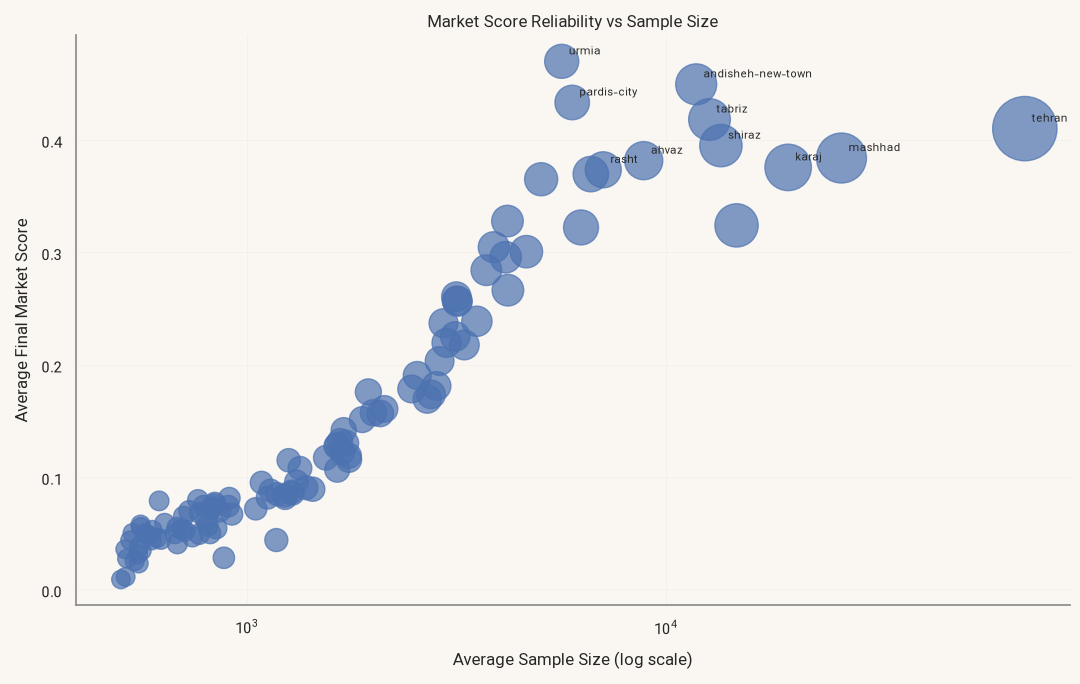

In [385]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = robust_market_ranking.reset_index().copy()

fig, ax = plt.subplots(figsize=(11,7))

scatter = ax.scatter(
    plot_df["avg_sample_size"],
    plot_df["avg_final_score"],
    s=np.sqrt(plot_df["avg_sample_size"]) * 8,
    alpha=0.7
)

ax.set_xscale("log")

ax.set_xlabel(
    "Average Sample Size (log scale)"
)

ax.set_ylabel(
    "Average Final Market Score"
)

ax.set_title(
    "Market Score Reliability vs Sample Size"
)

for _, row in plot_df.nlargest(10,"avg_final_score").iterrows():
    ax.annotate(
        row["city_slug"],
        (
            row["avg_sample_size"],
            row["avg_final_score"]
        ),
        fontsize=8,
        xytext=(5,5),
        textcoords="offset points"
    )

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [386]:
#24

In [387]:
PRICE_TARGET = "sale_price_per_sqm"

PRICE_FEATURES = [
    "has_elevator_clean_final",
    "has_parking_clean_final",
    "has_warehouse_clean_final",
    "rooms_count_clean_final",
    "total_floors_count_clean_final",
    "building_size_final",
    "land_size_final",
    "construction_year_clean_final",
    "building_direction_final",
    "user_type_final",
    "cat3_slug",
    "city_slug",
    "neighborhood_slug",
]

available_features = [
    c for c in PRICE_FEATURES
    if c in df.columns
]

logger.info(
    "Available price features: %s",
    available_features
)

analysis_ready_features = (
    df
    .query(
        "price_regime == 'sale'"
    )
    [
        available_features + [PRICE_TARGET]
    ]
    .copy()
)

analysis_ready_features = (
    analysis_ready_features
    .dropna(
        subset=[PRICE_TARGET]
    )
)

logger.info(
    "analysis_ready_features shape: %s",
    analysis_ready_features.shape
)

2026-08-14 19:06:41,625 | INFO | Available price features: ['has_elevator_clean_final', 'has_parking_clean_final', 'has_warehouse_clean_final', 'rooms_count_clean_final', 'total_floors_count_clean_final', 'building_size_final', 'land_size_final', 'construction_year_clean_final', 'building_direction_final', 'user_type_final', 'cat3_slug', 'city_slug', 'neighborhood_slug']
2026-08-14 19:06:43,519 | INFO | analysis_ready_features shape: (404671, 14)


In [388]:
baseline_mae = (
    np.abs(
        analysis_ready_features[PRICE_TARGET]
        -
        analysis_ready_features[PRICE_TARGET].median()
    )
    .mean()
)

baseline_mae

100759655.17195593

In [389]:
df["neighborhood_slug"].nunique()

1187

In [390]:
df["city_slug"].nunique()

421

In [391]:
neighborhood_counts = (
    analysis_ready_features["neighborhood_slug"]
    .value_counts()
)

neighborhood_counts.describe()

count    1175.000000
mean      143.924255
std       249.367364
min         1.000000
25%        22.000000
50%        59.000000
75%       159.000000
max      3350.000000
Name: count, dtype: float64

In [392]:
city_counts = (
    analysis_ready_features["city_slug"]
    .value_counts()
)

city_counts.describe()

count      419.000000
mean       965.801909
std       4158.678835
min          1.000000
25%         59.500000
50%        165.000000
75%        530.500000
max      72099.000000
Name: count, dtype: float64

In [393]:
analysis_ready_features["neighborhood_count"] = (
    analysis_ready_features["neighborhood_slug"]
    .map(
        analysis_ready_features["neighborhood_slug"]
        .value_counts()
    )
)

analysis_ready_features["city_count"] = (
    analysis_ready_features["city_slug"]
    .map(
        analysis_ready_features["city_slug"]
        .value_counts()
    )
)

analysis_ready_features[
    [
        "neighborhood_count",
        "city_count"
    ]
].describe()

,neighborhood_count,city_count
count,169111.000000,404671.000000
mean,575.617713,18830.059132
std,632.170696,25810.593816
min,1.000000,1.000000
25%,156.000000,1645.000000
50%,368.000000,5987.000000
75%,749.000000,19627.000000
max,3350.000000,72099.000000


In [394]:
VALID_RESIDENTIAL_TYPES = [
    "apartment-sell",
    "house-villa-sell",
    "villa",
    "suite-apartment",
]


logger.info("Filtering residential sale properties.")

analysis_ready_features = (
    df
    .query(
        "cat3_slug in @VALID_RESIDENTIAL_TYPES"
    )
    .copy()
)


logger.info(
    "After residential filtering: %s",
    analysis_ready_features.shape
)


logger.info(
    "Remaining property types:\n%s",
    analysis_ready_features["cat3_slug"]
    .value_counts()
)

2026-08-14 19:06:44,015 | INFO | Filtering residential sale properties.
2026-08-14 19:06:45,619 | INFO | After residential filtering: (325689, 292)
2026-08-14 19:06:45,644 | INFO | Remaining property types:
cat3_slug
apartment-sell      223365
house-villa-sell     83342
suite-apartment      10261
villa                 8721
Name: count, dtype: int64


In [395]:
logger.info("Building analysis ready features.")

VALID_RESIDENTIAL_TYPES = [
    "apartment-sell",
    "house-villa-sell",
    "office-sell",
    "shop-sell",
    "presell",
    "industry-agriculture-business-sell",
]


FEATURE_COLUMNS = [
    "sale_price_per_sqm",

    "has_elevator_clean_final",
    "has_parking_clean_final",
    "has_warehouse_clean_final",

    "rooms_count_clean_final",
    "total_floors_count_clean_final",

    "building_size_final",
    "land_size_final",
    "construction_year_clean_final",

    "building_direction_final",

    "cat3_slug",
    "user_type_final",

    "city_slug",
    "neighborhood_slug",

    "created_at_month"
]


analysis_ready_features = (
    df
    .query(
        "price_regime == 'sale'"
    )
    .query(
        "cat3_slug in @VALID_RESIDENTIAL_TYPES"
    )
    [FEATURE_COLUMNS]
    .copy()
)


analysis_ready_features = (
    analysis_ready_features
    .dropna(
        subset=[
            "sale_price_per_sqm"
        ]
    )
)


logger.info(
    "Initial analysis features shape: %s",
    analysis_ready_features.shape
)


logger.info(
    "Property types retained:\n%s",
    analysis_ready_features["cat3_slug"]
    .value_counts()
)

2026-08-14 19:06:45,654 | INFO | Building analysis ready features.
2026-08-14 19:06:48,638 | INFO | Initial analysis features shape: (327092, 15)
2026-08-14 19:06:48,680 | INFO | Property types retained:
cat3_slug
apartment-sell                        222718
house-villa-sell                       82515
shop-sell                              12869
industry-agriculture-business-sell      5828
office-sell                             3162
Name: count, dtype: int64


In [396]:
MIN_CITY_SAMPLE = 200
MIN_NEIGHBORHOOD_SAMPLE = 100


city_counts = (
    analysis_ready_features["city_slug"]
    .value_counts()
)


valid_cities = (
    city_counts[
        city_counts >= MIN_CITY_SAMPLE
    ]
    .index
)


neighborhood_counts = (
    analysis_ready_features["neighborhood_slug"]
    .value_counts()
)


valid_neighborhoods = (
    neighborhood_counts[
        neighborhood_counts >= MIN_NEIGHBORHOOD_SAMPLE
    ]
    .index
)


analysis_ready_features = (
    analysis_ready_features
    [
        analysis_ready_features["city_slug"]
        .isin(valid_cities)
        &
        analysis_ready_features["neighborhood_slug"]
        .isin(valid_neighborhoods)
    ]
)


logger.info(
    "After location filtering: %s",
    analysis_ready_features.shape
)


logger.info(
    "Cities retained: %d",
    analysis_ready_features["city_slug"].nunique()
)


logger.info(
    "Neighborhoods retained: %d",
    analysis_ready_features["neighborhood_slug"].nunique()
)

2026-08-14 19:06:48,893 | INFO | After location filtering: (125891, 15)
2026-08-14 19:06:48,907 | INFO | Cities retained: 8
2026-08-14 19:06:48,920 | INFO | Neighborhoods retained: 380


In [397]:
analysis_ready_features[
    "sale_price_per_sqm"
].describe()

count    1.258910e+05
mean     1.933735e+08
std      3.946053e+09
min      2.125000e-01
25%      2.980000e+07
50%      5.202312e+07
75%      9.305556e+07
max      3.500000e+11
Name: sale_price_per_sqm, dtype: float64

In [398]:
q1 = (
    analysis_ready_features["sale_price_per_sqm"]
    .quantile(0.01)
)

q99 = (
    analysis_ready_features["sale_price_per_sqm"]
    .quantile(0.99)
)


analysis_ready_features = (
    analysis_ready_features
    [
        analysis_ready_features["sale_price_per_sqm"]
        .between(q1,q99)
    ]
)


logger.info(
    "After target trimming: %s",
    analysis_ready_features.shape
)

2026-08-14 19:06:48,988 | INFO | After target trimming: (123400, 15)


In [399]:
analysis_ready_features[
    "created_at_month"
].min(), analysis_ready_features[
    "created_at_month"
].max()

('2024-07-01 00:00:00', '2024-12-01 00:00:00')

In [400]:
logger.info("Building temporal train test split.")

analysis_ready_features = (
    analysis_ready_features
    .sort_values("created_at_month")
)

split_index = int(
    len(analysis_ready_features) * 0.8
)


split_date = (
    analysis_ready_features
    .iloc[split_index]["created_at_month"]
)


train_df = (
    analysis_ready_features
    [
        analysis_ready_features["created_at_month"]
        <= split_date
    ]
    .copy()
)


test_df = (
    analysis_ready_features
    [
        analysis_ready_features["created_at_month"]
        >
        split_date
    ]
    .copy()
)


logger.info(
    "Split date: %s",
    split_date
)

logger.info(
    "Train shape: %s",
    train_df.shape
)

logger.info(
    "Test shape: %s",
    test_df.shape
)

2026-08-14 19:06:49,049 | INFO | Building temporal train test split.
2026-08-14 19:06:49,282 | INFO | Split date: 2024-11-01 00:00:00
2026-08-14 19:06:49,284 | INFO | Train shape: (101473, 15)
2026-08-14 19:06:49,284 | INFO | Test shape: (21927, 15)


In [401]:
TARGET = "sale_price_per_sqm"


X_train = train_df.drop(
    columns=[TARGET,"created_at_month"]
)

y_train = train_df[TARGET]


X_test = test_df.drop(
    columns=[TARGET,"created_at_month"]
)

y_test = test_df[TARGET]

In [402]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


categorical_cols = [
    "building_direction_final",
    "cat3_slug",
    "user_type_final",
    "city_slug",
    "neighborhood_slug"
]


numeric_cols = [
    c for c in X_train.columns
    if c not in categorical_cols
]

In [403]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_cols
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_cols
        )
    ]
)

In [404]:
baseline_features = [
    "building_size_final",
    "cat3_slug",
    "city_slug"
]


X_train_base = X_train[
    baseline_features
]

X_test_base = X_test[
    baseline_features
]

In [405]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = Pipeline(
    steps=[
        (
            "prep",
            ColumnTransformer(
                transformers=[
                    (
                        "num",
                        numeric_pipeline,
                        [
                            "building_size_final"
                        ]
                    ),
                    (
                        "cat",
                        categorical_pipeline,
                        [
                            "cat3_slug",
                            "city_slug"
                        ]
                    )
                ]
            )
        ),
        (
            "model",
            Ridge(alpha=10)
        )
    ]
)


baseline_model.fit(
    X_train_base,
    y_train
)


base_pred = baseline_model.predict(
    X_test_base
)


print(
    "Baseline MAE:",
    mean_absolute_error(
        y_test,
        base_pred
    )
)


print(
    "Baseline RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            base_pred
        )
    )
)


print(
    "Baseline R2:",
    r2_score(
        y_test,
        base_pred
    )
)

Baseline MAE: 31948338.655065496
Baseline RMSE: 49344603.89241104
Baseline R2: 0.31994960994361


In [406]:
full_model = Pipeline(
    steps=[
        (
            "prep",
            preprocessor
        ),
        (
            "model",
            Ridge(alpha=10)
        )
    ]
)


full_model.fit(
    X_train,
    y_train
)


full_pred = full_model.predict(
    X_test
)

In [407]:
print(
    "Full Model MAE:",
    mean_absolute_error(
        y_test,
        full_pred
    )
)


print(
    "Full Model RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            full_pred
        )
    )
)


print(
    "Full Model R2:",
    r2_score(
        y_test,
        full_pred
    )
)

Full Model MAE: 17413548.47146146
Full Model RMSE: 31587312.731994662
Full Model R2: 0.7213319874354291


In [408]:
error_analysis_df = test_df.copy()

error_analysis_df["y_true"] = y_test
error_analysis_df["y_pred"] = full_pred

error_analysis_df["absolute_error"] = (
    abs(
        error_analysis_df["y_true"]
        -
        error_analysis_df["y_pred"]
    )
)

error_analysis_df["percentage_error"] = (
    error_analysis_df["absolute_error"]
    /
    error_analysis_df["y_true"]
)

error_analysis_df[
    [
        "absolute_error",
        "percentage_error"
    ]
].describe()

,absolute_error,percentage_error
count,2.192700e+04,21927.000000
mean,1.741355e+07,0.528134
std,2.635447e+07,3.296469
min,9.419561e+02,0.000027
25%,4.105734e+06,0.077200
50%,9.080404e+06,0.170802
75%,1.886837e+07,0.335174
max,3.460854e+08,228.665183


In [409]:
city_error_summary = (
    error_analysis_df
    .groupby("city_slug")
    .agg(
        sample_size=("y_true","size"),
        MAE=("absolute_error","mean"),
        median_error=("absolute_error","median")
    )
    .sort_values(
        "MAE",
        ascending=False
    )
)

city_error_summary

,sample_size,MAE,median_error
city_slug,,,
tehran,10789,2.222379e+07,1.256400e+07
ahvaz,1128,1.506665e+07,6.978047e+06
isfahan,1090,1.491409e+07,7.540338e+06
shiraz,1298,1.389993e+07,8.064097e+06
rasht,692,1.334981e+07,6.713590e+06
karaj,2836,1.254296e+07,7.339735e+06
mashhad,3382,1.127092e+07,6.418188e+06
qom,712,1.100089e+07,6.233134e+06


In [410]:
property_error_summary = (
    error_analysis_df
    .groupby("cat3_slug")
    .agg(
        sample_size=("y_true","size"),
        MAE=("absolute_error","mean"),
        median_error=("absolute_error","median")
    )
    .sort_values(
        "MAE",
        ascending=False
    )
)

property_error_summary

,sample_size,MAE,median_error
cat3_slug,,,
shop-sell,428,7.547002e+07,6.866006e+07
office-sell,258,3.907537e+07,2.899982e+07
house-villa-sell,1989,2.816817e+07,1.405380e+07
industry-agriculture-business-sell,113,2.722842e+07,1.746065e+07
apartment-sell,19139,1.464763e+07,8.396651e+06


In [411]:
error_analysis_df["size_group"] = pd.cut(
    error_analysis_df["building_size_final"],
    bins=[
        0,
        50,
        100,
        200,
        500,
        np.inf
    ],
    labels=[
        "<50",
        "50-100",
        "100-200",
        "200-500",
        ">500"
    ]
)


size_error_summary = (
    error_analysis_df
    .groupby("size_group", observed=True)
    .agg(
        sample_size=("y_true","size"),
        MAE=("absolute_error","mean"),
        median_error=("absolute_error","median")
    )
)

size_error_summary

,sample_size,MAE,median_error
size_group,,,
<50,1781,2.287277e+07,9.475153e+06
50-100,10428,1.251800e+07,7.651849e+06
100-200,8276,1.786825e+07,9.909622e+06
200-500,1215,4.116436e+07,2.474403e+07
>500,225,5.586855e+07,3.248034e+07


In [412]:
error_analysis_df[
    [
        "city_slug",
        "neighborhood_slug",
        "cat3_slug",
        "y_true",
        "y_pred",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(20)

,city_slug,neighborhood_slug,cat3_slug,y_true,y_pred,absolute_error
150341,qom,15khordad,house-villa-sell,3.701299e+08,2.404449e+07,3.460854e+08
585104,mashhad,koohsangi,apartment-sell,3.850575e+08,4.295191e+07,3.421056e+08
206491,mashhad,elahiyehblvd,apartment-sell,3.750000e+08,3.646228e+07,3.385377e+08
440512,rasht,gilan-blvd,office-sell,4.000000e+08,6.216154e+07,3.378385e+08
722830,isfahan,kuy-shahid-keshvari,apartment-sell,3.773585e+08,4.115050e+07,3.362080e+08
622863,rasht,manzariyeh,house-villa-sell,3.500000e+08,1.408648e+07,3.359135e+08
569170,ahvaz,kianabad,apartment-sell,3.769231e+08,5.052844e+07,3.263946e+08
333649,karaj,golshahrvila,apartment-sell,3.320000e+08,2.668295e+07,3.053170e+08
524636,isfahan,baharestan-esfahan,apartment-sell,2.987500e+08,5.333614e+06,2.934164e+08
654826,tehran,elahiyeh,shop-sell,2.666667e+07,3.123925e+08,2.857259e+08


In [413]:
#26 : تحلیل متن اگهی

In [414]:
import re

TEXT_SIGNAL_PATTERNS: dict[str, re.Pattern] = {
    "text_signal_new_construction": re.compile(r"نوساز|نو\s*ساز|تازه\s*ساز|احداث\s*جدید"),
    "text_signal_never_lived_in": re.compile(r"کلید\s*نخورده|کلیدنخورده|بدون\s*سکونت"),
    "text_signal_urgent": re.compile(r"فروش\s*فوری|اجاره\s*فوری|فوری\s*فروش|فوری\s*است|فوریست|فوری\s*معاوضه"),
    "text_signal_swap": re.compile(r"معاوضه|تهاتر"),
    "text_signal_below_market": re.compile(
        r"زیر\s*قیمت|زیرقیمت|پایین‌?تر\s*از\s*قیمت\s*(?:بازار|روز)|ارزان‌?تر\s*از\s*بازار"
    ),
}


def extract_text_signals(
    frame: pd.DataFrame,
    patterns: dict[str, re.Pattern],
    title_col: str = "title",
    description_col: str = "description",
) -> pd.DataFrame:
    """Extract binary presence flags and per-mention counts for a set of
    keyword patterns from an ad's combined title+description text.

    Args:
        frame: The dataframe to scan. Must contain title_col and
            description_col.
        patterns: Mapping from signal name to a compiled regex pattern.
        title_col: Column holding the ad title.
        description_col: Column holding the ad description.

    Returns:
        A dataframe aligned with frame's index containing, for each
        signal name in patterns, a boolean "<signal_name>" column and an
        integer "<signal_name>_count" column (number of matches found).
    """
    combined_text = frame[title_col].fillna("") + " " + frame[description_col].fillna("")
    result = {}
    for signal_name, pattern in patterns.items():
        matches = combined_text.str.findall(pattern)
        result[signal_name] = matches.str.len() > 0
        result[f"{signal_name}_count"] = matches.str.len()
    return pd.DataFrame(result, index=frame.index)


text_signal_result = extract_text_signals(df, TEXT_SIGNAL_PATTERNS)
df = pd.concat([df, text_signal_result], axis=1)

In [415]:
signal_flag_cols = list(TEXT_SIGNAL_PATTERNS.keys())
frequency_summary = pd.DataFrame({
    "n_flagged": df[signal_flag_cols].sum(),
    "pct_flagged": 100 * df[signal_flag_cols].mean(),
})
logger.info("Text signal frequency summary:\n%s", frequency_summary.sort_values("n_flagged", ascending=False))

2026-08-14 19:07:10,294 | INFO | Text signal frequency summary:
                              n_flagged  pct_flagged
text_signal_swap                  74282    10.245934
text_signal_new_construction      50929     7.024787
text_signal_never_lived_in        29956     4.131919
text_signal_below_market          28439     3.922675
text_signal_urgent                17321     2.389136


In [416]:
RENT_CONVERSION_RATE_PER_MILLION: float = 30000
RENT_CONVERSION_RULE_VERSION: str = "v1.0"


def compute_equivalent_monthly_rent(
    frame: pd.DataFrame,
    conversion_rate_per_million: float,
    regime_col: str = "price_regime",
    monthly_rent_col: str = "monthly_rent",
    deposit_col: str = "deposit_amount",
) -> pd.Series:
    """Compute a single comparable monthly-rent-equivalent value across
    the rent_no_deposit, full_deposit, and deposit_and_rent regimes, by
    converting each listing's deposit portion into an equivalent monthly
    rent using a fixed market conversion rate.

    For deposit_and_rent listings, the actual monthly rent is kept as-is
    and only the deposit portion is converted and added -- these are two
    independent, real cash flows that both contribute to the effective
    monthly cost, not a double-count of the same amount.

    Args:
        frame: The dataframe to compute from. Must contain regime_col,
            monthly_rent_col, and deposit_col.
        conversion_rate_per_million: Monthly rent (in the same currency
            unit as monthly_rent_col) equivalent to 1,000,000 units of
            deposit. This is a market assumption, not a fixed fact --
            see decision log and sensitivity analysis.
        regime_col: Column holding the price regime label.
        monthly_rent_col: Column holding the actual monthly rent amount.
        deposit_col: Column holding the deposit amount.

    Returns:
        A series aligned with frame's index containing the equivalent
        monthly rent for rows in rent_no_deposit/full_deposit/
        deposit_and_rent regimes, NaN elsewhere.
    """
    equivalent_rent = pd.Series(np.nan, index=frame.index, dtype="float64")

    is_rent_no_deposit = frame[regime_col] == "rent_no_deposit"
    equivalent_rent = equivalent_rent.mask(is_rent_no_deposit, frame[monthly_rent_col])

    is_full_deposit = frame[regime_col] == "full_deposit"
    deposit_converted = (frame[deposit_col] / 1_000_000) * conversion_rate_per_million
    equivalent_rent = equivalent_rent.mask(is_full_deposit, deposit_converted)

    is_deposit_and_rent = frame[regime_col] == "deposit_and_rent"
    combined = frame[monthly_rent_col] + (frame[deposit_col] / 1_000_000) * conversion_rate_per_million
    equivalent_rent = equivalent_rent.mask(is_deposit_and_rent, combined)

    return equivalent_rent


df["monthly_rent_equivalent"] = compute_equivalent_monthly_rent(df, RENT_CONVERSION_RATE_PER_MILLION)
df["rent_conversion_rule_version"] = RENT_CONVERSION_RULE_VERSION

logger.info(
    "monthly_rent_equivalent coverage: %d / %d rows across rent-family regimes",
    df["monthly_rent_equivalent"].notna().sum(),
    df["price_regime"].isin(["rent_no_deposit", "full_deposit", "deposit_and_rent"]).sum(),
)

2026-08-14 19:07:10,560 | INFO | monthly_rent_equivalent coverage: 263503 / 263503 rows across rent-family regimes


In [417]:
has_building_size = df["building_size_final"].notna() & (df["building_size_final"] > 0)
has_equivalent_rent = df["monthly_rent_equivalent"].notna()

df["monthly_rent_equivalent_per_sqm"] = np.nan
df.loc[has_equivalent_rent & has_building_size, "monthly_rent_equivalent_per_sqm"] = (
    df.loc[has_equivalent_rent & has_building_size, "monthly_rent_equivalent"]
    / df.loc[has_equivalent_rent & has_building_size, "building_size_final"]
)

In [418]:
REGIME_PRICE_METRIC_MAP: dict[str, str] = {
    "sale": "sale_price_per_sqm",
    "rent_no_deposit": "monthly_rent_equivalent_per_sqm",
    "full_deposit": "monthly_rent_equivalent_per_sqm",
    "deposit_and_rent": "monthly_rent_equivalent_per_sqm",
}


def compare_raw_price_by_signal_per_regime(
    frame: pd.DataFrame,
    signal_col: str,
    regime_price_map: dict[str, str] = REGIME_PRICE_METRIC_MAP,
    regime_col: str = "price_regime",
) -> pd.DataFrame:
    """Compare a per-sqm price metric between listings with/without a text
    signal, computed separately within each price regime (since sale,
    rent, and deposit prices must never be mixed into one comparison).

    Args:
        frame: The dataframe to compute from.
        signal_col: Boolean column indicating presence of the text signal.
        regime_price_map: Mapping from price_regime value to the
            appropriate per-sqm price column for that regime.
        regime_col: Column holding the price regime label.

    Returns:
        A dataframe with one row per (regime, signal_present) combo,
        containing median/mean/count of the regime-appropriate price
        metric, plus percentage difference in median relative to the
        signal-absent baseline within that regime.
    """
    rows = []
    for regime, price_col in regime_price_map.items():
        subset = frame.loc[frame[regime_col] == regime].dropna(subset=[price_col])
        if subset.empty:
            continue
        grouped = subset.groupby(signal_col)[price_col].agg(["median", "mean", "count"])
        if False in grouped.index and True in grouped.index:
            grouped["pct_diff_vs_baseline"] = 100 * (grouped["median"] / grouped.loc[False, "median"] - 1)
        grouped["price_regime"] = regime
        grouped["price_metric_used"] = price_col
        rows.append(grouped.reset_index())
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


for signal_col in signal_flag_cols:
    logger.info(
        "Raw price comparison (per regime) for %s:\n%s",
        signal_col, compare_raw_price_by_signal_per_regime(df, signal_col),
    )

2026-08-14 19:07:15,321 | INFO | Raw price comparison (per regime) for text_signal_new_construction:
   text_signal_new_construction        median          mean   count  \
0                         False  2.631579e+07  1.076018e+08  374575   
1                          True  3.655543e+07  1.761732e+08   30096   
2                         False  5.000000e+04  2.906170e+09    4970   
3                          True  5.250000e+04  4.196380e+05     110   
4                         False  1.800000e+05  6.941445e+06   40527   
5                          True  2.331606e+05  6.716116e+05    4831   
6                         False  1.636364e+05  2.754374e+08  199534   
7                          True  1.918182e+05  2.560289e+08   13276   

   pct_diff_vs_baseline      price_regime                price_metric_used  
0              0.000000              sale               sale_price_per_sqm  
1             38.910641              sale               sale_price_per_sqm  
2              0.000000   re

In [419]:
from scipy import stats

REGIME_GROUPS: dict[str, dict[str, list[str] | str]] = {
    "sale": {
        "regimes": ["sale"],
        "price_col": "sale_price_per_sqm",
    },
    "rent_family": {
        "regimes": ["rent_no_deposit", "full_deposit", "deposit_and_rent"],
        "price_col": "monthly_rent_equivalent_per_sqm",
    },
}

BASE_CONTROL_GROUP_COLUMNS = ["city_slug", "cat3_slug", "rooms_count_clean"]


def compute_group_normalized_price_ratio(
    frame: pd.DataFrame,
    price_col: str,
    group_cols: list[str],
    min_group_size: int = 20,
) -> pd.Series:
    """Normalize each listing's price by the median price of its own
    comparison group, so that comparing this ratio across groups controls
    for those confounders.

    Args:
        frame: The dataframe to compute from.
        price_col: Numeric price column to normalize.
        group_cols: Columns defining the comparison group for each row.
        min_group_size: Minimum group size required to trust its median;
            rows in smaller groups get NaN (excluded from comparison).

    Returns:
        A series aligned with frame's index: price_col divided by its
        group's median, or NaN where the group is too small or the
        price is missing.
    """
    group_sizes = frame.groupby(group_cols, observed=True)[price_col].transform("count")
    group_median = frame.groupby(group_cols, observed=True)[price_col].transform("median")
    ratio = frame[price_col] / group_median
    return ratio.where(group_sizes >= min_group_size)


def controlled_comparison_for_signal(
    frame: pd.DataFrame,
    signal_col: str,
    regime_group_name: str,
    regime_group_config: dict,
    regime_col: str = "price_regime",
    base_group_cols: list[str] = BASE_CONTROL_GROUP_COLUMNS,
) -> dict:
    """Compare group-normalized price between listings with and without a
    text signal, within one regime family (sale, or the rent/deposit
    family sharing a common equivalent-rent metric), using a Mann-Whitney
    U test (non-parametric, robust to the skewed price distribution).

    When the regime family spans more than one price_regime value (the
    rent family), price_regime is added to the comparison group columns
    so that, e.g., full_deposit and deposit_and_rent listings are only
    compared to others in the same regime -- not blended together
    despite sharing one converted price metric.

    Args:
        frame: The dataframe to compute from.
        signal_col: Boolean column indicating presence of the text signal.
        regime_group_name: Label for the regime family being tested
            (e.g. "sale", "rent_family"), used only for reporting.
        regime_group_config: Dict with "regimes" (list of price_regime
            values included) and "price_col" (the metric to compare).
        regime_col: Column holding the price regime label.
        base_group_cols: Confounder columns always used for grouping.

    Returns:
        A dict with regime_group_name, sample sizes, median normalized
        ratio for each side, percentage difference, Mann-Whitney U
        statistic, p-value, and a verdict string.
    """
    regimes = regime_group_config["regimes"]
    price_col = regime_group_config["price_col"]

    subset = frame.loc[frame[regime_col].isin(regimes)].copy()
    group_cols = base_group_cols + ([regime_col] if len(regimes) > 1 else [])

    subset["price_ratio"] = compute_group_normalized_price_ratio(subset, price_col, group_cols)
    subset = subset.dropna(subset=["price_ratio"])

    with_signal = subset.loc[subset[signal_col], "price_ratio"]
    without_signal = subset.loc[~subset[signal_col], "price_ratio"]

    if len(with_signal) < 30 or len(without_signal) < 30:
        return {
            "signal": signal_col,
            "regime_group": regime_group_name,
            "price_col_used": price_col,
            "n_with_signal": len(with_signal),
            "n_without_signal": len(without_signal),
            "verdict": "insufficient_data",
        }

    u_stat, p_value = stats.mannwhitneyu(with_signal, without_signal, alternative="two-sided")

    return {
        "signal": signal_col,
        "regime_group": regime_group_name,
        "price_col_used": price_col,
        "n_with_signal": len(with_signal),
        "n_without_signal": len(without_signal),
        "median_ratio_with_signal": with_signal.median(),
        "median_ratio_without_signal": without_signal.median(),
        "pct_diff": 100 * (with_signal.median() / without_signal.median() - 1),
        "mannwhitney_u": u_stat,
        "p_value": p_value,
        "verdict": "significant" if p_value < 0.05 else "not_significant",
    }


controlled_comparison_results = pd.DataFrame([
    controlled_comparison_for_signal(df, signal_col, regime_group_name, regime_group_config)
    for signal_col in signal_flag_cols
    for regime_group_name, regime_group_config in REGIME_GROUPS.items()
])
logger.info("Controlled price comparison by text signal and regime group:\n%s", controlled_comparison_results)


2026-08-14 19:08:11,284 | INFO | Controlled price comparison by text signal and regime group:
                         signal regime_group                   price_col_used  \
0  text_signal_new_construction         sale               sale_price_per_sqm   
1  text_signal_new_construction  rent_family  monthly_rent_equivalent_per_sqm   
2    text_signal_never_lived_in         sale               sale_price_per_sqm   
3    text_signal_never_lived_in  rent_family  monthly_rent_equivalent_per_sqm   
4            text_signal_urgent         sale               sale_price_per_sqm   
5            text_signal_urgent  rent_family  monthly_rent_equivalent_per_sqm   
6              text_signal_swap         sale               sale_price_per_sqm   
7              text_signal_swap  rent_family  monthly_rent_equivalent_per_sqm   
8      text_signal_below_market         sale               sale_price_per_sqm   
9      text_signal_below_market  rent_family  monthly_rent_equivalent_per_sqm   

   n_with_sign

In [420]:
def review_extraction_samples(
    frame: pd.DataFrame,
    signal_col: str,
    n_samples: int = 20,
    random_state: int = 42,
    extra_columns: list[str] | None = None,
) -> pd.DataFrame:
    """Draw a random sample of rows flagged by a text signal, for manual
    precision review.

    Args:
        frame: The dataframe to sample from.
        signal_col: Boolean column indicating presence of the text signal.
        n_samples: Number of rows to sample.
        random_state: Seed for reproducible sampling.
        extra_columns: Additional columns to include alongside title and
            description (e.g. price and regime fields), so the reviewer
            can judge both textual precision and whether the price
            actually looks consistent with the claimed signal.

    Returns:
        A dataframe with title, description, and extra_columns for the
        sampled rows.
    """
    review_columns = ["title", "description"] + (extra_columns or [])
    flagged = frame.loc[frame[signal_col], review_columns]
    return flagged.sample(min(n_samples, len(flagged)), random_state=random_state)


REVIEW_EXTRA_COLUMNS = [
    "price_regime",
    "sale_price", "sale_price_per_sqm",
    "monthly_rent_equivalent", "monthly_rent_equivalent_per_sqm","monthly_rent","deposit_amount",
]

for signal_col in signal_flag_cols:
    logger.info("Manual review sample for %s:", signal_col)
    display(review_extraction_samples(df, signal_col, extra_columns=REVIEW_EXTRA_COLUMNS))

2026-08-14 19:08:11,307 | INFO | Manual review sample for text_signal_new_construction:


,title,description,price_regime,sale_price,sale_price_per_sqm,monthly_rent_equivalent,monthly_rent_equivalent_per_sqm,monthly_rent,deposit_amount
418583,واحد125متری فول خاقانی دوخواب,125متر زیربنا٫نوساز.دوخواب٫خواب ها دارای پنجره...,deposit_and_rent,NaN,NaN,18100000.0,144800.000000,100000.0,6.000000e+08
369571,112متر اشتراکی جنوبی درحد نوساز/غرق نور,⚜️RAHA TAGHIPOUR⚜️ مختص سخت پسندان ✔️قابل تبدی...,deposit_and_rent,NaN,NaN,20500000.0,183035.714286,4000000.0,5.500000e+08
181763,130متر*نوساز*تکواحدی*سالن پرده خور*تاپ لوکیشن,فرصت استثنائی خرید آپارتمان در تاپ ترین اوکیشی...,sale,1.499000e+10,1.153077e+08,NaN,NaN,NaN,NaN
526518,ویلایی دربست ، 350 متر ، ابوذرغفاری,***************⚜️لوکیشن ابوذرغفاری⚜️**********...,deposit_and_rent,NaN,NaN,79000000.0,207894.736842,49000000.0,1.000000e+09
608877,فروش واحد بر زاگرس,درود فراوان فروش واحد نوساز صفر کلید نخورده بر...,sale,4.450000e+09,3.296296e+07,NaN,NaN,NaN,NaN
295508,اپارتمان 141متر نوساز کلیدنخورده/شخصی ساز/3خواب,⚜️141متر نوساز کلید نخورده ⚜️3 خواب مستر ⚜️هر ...,full_deposit,NaN,NaN,52500000.0,372340.425532,NaN,1.750000e+09
96042,اجاره زیر زمین یک خواب خیابان عابدی,خونه نوساز دارای پرده نو ، کابینت mdf تازه انج...,deposit_and_rent,NaN,NaN,11500000.0,88461.538462,10000000.0,5.000000e+07
465880,آپارتمان 70متری نوساز سنددار قرچک,آپارتمان 70م نوساز تمیز 2اتاق خواب طبقه دوم خی...,sale,1.850000e+09,2.642857e+07,NaN,NaN,NaN,NaN
165622,آپارتمان 147متری نوساز ودیعه و اجاره قابل تبدیل,آپارتمان 147متری داری دو بالکن و سه اتاق نو سا...,deposit_and_rent,NaN,NaN,16000000.0,108843.537415,5500000.0,3.500000e+08
236197,135 متر سه خواب نوساز کلید نخورده,⚜️135 متر سه خواب ⚜️فول امکانات ⚜️لابی ⚜️سراید...,full_deposit,NaN,NaN,36000000.0,266666.666667,NaN,1.200000e+09


2026-08-14 19:08:11,470 | INFO | Manual review sample for text_signal_never_lived_in:


,title,description,price_regime,sale_price,sale_price_per_sqm,monthly_rent_equivalent,monthly_rent_equivalent_per_sqm,monthly_rent,deposit_amount
290422,اپارتمان 140متری تاپ لوکیشن استخر دار,⭐فول امکانات موقعیت عالی نوساز کلید نخورده ⭐پا...,sale,6.440000e+09,4.600000e+07,NaN,NaN,NaN,NaN
43510,آپارتمان 105متری در شهرک عارف,آپارتمان نوساز کلید نخورده می باشد فول کامل,full_deposit,NaN,NaN,15000000.0,142857.142857,NaN,5.000000e+08
12774,آپارتمان 163 متر کوی دانشگاه,⚜ املاک یوردوم ⚜ کد ملک: 918 موقعیت ساختمان جن...,sale,6.190000e+09,3.797546e+07,NaN,NaN,NaN,NaN
94035,آپارتمان 145متر مارالان/فدک (یوردوم),⚜ املاک یوردوم ⚜ کد ملک: 317 موقعیت ساختمان جن...,sale,5.800000e+09,4.000000e+07,NaN,NaN,NaN,NaN
691940,160متر 3خواب مسترشخصی ساز فاز1 کد 112/حمید ورم...,به نام خالق زیبایی ها و مالک کل جهان هستی با س...,sale,1.120000e+10,7.000000e+07,NaN,NaN,NaN,NaN
78007,اجاره تخصصی سالانه باغ ویلا کردان,اجاره تخصصی سالیانه باغ ویلا برای خانواده و عز...,deposit_and_rent,NaN,NaN,42000000.0,200000.000000,30000000.0,4.000000e+08
181796,فروش،تک واحدی،کلیدنخورده،,فروش آپارتمان تک واحدی کلیدنخورده نمارومی بینظ...,sale,4.400000e+09,3.520000e+07,NaN,NaN,NaN,NaN
710506,رهن واجاره واحدکلیدنخورده,با سلام رهن واجاره واحد مسکونی جنب درمانگاه تا...,deposit_and_rent,NaN,NaN,10600000.0,96363.636364,100000.0,3.500000e+08
479909,آپارتمان 115متری کلید نخورده فول,با سلام جهت اطلاع بیشتر تماس حاصل فرمایید,sale,3.850000e+09,3.347826e+07,NaN,NaN,NaN,NaN
71902,بر سالاریه سه خاب جنوبی غرق نور,♡به نام یگانه معمار هستی♡ ✓نسترن نبش کوچه دو ب...,sale,1.180000e+10,6.555556e+07,NaN,NaN,NaN,NaN


2026-08-14 19:08:11,585 | INFO | Manual review sample for text_signal_urgent:


,title,description,price_regime,sale_price,sale_price_per_sqm,monthly_rent_equivalent,monthly_rent_equivalent_per_sqm,monthly_rent,deposit_amount
276952,یک باب مغازه 100متری درکوی نصربرخیابان,—« مـشاوریـن امـلاک تـخصصــی ایـران زمـین »— ⭕...,deposit_and_rent,NaN,NaN,52000000.0,520000.0,40000000.0,400000000.0
680780,ویلایی چهار طبقه در کیان آباد شرقی,. ✴️✴️✴️ حرفه ای ها ماندگارند ✴️✴️✴️ Mandegar ...,sale,1.850000e+10,9.250000e+07,NaN,NaN,NaN,NaN
317588,آپارتمان/120متر/بنادر,فروش فوری امتیاز بنادر فاز 2 داریم: واریزی :25...,sale,5.000000e+08,4.166667e+06,NaN,NaN,NaN,NaN
331196,آپارتمان تک واحدی 130 متر,بنام خدا ● فروش فوری ● آپارتمان 130 متری ولیعص...,sale,3.600000e+09,2.769231e+07,NaN,NaN,NaN,NaN
339756,آپارتمان 35متری /یک خواب /رودکی,❤️بنام نامی الله❤️ ✅آپارتمان 35متری یک خواب ✅ن...,sale,2.200000e+09,6.285714e+07,NaN,NaN,NaN,NaN
669225,200متر*تک واحدی*الهیه*فول فرنیش*غرق نور,مشاور و همراه شما امیر نیکی ⚡مسکن سراسری مجلل⚡...,sale,6.000000e+09,3.000000e+07,NaN,NaN,NaN,NaN
132453,زمین غرق آباد روستای مر موقعیت,زمین واقع در روستای مر ویو ابدی چشم نواز و زیب...,sale,3.750000e+08,1.500000e+06,NaN,NaN,NaN,NaN
642439,110 متری ) سند آماده ) شیک کم واحد ) رو به پارک,⚜️به نام خدا⚜️ _______________________________...,sale,3.500000e+09,3.181818e+07,NaN,NaN,NaN,NaN
562077,آپارتمان 100 متری دو خواب در حافظ,⚜️⚜️⚜️الهی به امید تو⚜️⚜️⚜️ ⚜️سایت املاک خانه ...,sale,3.300000e+09,3.300000e+07,NaN,NaN,NaN,NaN
85817,فروش آپارتمان 95 متری سند دار,واحد پیش فروش در منطقه مکانی عالی و نزدیک به خ...,service_listing,NaN,NaN,NaN,NaN,NaN,NaN


2026-08-14 19:08:11,687 | INFO | Manual review sample for text_signal_swap:


,title,description,price_regime,sale_price,sale_price_per_sqm,monthly_rent_equivalent,monthly_rent_equivalent_per_sqm,monthly_rent,deposit_amount
170210,زمین کشاورزی نزدیک به ساخت 250 متر,✅زمین کشاورزی نزدیک به ساخت ،آینده دار ❎فعلا ر...,sale,1.125000e+09,4.500000e+06,NaN,NaN,NaN,NaN
29964,آپارتمان 90متری دو خواب,با سلام...ی واحد آپارتمان.واقع در طبرسی شمالی ...,sale,2.000000e+09,2.222222e+07,NaN,NaN,NaN,NaN
412398,فروش 480متر کلنگی دیباجی منظریه قابل سکونت,دیباجی جنوبی و منظریه 480متر کلنگی ملک شمالی ب...,sale_negotiable,NaN,NaN,NaN,NaN,NaN,NaN
506853,280 متر فاز6 تهاتر با واحد و ماشین,✨️به نام تنها معمار هستی✨️ ___________________...,sale_no_value,NaN,NaN,NaN,NaN,NaN,NaN
612590,2950 متر باغ گنجنامه قابل معاوضه با واحد,قیمت توافقی 110 متر ساختمان 50 متر انباری 50 م...,sale,2.500000e+10,8.474576e+06,NaN,NaN,NaN,NaN
467978,خانه ویلایی کلنگی شهیدان محله آفاران,مناسب ساخت و ساز.(فعلاً قابل سکونت ) ((معاوضه ...,sale,5.000000e+09,2.000000e+07,NaN,NaN,NaN,NaN
364987,430 متری / شهرک یاس های وحشی / کارشناسی,☑️مالک پول لازم کد a63 430 زمین 270 بنا چشم ان...,sale,2.300000e+09,5.348837e+06,NaN,NaN,NaN,NaN
572372,ویووجکوزی روف روببین ویلاباغ مدرن لاویج روبخر,♦️کدلاویج 10 ♦️دوبلکش روف و جکوزی رو به جنگل م...,sale,3.500000e+09,1.166667e+07,NaN,NaN,NaN,NaN
133801,520متر زمین شهرکی با جواز,520متر زمین با بر17 جواز ساخت ویلا باغ دیوار ک...,sale,1.000000e+10,1.923077e+07,NaN,NaN,NaN,NaN
187123,100متر اپارتمان فول امکانات شهرک حجت,درب برقی ،پارکینگ ،اسانسور 8نفره درب ضد سرقت پ...,sale,1.550000e+09,1.631579e+07,NaN,NaN,NaN,NaN


2026-08-14 19:08:11,839 | INFO | Manual review sample for text_signal_below_market:


,title,description,price_regime,sale_price,sale_price_per_sqm,monthly_rent_equivalent,monthly_rent_equivalent_per_sqm,monthly_rent,deposit_amount
461475,95 متر/ 2 خواب/ کلید نخورده/ سالن پرده خور/سازمان,**لوکس و کم نظیر زیر قیمت منطقه ** (عکسها متعل...,sale,1.239000e+10,1.304211e+08,NaN,NaN,NaN,NaN
311763,آپارتمان 165 متری . وام آماده. فول آپشن. باهنر,⚜️بسم تعالی⚜️ ✍️تمام مراحل اخذ وام مسکن شما ( ...,sale,4.700000e+09,2.848485e+07,NaN,NaN,NaN,NaN
614235,80 متر /2 سر نورگیر/ فول بازسازی/ فردوس,واحد کارشناسی شده // زیر قیمت کلا 8 واحد طبقه ...,sale,5.890000e+09,7.362500e+07,NaN,NaN,NaN,NaN
689559,40 متر/ روبه آفتاب /فول بازسازی,⭐بسم الله الرحمن الرحیم⭐ ✔️سلام ✅ارزان ترین فا...,sale,2.790000e+09,6.975000e+07,NaN,NaN,NaN,NaN
717917,اپارتمان 130متری دوخواب,درود فراوان ✅واحد فوق در لوکیشن فارابی نزدیک ب...,sale,4.700000e+09,3.615385e+07,NaN,NaN,NaN,NaN
386876,ویلایی بر بلوار مدرس با 100متر تجاری فعال,ویلایی تجاری مسکونی 350متر مربع مساحت زمین 100...,sale,2.600000e+10,7.428571e+07,NaN,NaN,NaN,NaN
249378,واحد 70 متری / بدون مشرف,⚪️املاک خانه سفید⚪️ ☆واحد خوش نقشه در نزدیکی د...,sale,5.100000e+09,7.285714e+07,NaN,NaN,NaN,NaN
719000,مغازه تجاری بلوار پاسداران جدید,مغازه تجاری بلوار پاسداران جدید سرنبش پاسداران...,sale,1.850000e+09,4.111111e+07,NaN,NaN,NaN,NaN
668332,94 متر فول امکانات 6ساله,94 متر فول امکانات 6ساله لابی و لابی من 24 ساع...,sale,9.000000e+09,9.574468e+07,NaN,NaN,NaN,NaN
324887,زمین مسکونی خشکبیجار290متر ویو رودخانه/آناملک,همراه با مجموعه آنا ملک صاحب ملک دلخواه خود شو...,sale,1.450000e+09,5.000000e+06,NaN,NaN,NaN,NaN


In [421]:
def summarize_text_signal_conclusion(row: pd.Series, significance_threshold: float = 0.05) -> str:
    """Translate a controlled_comparison_for_signal result row into one of
    the three required conclusion categories for the project report.
    """
    if row["verdict"] == "insufficient_data":
        return "insufficient_data"
    if row["p_value"] < significance_threshold:
        direction = "lower" if row["pct_diff"] < 0 else "higher"
        return f"associated_with_{direction}_price"
    return "no_significant_relationship_after_control"


controlled_comparison_results["conclusion"] = controlled_comparison_results.apply(
    summarize_text_signal_conclusion, axis=1
)
logger.info(
    "Final conclusions by signal and regime group:\n%s",
    controlled_comparison_results[["signal", "regime_group", "conclusion", "pct_diff", "p_value"]],
)

2026-08-14 19:08:12,028 | INFO | Final conclusions by signal and regime group:
                         signal regime_group                    conclusion  \
0  text_signal_new_construction         sale  associated_with_higher_price   
1  text_signal_new_construction  rent_family  associated_with_higher_price   
2    text_signal_never_lived_in         sale  associated_with_higher_price   
3    text_signal_never_lived_in  rent_family  associated_with_higher_price   
4            text_signal_urgent         sale   associated_with_lower_price   
5            text_signal_urgent  rent_family   associated_with_lower_price   
6              text_signal_swap         sale   associated_with_lower_price   
7              text_signal_swap  rent_family  associated_with_higher_price   
8      text_signal_below_market         sale   associated_with_lower_price   
9      text_signal_below_market  rent_family   associated_with_lower_price   

    pct_diff        p_value  
0   8.219328  2.864062e-196  
1 